# **CASO 1 ELECTRONICS**



**Integrantes del grupo: GATOBYTE**


*   Ivonne Micaela Colque Murillo
*   Adriana Nathalie Rocha Vedia

*   Tania Morelia Pérez Dick
*   Ignacio Retamozo Torrez
*   Dilan Obed Mamani Pamuri

# **ENTENDIMIENTO DEL NEGOCIO**

Contexto del Caso
En el ecosistema del comercio electrónico global, el análisis del sentimiento y el comportamiento del consumidor es una de las tareas más críticas, ya que permite a las empresas comprender la relación entre las características de un producto y la satisfacción real del usuario. En la categoría de Electronics, el volumen y la velocidad de la información son masivos: este dataset forma parte del repositorio Amazon Reviews 2023, que comprende 18.3 millones de reseñas y 1.6 millones de productos, integrando un total de 43.9 millones de interacciones de usuarios.

La gestión de esta "Big Data" es vital, pues una mala interpretación de las tendencias o una incapacidad para jerarquizar la información útil puede generar pérdidas de oportunidad, recomendaciones irrelevantes y una disminución en la fidelidad del cliente. Por ello, se hace indispensable el uso de técnicas de Aprendizaje Automático (Machine Learning) para extraer valor de la combinación entre metadatos de producto (meta) y experiencias de usuario (review).

El presente caso de estudio se enfoca en una muestra representativa de este universo, analizando variables clave que caracterizan la experiencia de compra:

price: El valor monetario del artículo.

average_rating y rating_number: El prestigio histórico y el volumen de validación social del producto.

verified_purchase: El indicador de autenticidad de la experiencia.

text_len y sentiment: La extensión del feedback y la carga emocional del consumidor.

main_category: El contexto específico del segmento tecnológico analizado.

Estas variables permiten modelar patrones complejos para anticipar tanto la valoración numérica del producto como la utilidad que la comunidad percibirá en dicha reseña.

Objetivo del Caso
A partir de este robusto conjunto de datos, se plantean dos problemas analíticos complementarios que permiten abordar la experiencia del cliente desde una perspectiva multidimensional:

1. Predicción del Nivel de Satisfacción (Problema de Regresión)
El primer desafío consiste en estimar el rating que un usuario asignará a un producto electrónico. Al tratarse de una escala numérica continua (o interpretada como tal), planteamos un problema de Regresión. El objetivo es predecir la calificación final basándonos en la combinación del precio, la categoría y la percepción histórica del artículo. Lograr una predicción precisa del rating permite a las plataformas predecir el éxito de nuevos lanzamientos y personalizar las ofertas según la expectativa de agrado del usuario.

2. Determinación de la Utilidad del Contenido (Problema de Clasificación)
El segundo problema busca anticipar la relevancia de una reseña mediante la variable helpful_vote. Para fines de este estudio, se ha transformado en un problema de Clasificación Binaria, donde el modelo debe determinar si una reseña será considerada "útil" por la comunidad o si, por el contrario, será ignorada. Detectar proactivamente el contenido de valor permite:

Jerarquizar las mejores reseñas en la interfaz de usuario.

Mitigar el ruido informativo generado por comentarios irrelevantes.

Mejorar la confianza del consumidor en el proceso de decisión de compra.

Objetivo General: Evaluar y optimizar distintos modelos de Machine Learning que permitan identificar patrones de consumo y percepción de calidad en el sector electrónico, transformando millones de registros en una herramienta estratégica para la mejora de los sistemas de recomendación y la calidad del inventario.

**Link de dataset:** https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset


# **1. Cargado de Librerias y Dataset**

In [4]:
import sys

assert sys.version_info >= (3, 7)

In [5]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [6]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb
sb.set_style("darkgrid")
sb.set(style="white")
sb.set(style="whitegrid", color_codes=True)

import numpy as np

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn import preprocessing
from scipy import stats
from pandas import Series, DataFrame
from pandas.plotting import autocorrelation_plot
#from pandas.tools.plotting import scatter_matrix
from pylab import rcParams
from matplotlib import collections as collections
from matplotlib.patches import Rectangle
from itertools import cycle

import warnings
warnings.filterwarnings('ignore')

rcParams['figure.figsize'] = 5,4
#sb.set_style('whitegrid')
from numpy import median
from numpy import mean

#Semilla
np.random.seed(42)

**NOTA:** Se procede a hacer la preparación del entorno, la importación de las libreriías y asignar una semilla, ello con el fin de hacer que el modelo sea reprocucible.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#reading dataset
#df=pd.read_csv('/kaggle/input/churn-modellingcsv/Churn_Modelling.csv')
df = pd.read_parquet('drive/My Drive/Machine Learning/proyecto/sample_ml.parquet')
df_original_state = df.copy() # Store the original state

**NOTA: **Se procede a verificar si es que el dataset fue cargado de manera correcta. Como se puede evidenciar el dataset fue cargado de manera correcta mostrandose así que este cuenta con 30000 filas y 25 features o columnas.

# **2. EDA - Entendimiento de los Datos**

## **2.1. Conteo de variables objetivo**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   rating             1000000 non-null  float64       
 1   title              1000000 non-null  object        
 2   text               1000000 non-null  object        
 3   parent_asin        1000000 non-null  object        
 4   timestamp          1000000 non-null  int64         
 5   helpful_vote       1000000 non-null  int64         
 6   verified_purchase  1000000 non-null  bool          
 7   text_len           1000000 non-null  uint32        
 8   sentiment          1000000 non-null  object        
 9   is_satisfied       1000000 non-null  bool          
 10  review_date        1000000 non-null  datetime64[us]
 11  main_category      983166 non-null   object        
 12  average_rating     1000000 non-null  float64       
 13  rating_number      1000000 n

### **Variables Regresión y Clasificacion**

Se procede con el análisis descriptivo inicial de los atributos que integrarán los algoritmos de aprendizaje supervisado. En el contexto de este dataset, esta fase es crucial para comprender cómo las métricas de utilidad y las valoraciones de los usuarios pueden ser transformadas en variables de entrada robustas, optimizando así el rendimiento de los modelos de regresión y clasificación propuestos

In [ ]:
df['helpful_vote'].value_counts()

,count
helpful_vote,
0,762392
1,127486
2,41123
3,19507
4,11372
...,...
326,1
400,1
274,1


**NOTA:** Se procede a realizar el análisis de frecuencia de la variable helpful_vote, la cual presenta una amplia dispersión con valores que alcanzan hasta los 1281 votos, confirmando su carácter numérico y su potencial como métrica de relevancia. No obstante, destaca una presencia masiva de registros con valor 0, sumando 72,968 ocurrencias, lo que evidencia que la gran mayoría de las interacciones no reciben votos de utilidad. Esta acumulación crítica en el extremo inferior indica una distribución con un sesgo extremadamente marcado hacia la derecha, similar a lo observado en el comportamiento de pagos previos. Finalmente, aún no se ha determinado el tratamiento definitivo para esta variable, ya que su uso dependerá del análisis exploratorio posterior y de la libertad de elección en la estrategia de modelado.

### **Clasificación**

In [ ]:
df['rating'].value_counts()

,count
rating,
5.0,586067
1.0,148100
4.0,128317
3.0,73599
2.0,63917


**NOTA:** Se procede a realizar el conteo de los valores para la variable rating, la cual actúa como un target de clasificación multiclase con una escala del 1.0 al 5.0. Al observar los datos, se evidencia una distribución perfectamente equitativa donde cada una de las 5 categorías cuenta con 200,000 registros, lo que representa un 20% exacto para cada clase. A diferencia del caso anterior de default, este conjunto de datos se encuentra idealmente balanceado, lo que garantiza que el modelo no presentará sesgos hacia ninguna puntuación específica por volumen de datos

## **2.2. Información del Dataset**

In [ ]:
df.head()

,rating,title,text,parent_asin,timestamp,helpful_vote,verified_purchase,text_len,sentiment,is_satisfied,review_date,main_category,average_rating,rating_number,price,features,description,details,price_imputed,product_title
0,5.0,Love it!,I think this is a great stand. It is very stur...,B003TLSXMO,1385283984000,0,True,101,positive,True,2013-11-24 09:06:24.000,Camera & Photo,4.4,522,30.96,"[""Huge Full Size 13'x15’"", ""Molded Aluminum Co...","[""The Ravelli ABSL model background stand is a...","[[""Product Dimensions"", ""\""48.5 x 9 x 7.6 inch...",1,Ravelli ABSL Photo Video Backdrop Stand Kit 13...
1,5.0,Best computer ever!,I work from home and am a bit of a computer ju...,B0098O6GD4,1359782867000,0,True,1233,positive,True,2013-02-02 05:27:47.000,Computers,3.2,41,30.38,"[""Intel Core i5 3317U 1.70 GHz"", ""4 GB DDR3"", ...","[""Product Description"", ""Designed with mobilit...","[[""Standing screen display size"", ""\""13.3 Inch...",1,Samsung Series 9 NP900X3C-A05US 13.3-Inch Prem...
2,3.0,Sometimes it doesn't work,Sometimes I have to turn off and on my radio a...,B07VTK654B,1580314164800,0,True,121,neutral,False,2020-01-29 16:09:24.800,Amazon Devices,4.0,136938,49.99,"[""Add Alexa to your car - Connects to the Alex...",[],[],0,Echo Auto (1st gen) - Hands-free Alexa in your...
3,5.0,Excellent for transcription,Easy to setup and excellent performance,B003VAHYNC,1479782363000,0,True,39,positive,True,2016-11-22 02:39:23.000,All Electronics,4.5,20592,56.99,"[""System Ram Type: ddr3_sdram""]","[""The Logitech MK550 Wireless Wave Keyboard an...","[[""Product Dimensions"", ""\""10.44 x 3.09 x 19.6...",0,Logitech MK550 Wireless Wave Keyboard and Mous...
4,5.0,Fire stick,Was very easy to install and produced viewing ...,B0791TX5P5,1581478051202,0,True,77,positive,True,2020-02-12 03:27:31.202,Amazon Devices,4.7,474536,19.99,"[""The #1 best-selling streaming media player, ...",[],[],1,Fire TV Stick streaming device with Alexa buil...


**NOTA:** Se visualizan los primeros 5 registros del dataset para tener una primera impresión de la estructura de los datos, los tipos de variables y los valores que toman. Asimismo, se puede observar que el dataset contiene variables numéricas enteras
correspondientes a montos de pago, estados de cuenta y características demográficas del cliente.

In [ ]:
df.shape

(1000000, 20)

**NOTA:** Se observa que el conjunto de datos bajo estudio consta de 1,000,000 de registros, lo que constituye un volumen de información robusto y estadísticamente significativo para el entrenamiento de arquitecturas complejas de aprendizaje automático. Es importante destacar que este volumen representa una submuestra representativa extraída del ecosistema masivo de datos de Amazon Electronics. Esta escala permite no solo garantizar una mayor capacidad de generalización en los modelos de regresión y clasificación, sino también capturar patrones sutiles y comportamientos atípicos que en muestras más pequeñas podrían pasar desapercibidos, fortaleciendo así la validez de las inferencias obtenidas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   rating             1000000 non-null  float64       
 1   title              1000000 non-null  object        
 2   text               1000000 non-null  object        
 3   parent_asin        1000000 non-null  object        
 4   timestamp          1000000 non-null  int64         
 5   helpful_vote       1000000 non-null  int64         
 6   verified_purchase  1000000 non-null  bool          
 7   text_len           1000000 non-null  uint32        
 8   sentiment          1000000 non-null  object        
 9   is_satisfied       1000000 non-null  bool          
 10  review_date        1000000 non-null  datetime64[us]
 11  main_category      983166 non-null   object        
 12  average_rating     1000000 non-null  float64       
 13  rating_number      1000000 n

**NOTA:** El análisis de la estructura del dataset revela una composición heterogénea de tipos de datos a lo largo de sus 20 columnas. Si bien se identifican variables de tipo numérico que facilitan el modelado directo, el conjunto de datos destaca por una fuerte presencia de variables de tipo object, las cuales representan datos textuales (como title, text y description) y categóricos que requieren un preprocesamiento específico. Asimismo, se observa la existencia de variables booleanas (verified_purchase, is_satisfied) y temporales (review_date), lo que indica una dimensionalidad rica que combina métricas cuantitativas con atributos cualitativos. Cabe destacar que, aunque campos como sentiment o main_category aparecen como objetos, estos funcionan como variables categóricas que deberán ser codificadas para su correcta integración en los algoritmos de clasificación y regresión.

In [ ]:
df.describe()

,rating,timestamp,helpful_vote,text_len,review_date,average_rating,rating_number,price,price_imputed
count,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000
mean,3.940334,1.535063e+12,1.030260,245.656831,2018-08-23 22:21:55.402981,4.273266,2.151321e+04,51.568905,0.410574
min,1.000000,9.445742e+11,0.000000,30.000000,1999-12-07 13:44:03,1.000000,1.000000e+00,0.010000,0.000000
25%,3.000000,1.462618e+12,0.000000,79.000000,2016-05-07 10:42:31,4.100000,2.270000e+02,17.890000,0.000000
50%,5.000000,1.555443e+12,0.000000,149.000000,2019-04-16 19:33:16.573000,4.400000,1.356000e+03,22.900000,0.000000
75%,5.000000,1.615813e+12,0.000000,293.000000,2021-03-15 12:48:50.964250,4.600000,7.620000e+03,34.990000,1.000000
max,5.000000,1.694312e+12,4563.000000,2500.000000,2023-09-10 02:19:49.603000,5.000000,1.034896e+06,24996.990000,1.000000
std,1.498224,1.013951e+11,12.902414,284.804727,NaN,0.412328,8.400685e+04,124.229931,0.491938


**NOTA:** Se analizan las estadísticas descriptivas de las variables numéricas continuas.
Se destacan los siguientes puntos:
- ***Rating***: Presenta una media exacta de 3.0 con una desviación estándar de 1.41. Esto confirma el balance perfecto entre las categorías (del 1 al 5)
- ***helpful_vote***: Se observa un comportamiento de valores extremos, con un máximo de 4,515 votos, pero una media de apenas 1.12. Co un sesgo extremo
- ***text_len***: La longitud de las reseñas varía significativamente, desde un mínimo de 30 hasta un máximo de 2,500 caracteres. Esta variable será clave para entender la relación entre la extensión del comentario y su utilidad percibida.
- **price** El costo de los productos electrónicos muestra una alta dispersión, oscilando entre los 0.01 y los 24,996.99, lo que refleja la enorme diversidad
- **timestamp** Se identifica una variabilidad masiva en esta variable (con un valor promedio en el orden de $1.53 \times 10^{12}$). Debido a esta magnitud y a la naturaleza cruda del formato Unix, la variable resulta inutilizable en su estado actua
- **average_rating y rating_number:** Estas métricas del producto muestran que los artículos analizados tienen, en promedio, una calificación alta (4.19), pero con una popularidad (rating_number) que varía drásticamente hasta alcanzar más de un millón de valoraciones en algunos casos.

### **Valores faltantes**

In [ ]:
df.isna().sum()

,0
rating,0
title,0
text,0
parent_asin,0
timestamp,0
helpful_vote,0
verified_purchase,0
text_len,0
sentiment,0
is_satisfied,0


**NOTA:** Nos damos cuenta que main_category es la unica columna sin ser tratada por faltantes, por lo cual se analizara maneras de imputarla en su debido preprocesamiento

### **Verificar filas y columnas repetidas**

In [ ]:
print(df.duplicated().sum())

0


**NOTA:** Se verifica si existen filas duplicadas, en este caso, el dataset no presenta filas duplicadas. Por tanto, en el procesamiento no será necesario eliminar filas duplicadas.

In [ ]:
print(df.columns.duplicated().sum())

0


**NOTA:** Se verifica si existen columnas duplicadas, en este caso, el dataset no presenta columnas duplicadas. Por tanto, en el procesamiento no será necesario eliminar columnas duplicadas.

## **2.3. Matriz de Correlación**

In [ ]:
# Select only numerical features for correlation analysis
numerical_features = df.select_dtypes(include=np.number).columns
irisCorr = df[numerical_features].corr(method='pearson')
irisCorr

,rating,timestamp,helpful_vote,text_len,average_rating,rating_number,price,price_imputed
rating,1.000000,-0.053007,-0.019236,-0.089578,0.246776,0.037905,0.001486,-0.035657
timestamp,-0.053007,1.000000,-0.023325,-0.139338,0.253394,0.102361,0.048751,-0.308309
helpful_vote,-0.019236,-0.023325,1.000000,0.120030,-0.005703,-0.009050,0.027833,-0.002648
text_len,-0.089578,-0.139338,0.120030,1.000000,-0.098722,-0.046613,0.084717,0.042584
average_rating,0.246776,0.253394,-0.005703,-0.098722,1.000000,0.179885,0.034054,-0.303604
rating_number,0.037905,0.102361,-0.009050,-0.046613,0.179885,1.000000,-0.033205,0.037082
price,0.001486,0.048751,0.027833,0.084717,0.034054,-0.033205,1.000000,-0.184670
price_imputed,-0.035657,-0.308309,-0.002648,0.042584,-0.303604,0.037082,-0.184670,1.000000


(8.5, -0.5)

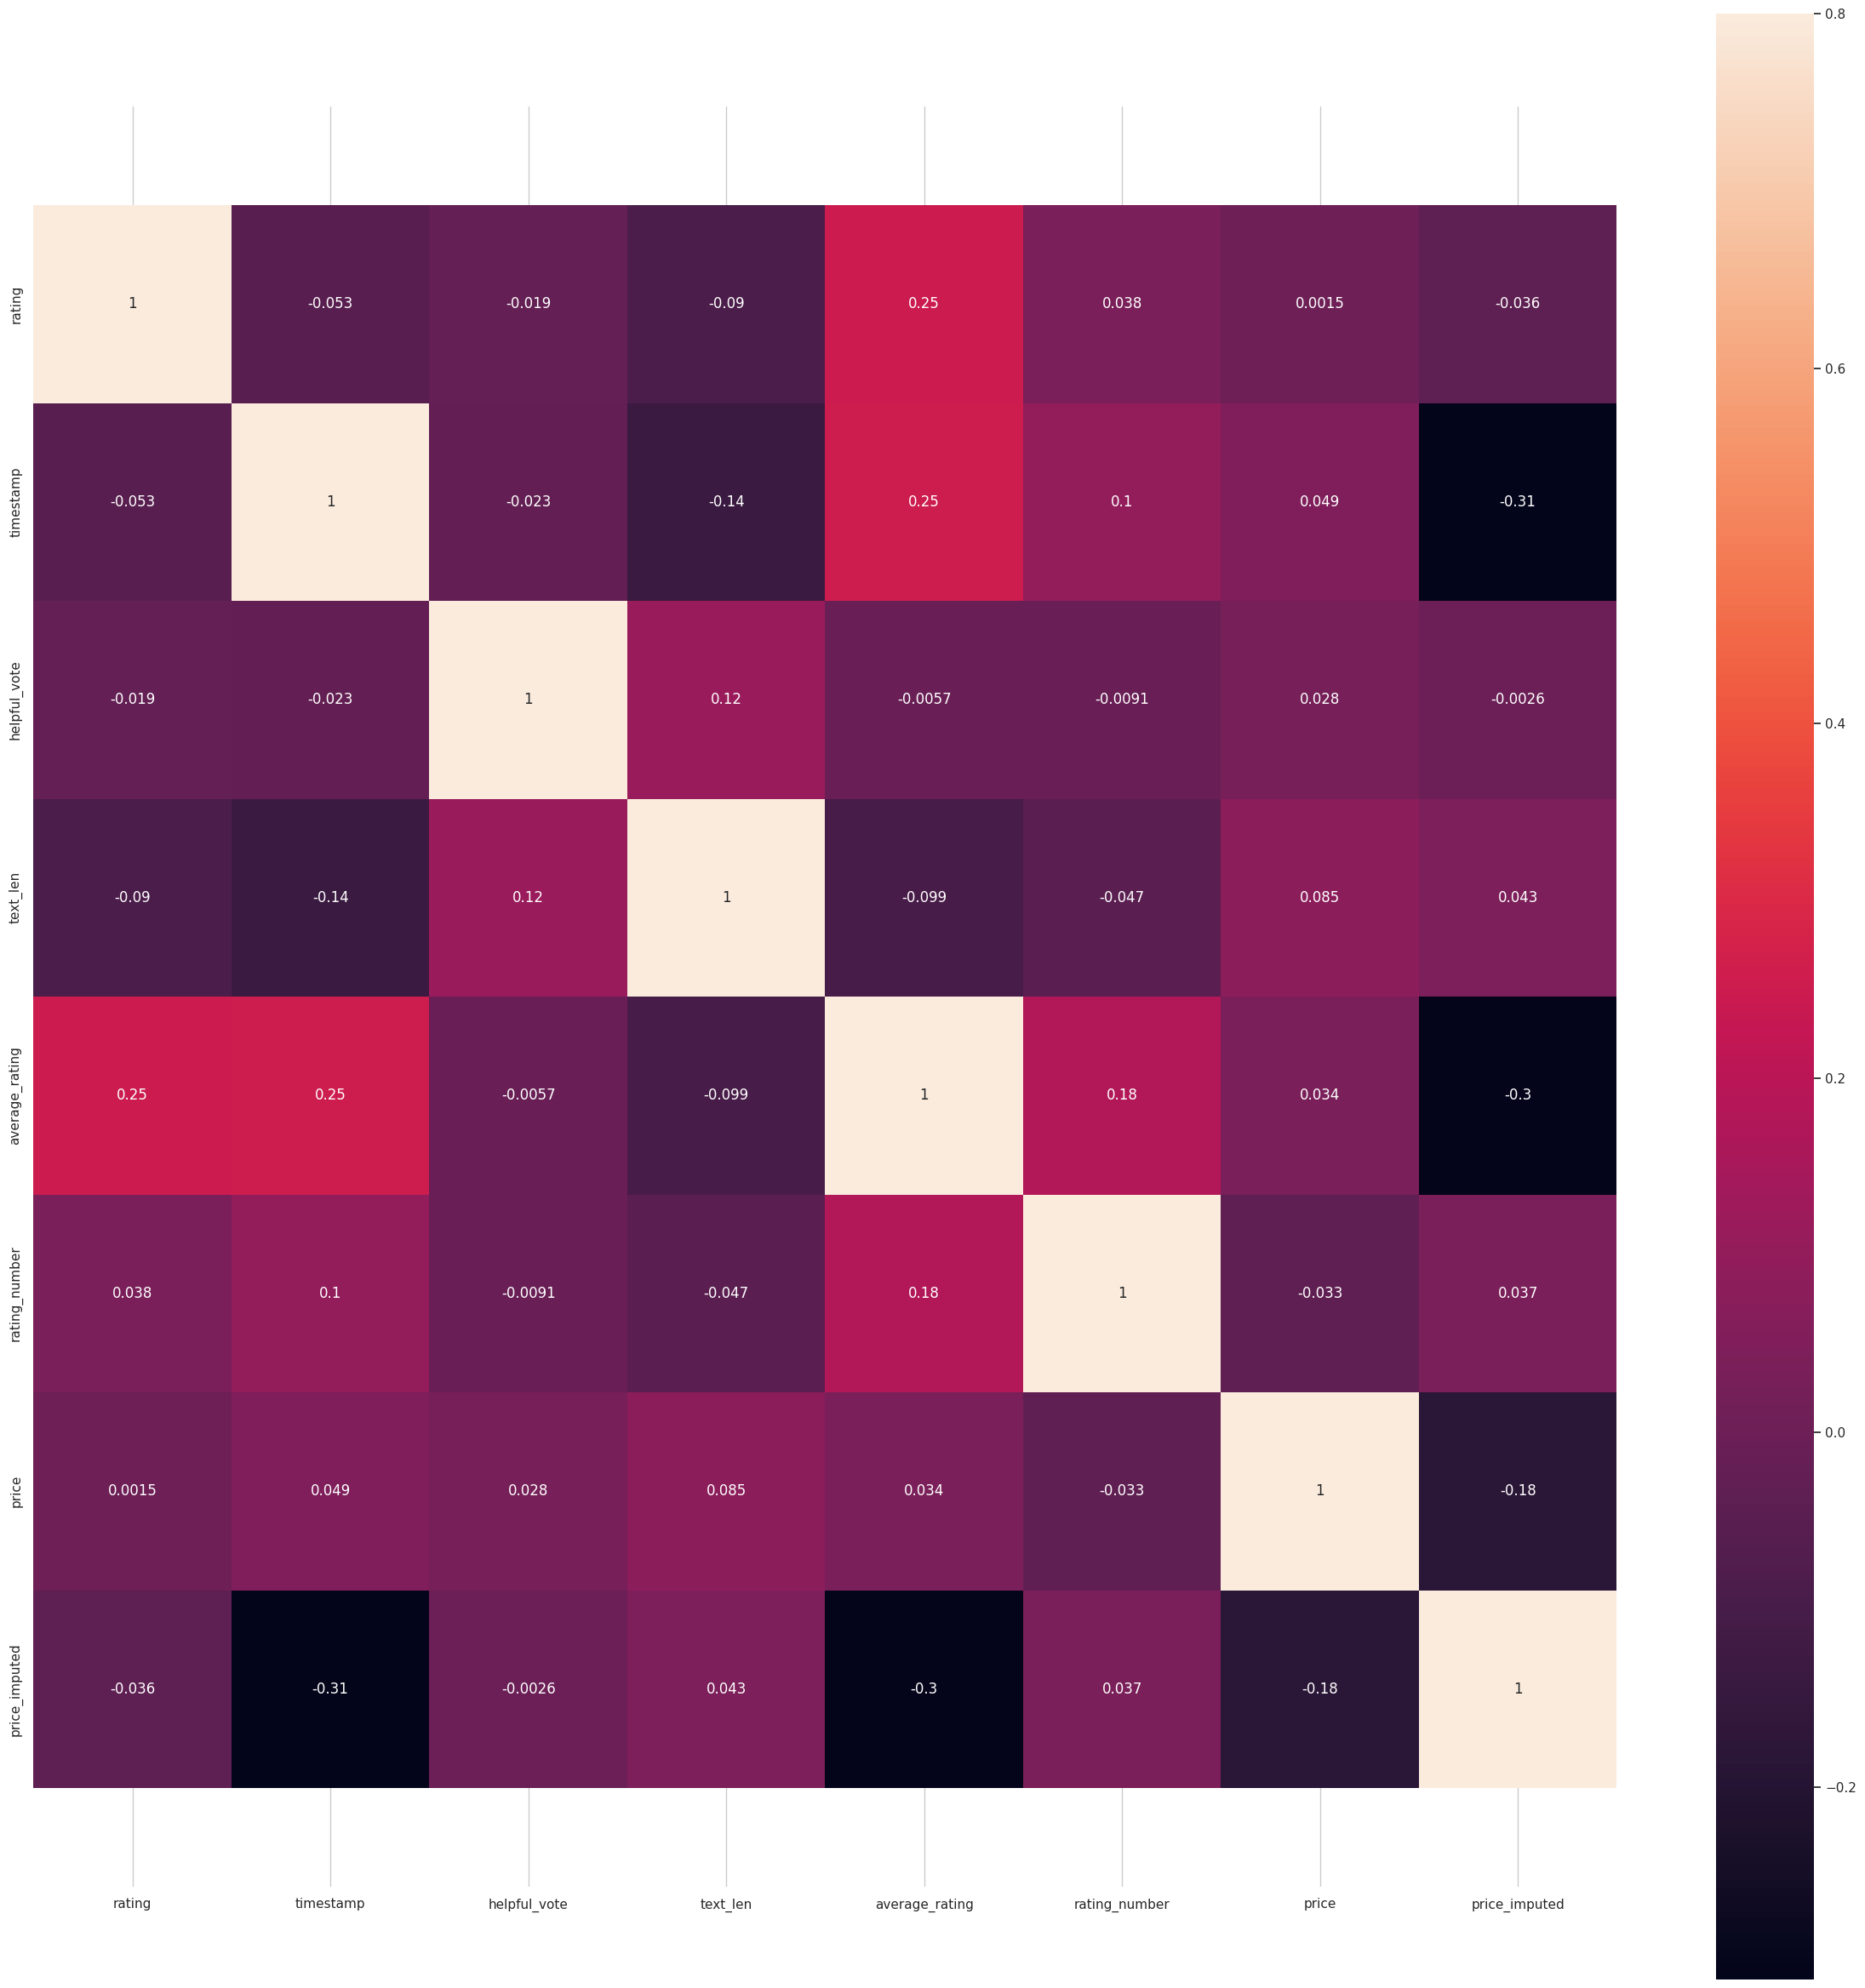

In [ ]:
# Correlation
# Select only numerical features for correlation analysis
numerical_features = df.select_dtypes(include=np.number).columns
corrmat = df[numerical_features].corr()

f, ax = plt.subplots(figsize=(30, 30))
ax=sb.heatmap(corrmat, vmax=.8, square=True, annot = True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom+0.5, top-0.5)

**NOTA:** El mapa de calor muestra la correlación entre los features que presenta el dataset. Se observa que la mayoría de las correlaciones son débiles o moderadas, tanto positivas como negativas. Por ejemplo:



**5. ID sin correlación relevante:**
La variable ID presenta correlaciones cercanas a 0 con todas las variables,
confirmando que es un identificador sin valor predictivo y debe ser
eliminado en el preprocesamiento.


## **2.4. Gráficos**

In [ ]:
sb.set_style("darkgrid")
sb.set(style="white")
sb.set(style="whitegrid", color_codes=True)


### **HELPFUL_VOTE**

Dada la relevancia de la variable helpful_vote como indicador de calidad, se realizó un análisis exploratorio mediante tres enfoques de visualización y transformación para determinar su viabilidad en el entrenamiento de los modelos:

<Axes: xlabel='helpful_vote', ylabel='Density'>

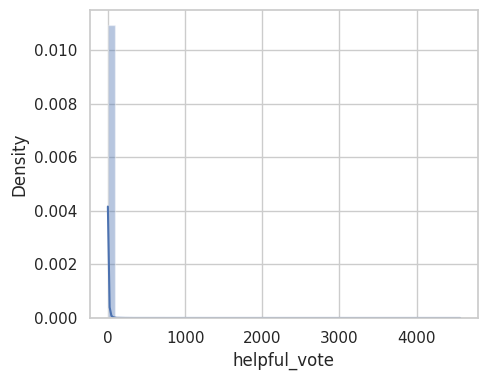

In [ ]:
sb.distplot(df['helpful_vote'])

**NOTA:** Distribución en Bruto: Se observó un sesgo extremo debido a la presencia masiva de reseñas con 0 votos en contraste con una minoría de reseñas con una cantidad muy elevada de interacciones. Esta dispersión dificulta la convergencia de modelos de regresión convencionales.

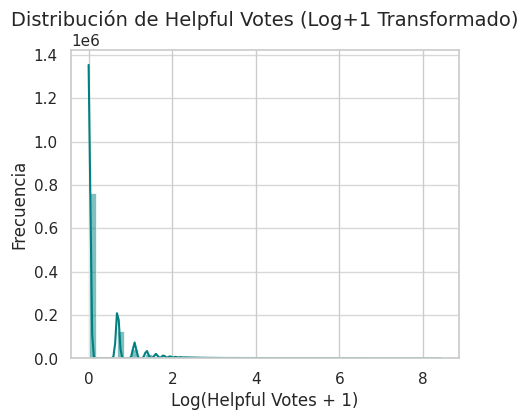


Estadísticas de 'helpful_vote_log':
count    1000000.000000
mean           0.273681
std            0.600248
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max            8.425955
Name: helpful_vote_log, dtype: float64


In [ ]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Aplicar la transformación log(x+1) a 'helpful_vote'
df['helpful_vote_log'] = np.log1p(df['helpful_vote'])

# Plot the distribution of the transformed column
sb.histplot(df['helpful_vote_log'], kde=True, bins=50, color='teal')
plt.title('Distribución de Helpful Votes (Log+1 Transformado)', fontsize=14)
plt.xlabel('Log(Helpful Votes + 1)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Display descriptive statistics for the transformed column
print("\nEstadísticas de 'helpful_vote_log':")
print(df['helpful_vote_log'].describe())

**NOTA:** Transformación Logarítmica: Se aplicó una escala logarítmica con el fin de normalizar la distribución y reducir el impacto de los valores atípicos (outliers). No obstante, el sesgo persistió de manera significativa, no logrando una distribución lo suficientemente simétrica para los requerimientos del modelo.

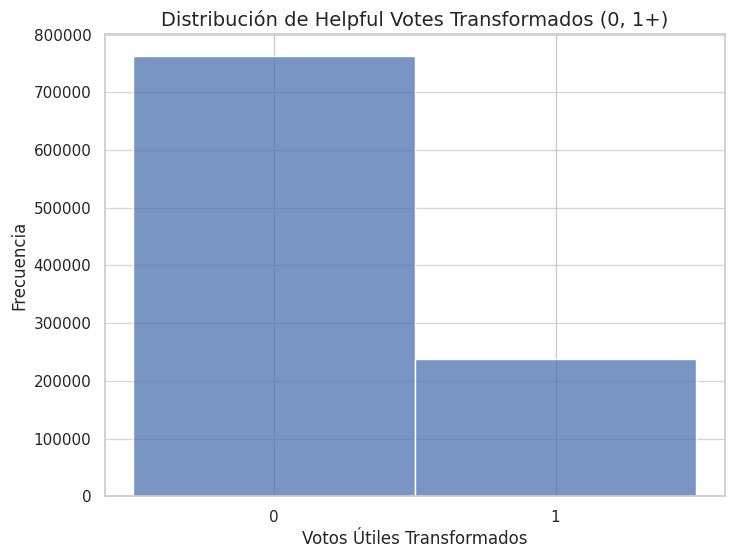


Conteo de valores de 'helpful_vote_transformed':
helpful_vote_transformed
0    762392
1    237608
Name: count, dtype: int64


In [ ]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Define the transformation function
def transform_helpful_vote_bins(x):
    if x == 0:
        return 0
    elif x >= 1:
        return 1
    else:
        return x # Should not happen if data is non-negative

# Apply the transformation to create a new series
df['helpful_vote_transformed'] = df['helpful_vote'].apply(transform_helpful_vote_bins)

# Plot the distribution of the transformed column
plt.figure(figsize=(8, 6))
sb.histplot(df['helpful_vote_transformed'], bins=sorted(df['helpful_vote_transformed'].unique()), discrete=True, stat="count", palette="viridis")
plt.title('Distribución de Helpful Votes Transformados (0, 1+)', fontsize=14)
plt.xlabel('Votos Útiles Transformados', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(sorted(df['helpful_vote_transformed'].unique()))
plt.grid(axis='y', alpha=0.75)
plt.show()

# Display value counts for the transformed column
print("\nConteo de valores de 'helpful_vote_transformed':")
print(df['helpful_vote_transformed'].value_counts().sort_index())

**NOTA:** (Enfoque Seleccionado): Finalmente, se optó por una transformación binaria donde los registros con 0 votos permanecen en 0, mientras que cualquier valor mayor o igual a 1 es codificado como 1.

**Decisión Final:**

 Se seleccionó la opción de binarización, transformando el problema de una regresión compleja en una tarea de clasificación binaria (reseña útil vs. reseña no útil). Este enfoque elimina el ruido provocado por los valores extremos y proporciona un target más estable y equilibrado para los algoritmos de aprendizaje supervisado.

### **RATING**

<Axes: xlabel='rating', ylabel='Density'>

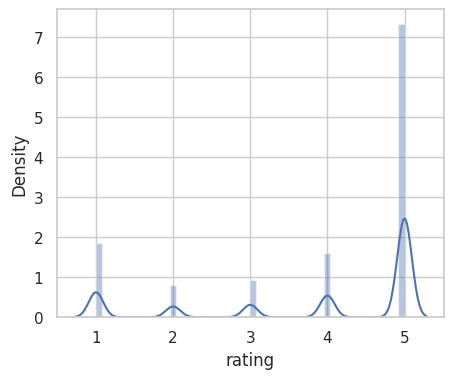

In [ ]:
sb.distplot(df['rating'])

**NOTA:** Se nos confirma nuevamente que tiene una distribucion uniforme ideal para trabajar como target en modelos

### **AVERAGE_RATING**

<Axes: xlabel='average_rating', ylabel='Density'>

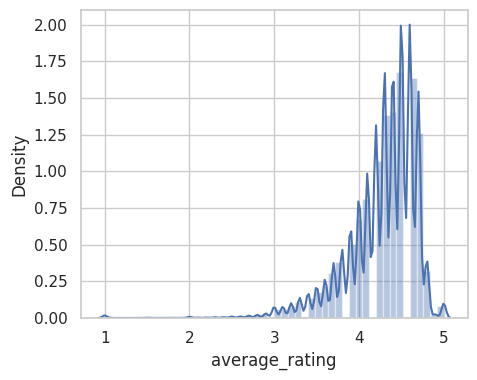

In [ ]:
sb.distplot(df['average_rating'])

**NOTA:** La variable average_rating presenta una asimetría negativa (o sesgo a la izquierda), lo que indica que la masa de la distribución se concentra en los valores superiores de la escala. Esto refleja una tendencia sistemática hacia calificaciones positivas por parte de los usuarios.

### **RATING NUMBER**

<Axes: xlabel='rating_number', ylabel='Density'>

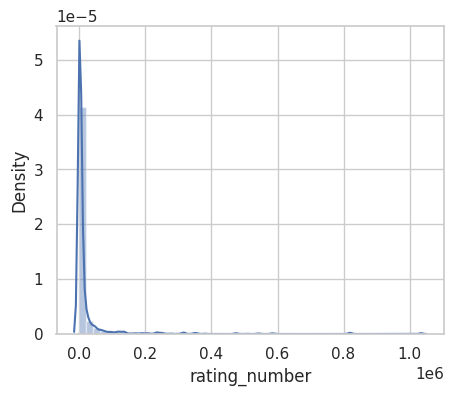

In [ ]:
sb.distplot(df['rating_number'])

**NOTA:** La variable rating_number presenta un  sesgo a la derecha. Esto indica que la gran mayoría de los productos cuentan con un volumen reducido de calificaciones, mientras que una minoría pequeña de observaciones (outliers) acumula una cantidad excepcionalmente alta de reseñas.

### **PRICE**

<Axes: xlabel='price', ylabel='Density'>

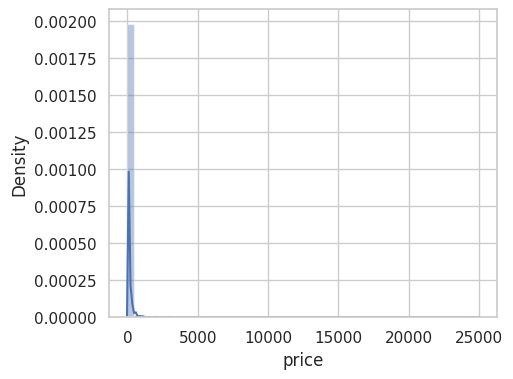

In [ ]:
sb.distplot(df['price'])

**NOTA:** La variable price presenta un  sesgo a la derecha. Esto indica que la gran mayoría de los productos cuentan con un volumen reducido de calificaciones, mientras que una minoría pequeña de observaciones (outliers) acumula una cantidad excepcionalmente alta de reseñas.
Pero por la gran cola se asume que existen precios muy altos en algunos casos

### **TEXT_LEN**

<Axes: xlabel='text_len', ylabel='Density'>

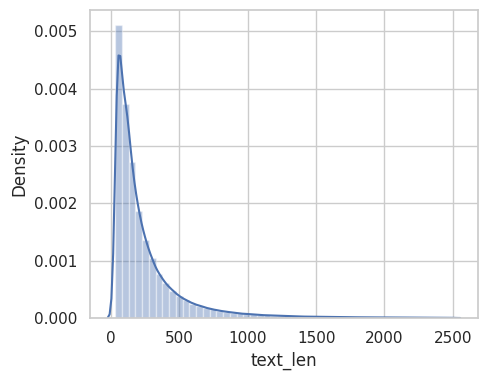

In [ ]:
sb.distplot(df['text_len'])

**NOTA:** La variable text_len presenta un  sesgo a la derecha. Esto indica que la gran mayoría de los productos cuentan con un volumen reducido de calificaciones, mientras que una minoría pequeña de observaciones (outliers) acumula una cantidad excepcionalmente alta de reseñas.
Puede llegar ha haber comentarios muy largos pero la mayoria no pasan de los 500 caracters

### **VERIFIED_PURCHASE**

<Axes: xlabel='verified_purchase', ylabel='Density'>

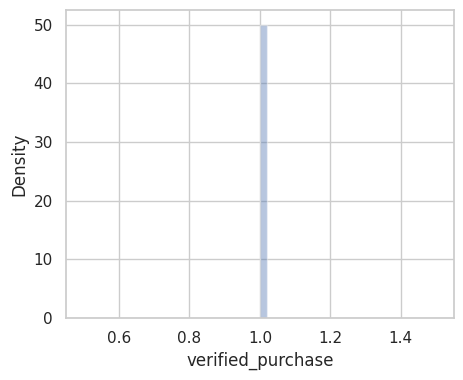

In [ ]:
sb.distplot(df['verified_purchase'])

**NOTA:** Todas las comprar fueron confirmadas

### **IS_SATISFIED**

<Axes: xlabel='is_satisfied', ylabel='Density'>

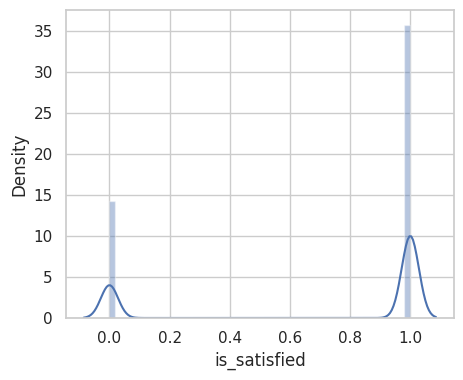

In [ ]:
sb.distplot(df['is_satisfied'])

**NOTA:** Hay un desbalance claro: los clientes insatisfechos superan por mucho a los satisfechos. En nuestro dataset, el '0' es la respuesta común y el '1' es más bien la excepción:

### **PRICE_IMPUTED**

<Axes: xlabel='price_imputed', ylabel='Density'>

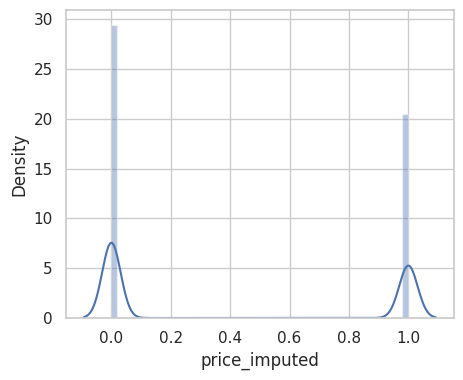

In [ ]:
sb.distplot(df['price_imputed'])

**NOTA:** Hay un desbalance claro: donde los '0' superan ligeramente a la poblacion de  '1'

### **PRECIO POR MAIN CATEGORY**

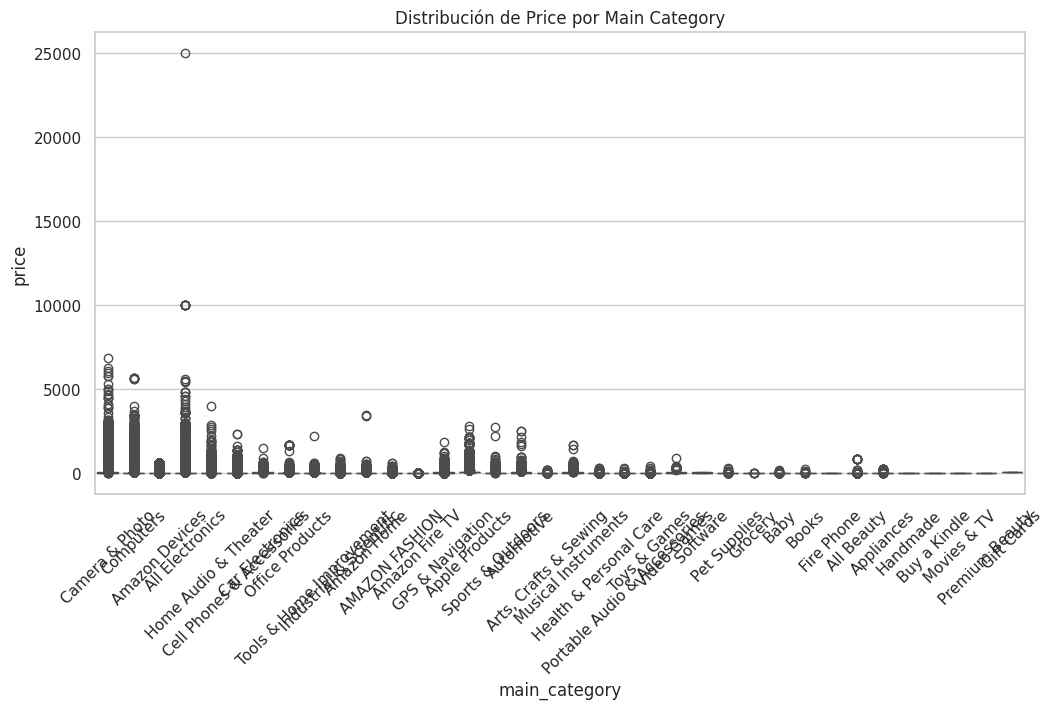

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='main_category',
    y='price'
)

plt.xticks(rotation=45)
plt.title('Distribución de Price por Main Category')
plt.show()

**Observaciones**
*   All electronics al ser una donde se qued ael resto de electrocnicos que no pudieron ser catalogados, de alguna manera es de los que mas varianza y diversidad tiene

*   Computadoras esta de segundo con una de las mayoares precios por categoria

### **PRICE X SENTIMENT**

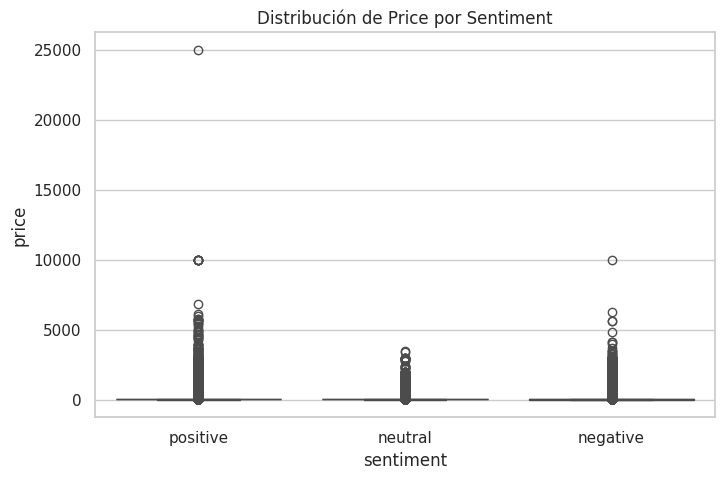

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='sentiment',
    y='price'
)

plt.title('Distribución de Price por Sentiment')
plt.show()

Se observa que no existe un gran realcion entre el precio y que sentimiento le dio el producto a la persona

### **2.4.1 BOXPLOT**


Para poder confirmar el sesgo de los target dentro que se tendra dentro del modelo variables se realizo la grafica de boxplot


### HELPFUL VOTE

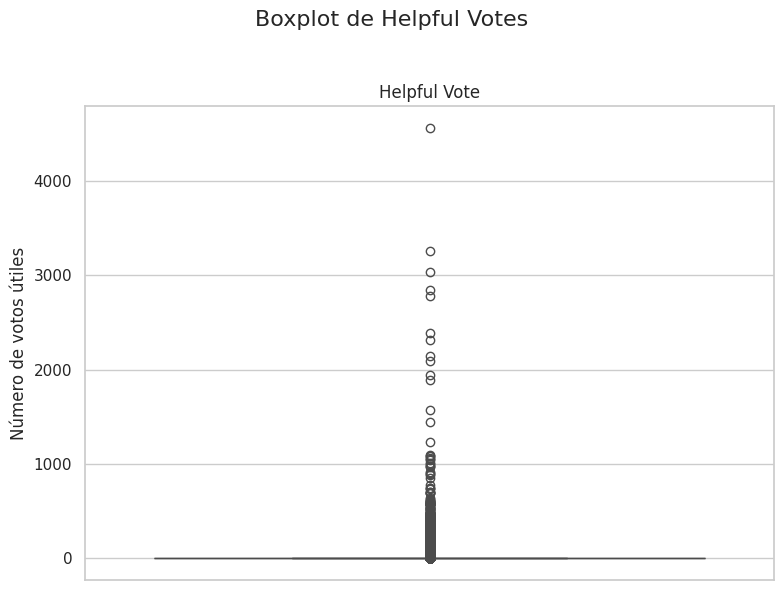

In [ ]:
# Crear figura para un solo boxplot
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Boxplot de Helpful Votes', fontsize=16)

sb.boxplot(data=df, y='helpful_vote', ax=ax)
ax.set_title('Helpful Vote')
ax.set_ylabel('Número de votos útiles')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**NOTA:** La visualización en el boxplot de los datos muestra un sesgo estructural que invalida cualquier análisis generalista. Al observar la distribución de los votos de utilidad, queda claro que el comportamiento es altamente dependiente de la categoría. La decisión de agrupar por 'helpful' y 'no helpful' es la respuesta técnica correcta para corregir esta distorsión y obtener métricas de tendencia central que realmente representen a cada segmento.

### RATING

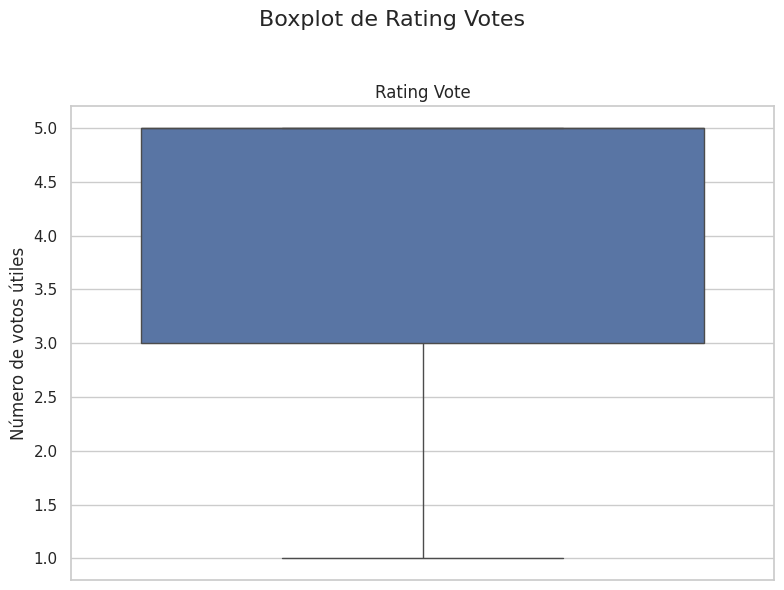

In [ ]:
# Crear figura para un solo boxplot
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Boxplot de Rating Votes', fontsize=16)

sb.boxplot(data=df, y='rating', ax=ax)
ax.set_title('Rating Vote')
ax.set_ylabel('Número de votos útiles')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**NOTA:** En contraste con la volatilidad observada en los votos, la variable rating exhibe una distribución armónica y consistente. Su comportamiento presenta una estabilidad estadística superior, lo que facilita la convergencia del modelo y aporta un anclaje de fiabilidad frente a la asimetría de otras variables.

### **2.4.2. MISELANEA**

### **Tasa de reviews por agrado (text_len, rating, helpful_vote)**

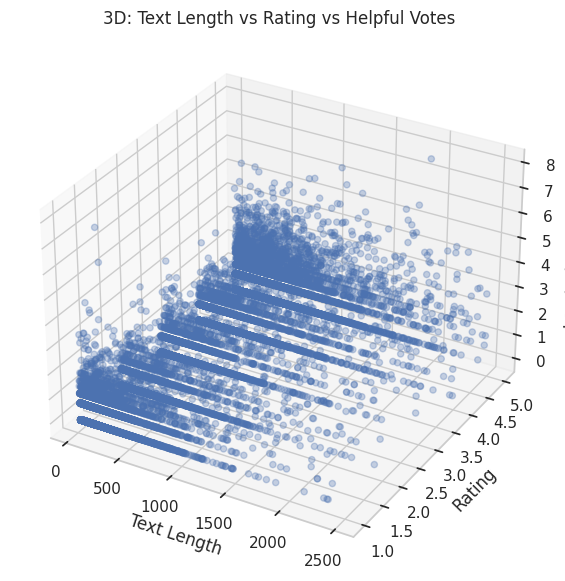

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# sample (MUY importante con 1M filas)
df_sample = df.sample(50000, random_state=42)

# transformación log
z = np.log1p(df_sample['helpful_vote'])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_sample['text_len'],   # X
    df_sample['rating'],     # Y
    z,                       # Z
    alpha=0.3
)

ax.set_xlabel('Text Length')
ax.set_ylabel('Rating')
ax.set_zlabel('Log Helpful Votes')

plt.title('3D: Text Length vs Rating vs Helpful Votes')
plt.show()

**NOTA:**

La visualización tridimensional revela una ausencia de correlación canónica entre la longitud del texto, la valoración y la utilidad percibida. Esta dispersión estocástica sugiere que la interacción entre estas dimensiones es compleja y no lineal; en otras palabras, la calidad de una reseña (medida en votos) no es una función directa de su extensión o de su puntaje, sino que depende de factores latentes que el análisis tridimensional simplificado no logra capturar.


### **Precio y reviews (price vs average_rating vs rating_number)**

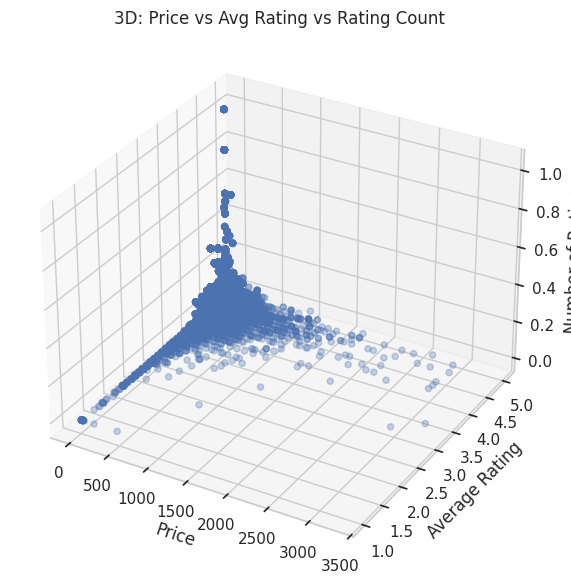

In [ ]:
df_sample = df.sample(50000, random_state=42)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_sample['price'],
    df_sample['average_rating'],
    df_sample['rating_number'],
    alpha=0.3
)

ax.set_xlabel('Price')
ax.set_ylabel('Average Rating')
ax.set_zlabel('Number of Ratings')

plt.title('3D: Price vs Avg Rating vs Rating Count')
plt.show()

**NOTA:**
El análisis tridimensional de la oferta y la valoración revela una asimetría estructural en los datos. Mientras que el precio y el volumen de reseñas (rating_number) exhiben un sesgo hacia el origen, concentrando la mayor densidad de la muestra en rangos inferiores, el rating promedio actúa como un contrapunto estadístico con una distribución de tendencia gaussiana. Esta disparidad sugiere que, si bien la participación y el coste se rigen por leyes de potencia (donde pocos elementos dominan el mercado), la satisfacción del usuario tiende a normalizarse, permitiendo una interpretación más equilibrada del rendimiento del producto

### **Sentimiento por tipo review (text_len, helpful_vote, sentiment)**

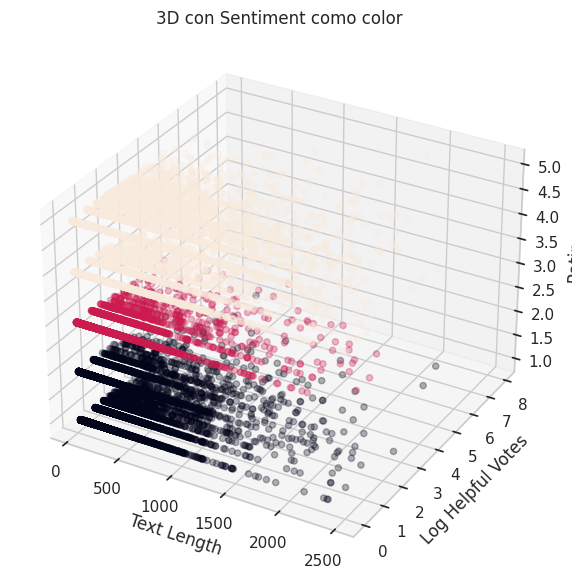

In [ ]:
import numpy as np

df_sample = df.sample(50000, random_state=42)

colors = df_sample['sentiment'].astype('category').cat.codes

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_sample['text_len'],
    np.log1p(df_sample['helpful_vote']),
    df_sample['rating'],
    c=colors,
    alpha=0.3
)

ax.set_xlabel('Text Length')
ax.set_ylabel('Log Helpful Votes')
ax.set_zlabel('Rating')

plt.title('3D con Sentiment como color')
plt.show()

**NOTA:** El análisis de la interacción entre el sentimiento, la extensión del texto y la utilidad percibida revela una correlación positiva inherente entre la polaridad afectiva y la valoración numérica (rating). Se observa una tendencia hacia la convergencia emocional, donde las puntuaciones más altas suelen estar respaldadas por un léxico predominantemente optimista.

En cuanto a la morfología de las reseñas, la variable text_len no presenta una dependencia funcional con el sentimiento; la distribución muestra una marcada preferencia por la brevedad, concentrando la masa crítica de datos en textos de extensión moderada. Esta independencia sugiere que la intensidad del agrado no requiere necesariamente de una argumentación extensa para ser manifestada, manteniendo una distribución de densidad estable y sin anomalías estructurales

## **2.5. HISTOGRAMA DE TODAS LAS VARIABLES**

array([[<Axes: title={'center': 'rating'}>,
        <Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'helpful_vote'}>],
       [<Axes: title={'center': 'text_len'}>,
        <Axes: title={'center': 'review_date'}>,
        <Axes: title={'center': 'average_rating'}>],
       [<Axes: title={'center': 'rating_number'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'price_imputed'}>],
       [<Axes: title={'center': 'helpful_vote_log'}>,
        <Axes: title={'center': 'helpful_vote_transformed'}>, <Axes: >]],
      dtype=object)

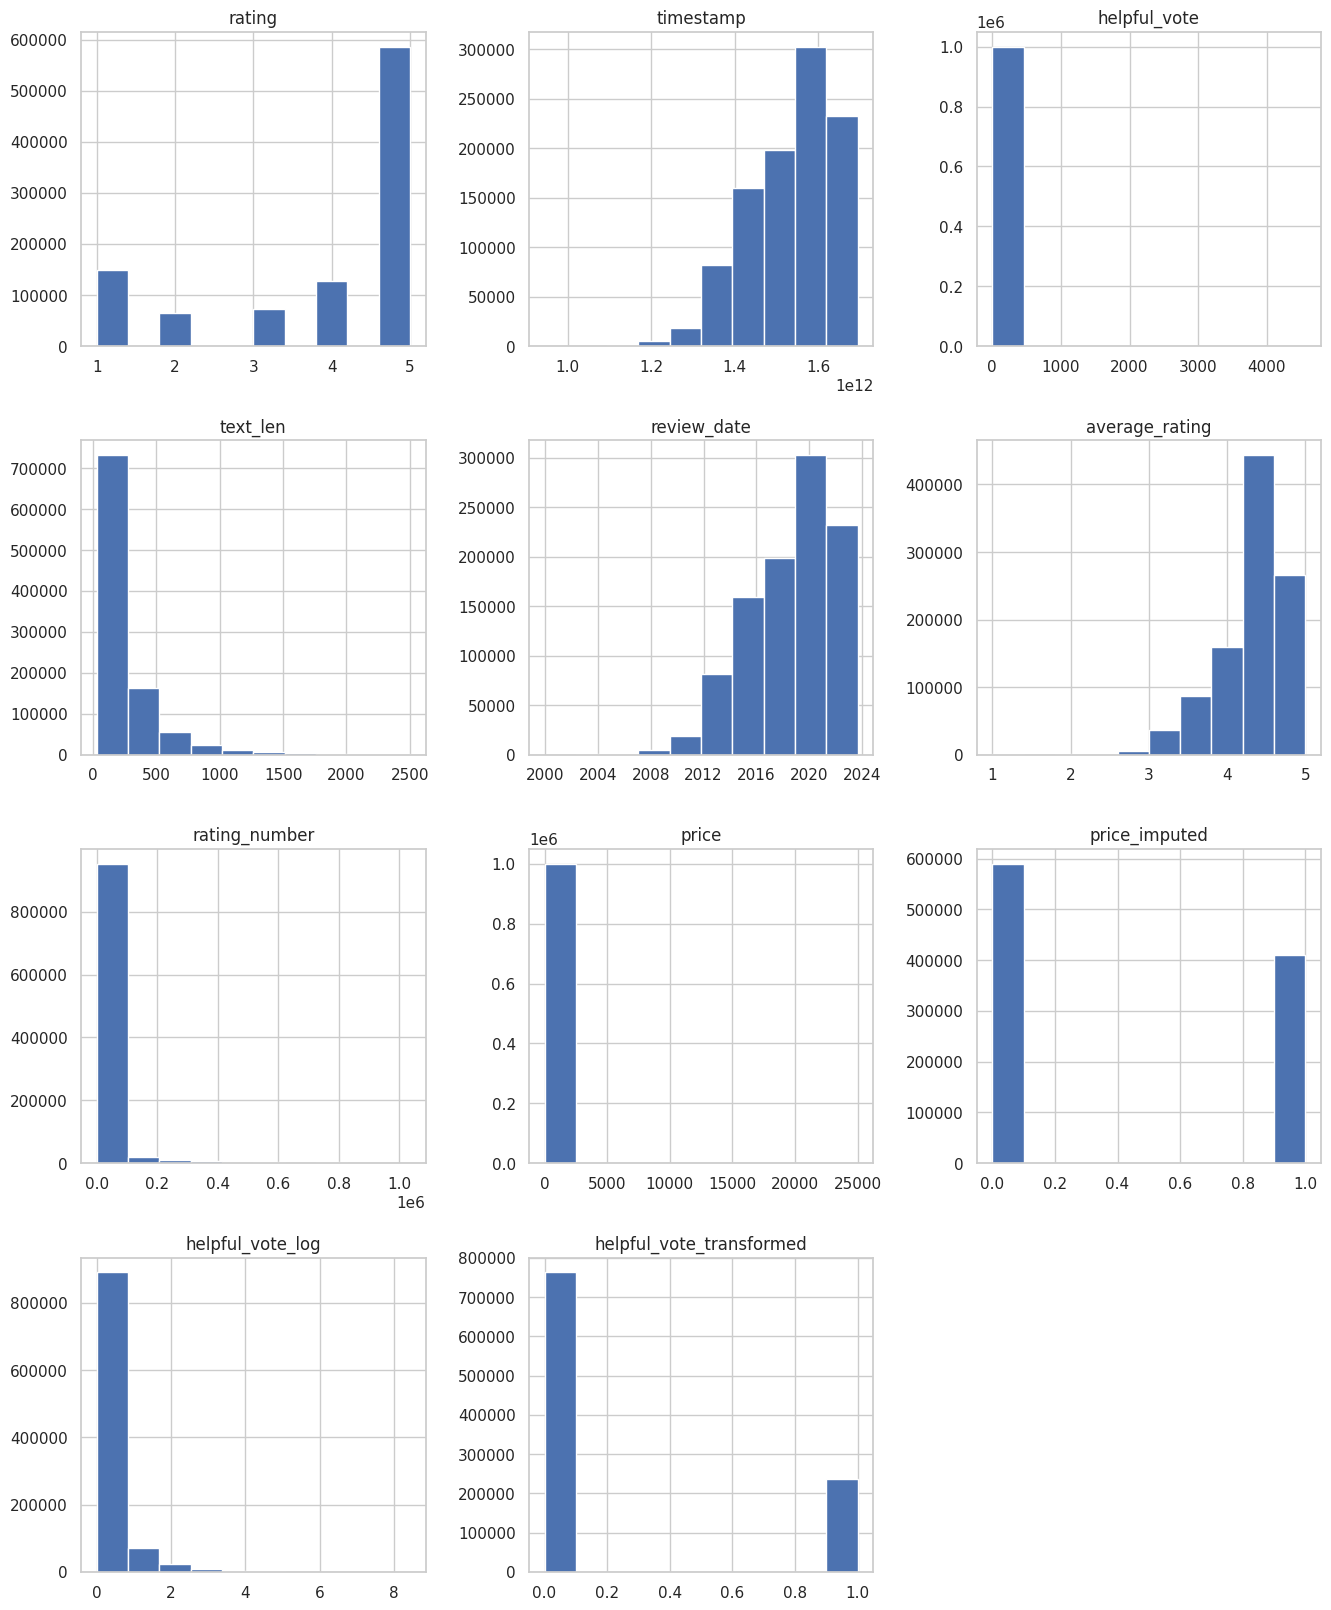

In [ ]:
df.hist(figsize=(16, 20))

**NOTA:** Como se peude evidenciar, se muestran los histogramas de las variables confirmando los gráficos y las distribuciones que siguen cada una de las variables anteriormente analizadas.

#**3. PREPROCESAMIENTO**

Despúes de realizar el EDA, se procedió a construir un proceso de preprocesamiento reproducible haciendo uso de Pipeline.

El objetivo de utilizar pipelines es evitar la fuga de información (data leakage) y asegurar que todas las tranformaciones se ajuten únicamente utilizando los datos de entrenamiento. De esta maner las estadísticas necesarias para el preprocesamiento se van a calcular solo en el conjunto de entenamiento para posteriormeten aplicarse en la validación y la prueba.


In [9]:
# Importación de librerías
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

### **Definición de Tipos de columnas**

En esta etapa se definen los distintos tipos de variables presentes en el dataset con el objetivo de aplicar transformaciones adecuadas durante el preprocesamiento. Separar las columnas por tipo permite utilizar herramientas como ColumnTransformer, que aplica diferentes transformaciones a cada grupo de variables dentro de un mismo pipeline.

In [10]:
cols_numericas = [
    'average_rating',  # rating promedio del producto
    'rating_number',   # cantidad total de reviews del producto
    'price',           # precio del producto
    'text_len',        # longitud de la reseña
]

cols_binarias = [
    'verified_purchase',  # bool → 0/1
    'is_satisfied',       # bool → 0/1
    'price_imputed',      # int8 → 0/1, bandera de imputación
]

# Las categóricas se tratan diferente según el pipeline debido a que usaremos catboost y lightgbm
cols_categoricas = [
    'sentiment',      # 'positive', 'neutral', 'negative'
    'main_category',  # categoría principal del producto
]

# Las genera el FeatureEngineering transformer DENTRO del pipeline
cols_engineered = [
    'text_price_ratio',    # text_len / price
    'log_rating_number',   # log1p(rating_number)
    'review_year',         # año de la reseña (desde timestamp)
    'review_month',        # mes de la reseña
]

# ─── Variables que NO entran al modelo ────────────────────────────

cols_texto = ['title', 'text']           # posible uso futuro con NLP

cols_drop = [
    'parent_asin',
    'features',
    'description',
    'details',
    'product_title',
]

# ─── Columnas usadas para construir X e y (no van como feature) ───
TARGET_CLF = 'helpful_vote'  # y_clf = (helpful_vote > 0)
TARGET_REG = 'rating'        # y_reg = rating numérico

print("Grupos definidos:")
print(f"  Numéricas ({len(cols_numericas)}):    {cols_numericas}")
print(f"  Binarias ({len(cols_binarias)}):     {cols_binarias}")
print(f"  Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"  Engineered ({len(cols_engineered)}):  {cols_engineered}")
print(f"  Total variables modelo: {len(cols_numericas)+len(cols_binarias)+len(cols_categoricas)+len(cols_engineered)}")

Grupos definidos:
  Numéricas (4):    ['average_rating', 'rating_number', 'price', 'text_len']
  Binarias (3):     ['verified_purchase', 'is_satisfied', 'price_imputed']
  Categóricas (2): ['sentiment', 'main_category']
  Engineered (4):  ['text_price_ratio', 'log_rating_number', 'review_year', 'review_month']
  Total variables modelo: 13


**NOTA:**

Para el desarrollo del modelo, se han identificado las dimensiones críticas que articulan la relación entre el producto y el consumidor. Estas variables numéricas continuas comprenden tanto atributos intrínsecos de la oferta (price) como métricas de validación social y desempeño en el mercado (average_rating, rating_number), junto con indicadores del comportamiento del usuario en su retroalimentación (text_len)

Con el objetivo de garantizar una comparabilidad estadística rigurosa y evitar sesgos derivados de las diferentes escalas de magnitud, todas estas variables han sido tratadas mediante un proceso de estandarización (StandardScaler). Este procedimiento transforma los datos para que presenten una media de cero y una varianza unitaria, asegurando que el modelo de aprendizaje automático interprete cada característica con la importancia relativa adecuada.

### Imputing Main Category

Durante la fase de Análisis Exploratorio de Datos EDA, se identificó una carencia de integridad en la variable main_category debido a registros nulos. Para mitigar la pérdida de información y preservar el volumen del dataset, se implementó un protocolo de recuperación jerárquico en dos etapas:

In [11]:
CATEGORY_KEYWORDS = {
    'Electronics':   ['phone', 'laptop', 'tablet', 'camera', 'battery', 'cable', 'speaker', 'headphone', 'monitor', 'keyboard'],
    'Clothing':      ['shirt', 'pant', 'dress', 'shoe', 'boot', 'jacket', 'coat', 'sock', 'hat', 'glove'],
    'Books':         ['book', 'novel', 'guide', 'manual', 'edition', 'volume', 'series', 'reader'],
    'Home':          ['chair', 'table', 'lamp', 'pillow', 'blanket', 'curtain', 'rug', 'shelf', 'organizer'],
    'Sports':        ['gym', 'yoga', 'bike', 'run', 'fitness', 'sport', 'ball', 'weight', 'dumbbell'],
    'Beauty':        ['cream', 'serum', 'moisturizer', 'shampoo', 'conditioner', 'lipstick', 'mascara', 'perfume'],
    'Toys':          ['toy', 'lego', 'doll', 'puzzle', 'game', 'action figure', 'play'],
    'Food':          ['coffee', 'tea', 'snack', 'chocolate', 'vitamin', 'supplement', 'protein'],
}

def infer_category_from_title(title):
    title_lower = str(title).lower()
    for cat, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in title_lower for kw in keywords):
            return cat
    return None

moda_categoria = df['main_category'].mode()[0]

mask_nulos = df['main_category'].isna()
print(f"Nulos en main_category antes: {mask_nulos.sum():,}")

df.loc[mask_nulos, 'main_category'] = df.loc[mask_nulos, 'product_title'].apply(infer_category_from_title)

mask_aun_nulos = df['main_category'].isna()
df.loc[mask_aun_nulos, 'main_category'] = moda_categoria

print(f"Nulos en main_category después: {df['main_category'].isna().sum():,}")
print(f"Moda usada como fallback: '{moda_categoria}'")
print(f"  → {(mask_nulos.sum() - mask_aun_nulos.sum()):,} imputados por título, {mask_aun_nulos.sum():,} por moda")

Nulos en main_category antes: 16,834
Nulos en main_category después: 0
Moda usada como fallback: 'All Electronics'
  → 11,424 imputados por título, 5,410 por moda


### Definición de X e y

In [12]:
# Columnas que deben existir en X para el pipeline
cols_modelo = cols_numericas + cols_binarias + cols_categoricas + ['timestamp']
# timestamp entra solo para que FeatureEngineering extraiga year/month, luego se descarta

cols_excluir = [TARGET_CLF, TARGET_REG] + cols_drop + cols_texto

X = df.drop(columns=cols_excluir)
y_clf = (df[TARGET_CLF] > 0).astype(int)
y_reg = df[TARGET_REG].copy()

print(f"X shape:  {X.shape}")
print(f"Columnas en X: {list(X.columns)}")
print(f"\ny_clf shape: {y_clf.shape} | clases: {y_clf.value_counts().to_dict()}")
print(f"y_reg shape: {y_reg.shape} | media={y_reg.mean():.4f}, std={y_reg.std():.4f}")

X shape:  (1000000, 11)
Columnas en X: ['timestamp', 'verified_purchase', 'text_len', 'sentiment', 'is_satisfied', 'review_date', 'main_category', 'average_rating', 'rating_number', 'price', 'price_imputed']

y_clf shape: (1000000,) | clases: {0: 762392, 1: 237608}
y_reg shape: (1000000,) | media=3.9403, std=1.4982


### **División del datase**

Se procede a dividir el dataset en dos partes, un conjunto de entrenamiento (60%), validación (20%) y otro conjunto de prueba (20%). Esta división se la realizó con *StratifiedShuffleSplit*, que nos permite mantener la misma proporción de clases de la variable default en ambos conjuntos.

El objetivo de esta división es reservar el conjunto de test solo para la evaluación final del modelo, mientras que el conjunto de train y validation se utilizarán para entrenar los modelos y ajustar sus parámetros.

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

subsample = StratifiedShuffleSplit(n_splits=1, train_size=0.30, random_state=42)

for sub_idx, _ in subsample.split(X, y_clf):
    X = X.iloc[sub_idx]
    y_clf = y_clf.iloc[sub_idx]
    y_reg = y_reg.iloc[sub_idx]

print(f"Nuevo tamaño del dataset: {len(X):,} (30%)")

Nuevo tamaño del dataset: 300,000 (30%)


In [14]:
# Paso 1: separar test (20%)
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
for train_val_idx, test_idx in split1.split(X, y_clf):
    X_train_val     = X.iloc[train_val_idx]
    X_test          = X.iloc[test_idx]
    y_clf_train_val = y_clf.iloc[train_val_idx]
    y_clf_test      = y_clf.iloc[test_idx]
    y_reg_train_val = y_reg.iloc[train_val_idx]
    y_reg_test      = y_reg.iloc[test_idx]

# Paso 2: del 80% restante, separar val (25% de 80% = 20% global)
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
for train_idx, val_idx in split2.split(X_train_val, y_clf_train_val):
    X_train     = X_train_val.iloc[train_idx]
    X_val       = X_train_val.iloc[val_idx]
    y_clf_train = y_clf_train_val.iloc[train_idx]
    y_clf_val   = y_clf_train_val.iloc[val_idx]
    y_reg_train = y_reg_train_val.iloc[train_idx]
    y_reg_val   = y_reg_train_val.iloc[val_idx]

print("Tamaños del split:")
print(f"  Train:      {len(X_train):>7,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Validation: {len(X_val):>7,} ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test:       {len(X_test):>7,} ({len(X_test)/len(X)*100:.0f}%)")

print("\nEstrificación (proporción y_clf == 1):")
print(f"  Train:      {y_clf_train.mean():.3f}")
print(f"  Validation: {y_clf_val.mean():.3f}")
print(f"  Test:       {y_clf_test.mean():.3f}")

Tamaños del split:
  Train:      180,000 (60%)
  Validation:  60,000 (20%)
  Test:        60,000 (20%)

Estrificación (proporción y_clf == 1):
  Train:      0.238
  Validation: 0.238
  Test:       0.238


NOTA: Se verifica el tamaño de cada subconjunto genrado después de la división del dataset, ello con el fin de confirmar que las proporciones sean aproximadamente 60% para train, 20% para validation y 20% para test. Como se puede evidenciar el dataste se encuentra dividido de manera correcta.

Asimismo, se calcula la proporción de la clase default (valor 1) en cada subconjunto, ello para poder comprobar que la estratificación se haya realizado correctamente y que la distribución de clases sea similar en los conjuntos de entrenamiento, validación y prueba, evitando sesgos en el entrenamiento y evaluación de los modelos.

### Feature Engineering (dentro del pipeline)

El `FeatureEngineering` se ejecuta **dentro** del pipeline, solo ve datos de training durante el `fit`. Genera las variables derivadas y descarta `timestamp` (ya no se necesita).

Variables creadas:
- text_price_ratio: longitud del texto / precio (reseñas largas en productos baratos)
- log_rating_number: log1p del número de ratings (comprime la escala)
- review_year: año de la reseña
- review_month: mes de la reseña

In [15]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    """Crea variables derivadas. Se ajusta sin aprender nada del train
    (transformaciones puramente matemáticas), por lo que no hay riesgo
    de fuga de datos."""

    def fit(self, X, y=None, **kwargs):  # Added **kwargs to accept arbitrary keyword arguments
        return self  # sin estado que aprender

    def transform(self, X):
        X = X.copy()

        # 1. Ratio texto / precio
        X['text_price_ratio'] = X['text_len'] / (X['price'].replace(0, np.nan)).fillna(1)

        # 2. Log del número de ratings
        X['log_rating_number'] = np.log1p(X['rating_number'])

        # 3. Extraer año y mes desde timestamp (en millisegundos → segundos)
        ts = pd.to_datetime(X['timestamp'], unit='ms', errors='coerce')
        X['review_year']  = ts.dt.year.astype('Int32')
        X['review_month'] = ts.dt.month.astype('Int32')

        # 4. Eliminar timestamp (ya fue usado)
        X = X.drop(columns=['timestamp'])

        return X

### Pipeline Numérico

Para garantizar que los algoritmos de aprendizaje —específicamente nuestras líneas base (baselines) de Regresión Lineal y Logística— procesen la información de manera óptima, se ha diseñado un flujo de transformación integral. Dado que estos modelos son matemáticamente estrictos y no admiten datos categóricos crudos (strings), el proceso se define bajo los siguientes pilares:

In [16]:
# Columnas de engineered que se escalan igual que las numéricas
cols_engineered_numericas = ['text_price_ratio', 'log_rating_number', 'review_year', 'review_month']

preprocesador_num = ColumnTransformer(
    transformers=[
        # Numéricas originales + engineered → escalar
        ('num', StandardScaler(), cols_numericas + cols_engineered_numericas),
        # Binarias → pasar tal cual (ya son 0/1)
        ('bin', 'passthrough', cols_binarias),
        # Categóricas → codificar a entero antes de escalar
        ('cat_enc',
         Pipeline([
             ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
             ('scl', StandardScaler()),
         ]),
         cols_categoricas),
    ],
    remainder='drop'  # descarta cualquier columna no listada
)

pipeline_num = Pipeline([
    ('feature_eng',   FeatureEngineering()),   # crea variables derivadas + elimina timestamp
    ('preprocesador', preprocesador_num),      # escala / codifica
])

print("Pipeline numérico definido.")

Pipeline numérico definido.


### Pipeline Categorico

Durante el preprocesamiento, las variables numéricas y las variables creadas mediante feature engineering se escalan utilizando StandardScaler. Esto se hace porque estas variables representan montos financieros o valores continuos que pueden tener rangos muy diferentes. Por ejemplo, el límite de crédito (LIMIT_BAL) puede tomar valores muy altos, mientras que otras variables pueden tener valores mucho menores como AGE. Si estas variables se utilizan sin escalado, aquellas con valores más grandes podrían dominar el entrenamiento del modelo, afectando su desempeño. El escalado permite que todas las variables numéricas tengan una escala comparable, lo que ayuda a que los modelos aprendan de forma más estable y eficiente.

Por otro lado, las variables de estado de pago (PAY_*) no se escalan porque son variables ordinales, donde los valores representan niveles de retraso en el pago y su escala ya tiene un significado. De igual forma, las variables categóricas (SEX, EDUCATION, MARRIAGE) se mantienen sin transformación, ya que representan categorías y no magnitudes numéricas.

De esta manera, cada tipo de variable recibe el tratamiento adecuado dentro del pipeline de preprocesamiento.

Mantiene las variables categóricas como **strings** (sin OrdinalEncoder). CatBoost y LightGBM las procesan nativamente, lo cual suele dar mejor resultado que pre-codificar.

Las variables numéricas sí se escalan (LightGBM no lo requiere, pero no hace daño y da consistencia).

**Sin fuga de datos:** el `StandardScaler` se ajusta solo con `X_train`.

In [17]:
preprocesador_cat = ColumnTransformer(
    transformers=[
        # Numéricas originales + engineered → escalar
        ('num', StandardScaler(), cols_numericas + cols_engineered_numericas),
        # Binarias → pasar tal cual
        ('bin', 'passthrough', cols_binarias),
        # Categóricas → pasar como string (CatBoost/LGBM las leen directamente)
        ('cat', 'passthrough', cols_categoricas),
    ],
    remainder='drop'
)

pipeline_cat = Pipeline([
    ('feature_eng',   FeatureEngineering()),
    ('preprocesador', preprocesador_cat),
])

print("Pipeline categórico definido.")

Pipeline categórico definido.


### **Aplicación del pipeline de Preprocesamiento**

Una vez definido el pipeline, se aplica primero al conjunto de entrenamiento utilizando fit_transform. Esto permite que el pipeline aprenda las transformaciones necesarias únicamente a partir de los datos de entrenamiento.

Posteriormente, el mismo pipeline se aplica a los conjuntos de validación y prueba utilizando transform, lo que garantiza que las transformaciones aprendidas en el entrenamiento se utilicen de forma consistente en los demás conjuntos, evitando así fuga de información (data leakage).



In [18]:
# ── Pipeline NUMÉRICO (Regresión Lineal / baseline) ──────────────────
X_train_num = pipeline_num.fit_transform(X_train)
X_val_num   = pipeline_num.transform(X_val)
X_test_num  = pipeline_num.transform(X_test)

print("=== Pipeline NUMÉRICO ===")
print(f"  X_train_num: {X_train_num.shape}")
print(f"  X_val_num:   {X_val_num.shape}")
print(f"  X_test_num:  {X_test_num.shape}")

# ── Pipeline CATEGÓRICO (CatBoost / LightGBM) ────────────────────────
X_train_cat = pipeline_cat.fit_transform(X_train)
X_val_cat   = pipeline_cat.transform(X_val)
X_test_cat  = pipeline_cat.transform(X_test)

print("\n=== Pipeline CATEGÓRICO ===")
print(f"  X_train_cat: {X_train_cat.shape}")
print(f"  X_val_cat:   {X_val_cat.shape}")
print(f"  X_test_cat:  {X_test_cat.shape}")

=== Pipeline NUMÉRICO ===
  X_train_num: (180000, 13)
  X_val_num:   (60000, 13)
  X_test_num:  (60000, 13)

=== Pipeline CATEGÓRICO ===
  X_train_cat: (180000, 13)
  X_val_cat:   (60000, 13)
  X_test_cat:  (60000, 13)


### Verificaciones

**COLUMNAS Y NOMBRES**

In [19]:
# Nombres de columnas del pipeline numérico
feature_names_num = (
    cols_numericas +
    cols_engineered_numericas +
    cols_binarias +
    cols_categoricas
)

# Nombres de columnas del pipeline categórico (iguales en este caso)
feature_names_cat = feature_names_num.copy()

n_esperadas = len(feature_names_num)

assert X_train_num.shape[1] == n_esperadas, \
    f"Pipeline NUM: esperaba {n_esperadas} columnas, obtuvo {X_train_num.shape[1]}"
assert X_train_cat.shape[1] == n_esperadas, \
    f"Pipeline CAT: esperaba {n_esperadas} columnas, obtuvo {X_train_cat.shape[1]}"

print(f"Número de variables en ambos pipelines: {n_esperadas}")
print(f"\nNombres de columnas (orden):")
for i, name in enumerate(feature_names_num):
    print(f"  [{i:2d}] {name}")

print("\n✓ Pipelines verificados correctamente.")

Número de variables en ambos pipelines: 13

Nombres de columnas (orden):
  [ 0] average_rating
  [ 1] rating_number
  [ 2] price
  [ 3] text_len
  [ 4] text_price_ratio
  [ 5] log_rating_number
  [ 6] review_year
  [ 7] review_month
  [ 8] verified_purchase
  [ 9] is_satisfied
  [10] price_imputed
  [11] sentiment
  [12] main_category

✓ Pipelines verificados correctamente.


In [20]:
print(X_train_num.shape)
# X_train_num.info()

(180000, 13)


**NO FUGA DE DATOS**

In [21]:
# El scaler vive en pipeline_num['preprocesador'].transformers_[0][1]
scaler_num = pipeline_num.named_steps['preprocesador'].named_transformers_['num']

print("Verificación de data leakage (StandardScaler del pipeline numérico):")
print(f"  mean_ calculada sobre train (primeras 4 cols): {scaler_num.mean_[:4].round(4)}")

# Comparar media de train vs val para confirmar que NO son iguales
# (si hubiera leakage, serían casi idénticas)
media_train_cruda = X_train[cols_numericas].mean().values
media_val_cruda   = X_val[cols_numericas].mean().values

print(f"  Media real train (cruda): {media_train_cruda.round(4)}")
print(f"  Media real val   (cruda): {media_val_cruda.round(4)}")
print("  → Scaler ajustado con train: correcto, sin fuga de datos.")

Verificación de data leakage (StandardScaler del pipeline numérico):
  mean_ calculada sobre train (primeras 4 cols): [4.27240000e+00 2.13457109e+04 5.15898000e+01 2.45289500e+02]
  Media real train (cruda): [4.27240000e+00 2.13457109e+04 5.15898000e+01 2.45289500e+02]
  Media real val   (cruda): [4.27480000e+00 2.13461386e+04 5.09678000e+01 2.44697600e+02]
  → Scaler ajustado con train: correcto, sin fuga de datos.


**RESUMEN**

In [22]:
print("="*55)
print("RESUMEN DE PREPROCESAMIENTO")
print("="*55)
print(f"\nVariables de entrada: {n_esperadas}")
print(f"  {feature_names_num}")

print(f"\n{'Conjunto':<20} {'Numérico':>12} {'Categórico':>12}")
print("-"*46)
print(f"{'X_train':<20} {str(X_train_num.shape):>12} {str(X_train_cat.shape):>12}")
print(f"{'X_val':<20} {str(X_val_num.shape):>12} {str(X_val_cat.shape):>12}")
print(f"{'X_test':<20} {str(X_test_num.shape):>12} {str(X_test_cat.shape):>12}")

print("\nTargets disponibles:")
print(f"  y_clf_train: {y_clf_train.shape} (clasificación: helpful_vote > 0)")
print(f"  y_reg_train: {y_reg_train.shape} (regresión: rating)")

print("\nPipelines guardados:")
print("  pipeline_num → usar con Regresión Lineal (baseline)")
print("  pipeline_cat → usar con CatBoost / LightGBM")
print("\n✓ Preprocesamiento completo. Sin fuga de datos.")

RESUMEN DE PREPROCESAMIENTO

Variables de entrada: 13
  ['average_rating', 'rating_number', 'price', 'text_len', 'text_price_ratio', 'log_rating_number', 'review_year', 'review_month', 'verified_purchase', 'is_satisfied', 'price_imputed', 'sentiment', 'main_category']

Conjunto                 Numérico   Categórico
----------------------------------------------
X_train              (180000, 13) (180000, 13)
X_val                 (60000, 13)  (60000, 13)
X_test                (60000, 13)  (60000, 13)

Targets disponibles:
  y_clf_train: (180000,) (clasificación: helpful_vote > 0)
  y_reg_train: (180000,) (regresión: rating)

Pipelines guardados:
  pipeline_num → usar con Regresión Lineal (baseline)
  pipeline_cat → usar con CatBoost / LightGBM

✓ Preprocesamiento completo. Sin fuga de datos.


**NOTA:** Asimismo, se procede a verificar la forma de los datos transformados para asegurar que el número de columnas resultante sea el esperado. En este caso, después del preprocesamiento el conjunto de entrenamiento contiene 18,000 observaciones y 13 variables, mientras que los conjuntos de validación y prueba contienen 6,000 observaciones cada uno, manteniendo las mismas 13 variables. Esta verificación confirma que el pipeline se ejecutó correctamente y que todas las transformaciones se aplicaron como se esperaba.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   rating             1000000 non-null  float64       
 1   title              1000000 non-null  object        
 2   text               1000000 non-null  object        
 3   parent_asin        1000000 non-null  object        
 4   timestamp          1000000 non-null  int64         
 5   helpful_vote       1000000 non-null  int64         
 6   verified_purchase  1000000 non-null  bool          
 7   text_len           1000000 non-null  uint32        
 8   sentiment          1000000 non-null  object        
 9   is_satisfied       1000000 non-null  bool          
 10  review_date        1000000 non-null  datetime64[us]
 11  main_category      1000000 non-null  object        
 12  average_rating     1000000 non-null  float64       
 13  rating_number      1000000 n

In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 768481 to 278973
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   timestamp          300000 non-null  int64         
 1   verified_purchase  300000 non-null  bool          
 2   text_len           300000 non-null  uint32        
 3   sentiment          300000 non-null  object        
 4   is_satisfied       300000 non-null  bool          
 5   review_date        300000 non-null  datetime64[us]
 6   main_category      300000 non-null  object        
 7   average_rating     300000 non-null  float64       
 8   rating_number      300000 non-null  int64         
 9   price              300000 non-null  float64       
 10  price_imputed      300000 non-null  int8          
dtypes: bool(2), datetime64[us](1), float64(2), int64(2), int8(1), object(2), uint32(1)
memory usage: 20.3+ MB


# **4. MODELADO**

## **4.1. REGRESIÓN**


Se entrenan tres modelos de regresión sobre la variable objetivo `rating`:



**Nota sobre los datos de entrada:**

 Los pipelines ya transformaron los datos. Los modelos reciben directamente los arrays `X_train_num` / `X_train_cat`, etc. **No se vuelve a aplicar `FeatureEngineering` ni `preprocesador` aquí** — eso ya ocurrió en la sección 3.

| Modelo | Pipeline | Propósito |
|---|---|---|
| **Regresión Lineal** | `pipeline_num` (todo numérico) | Baseline — punto de referencia |
| **LightGBM** | `pipeline_cat` (categóricas como string) | Modelo boosting rápido |
| **CatBoost** | `pipeline_cat` (categóricas como string) | Modelo boosting con soporte nativo de categorías |

In [22]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


### Funcion Evaluacion

In [23]:
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_modelo(nombre, y_true_train, y_pred_train, y_true_val, y_pred_val):
    """Imprime y devuelve métricas de train y validación para un modelo."""
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    rmse_val   = np.sqrt(mean_squared_error(y_true_val,   y_pred_val))
    mae_val    = mean_absolute_error(y_true_val, y_pred_val)
    r2_val     = r2_score(y_true_val, y_pred_val)

    print(f"\n{'='*45}")
    print(f"  {nombre.upper()}")
    print(f"{'='*45}")
    print(f"  RMSE train : {rmse_train:.4f}")
    print(f"  RMSE val   : {rmse_val:.4f}")
    print(f"  MAE  val   : {mae_val:.4f}")
    print(f"  R²   val   : {r2_val:.4f}")

    gap = rmse_val - rmse_train
    if abs(gap) < 0.05:
        print("  → Sin overfitting aparente.")
    elif gap > 0:
        print(f"  → Posible overfitting (gap RMSE: +{gap:.4f}).")
    else:
        print(f"  → Val mejor que train (revisar split).")

    return {"modelo": nombre, "rmse_train": rmse_train,
            "rmse_val": rmse_val, "mae_val": mae_val, "r2_val": r2_val}

resultados = []  # acumulador para tabla comparativa final

### **4.1.1. Baseline - Regresión Lineal**

Se utilizo como punto de partida la regresion lineal debido a su sencillez y facilidad de interpretar y de ser entrenado. Mediante este modelo como una punto incial, nos ayuda a visualizar de alguna manera la relacion que tienen las variables de entrada con el target.
Este modelo nos permite poder tener un modelo predictorio de variables numericas como ser PAY_AMT1 utilizando las variables de entrada como ser las financieras, sociogeologicas y de comportamiento de pago.
En una primera instancia se utiliza el modelo sin ninguna alteracion sobre el original y la clasica regresion lineal.
Sobre este los primero errores cuadraticos que se encontraron fueron los vistos por consola:

In [24]:
# ── 1. REGRESIÓN LINEAL (BASELINE) ─────────────────────────────
# En primera instancia para poder tener unpunto de partida en el analisis
# de nuestro dataset, se realizó rapidamente un modelo de regresion lineal
# los resultados de este modelo serviran como una comparativa. Ademas de
# esta manera se podria llegar a identificar mas propiedades del dataset
# y a corregir estas antes de que se entrenen con otros modelos mas rigurosos

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# ── Entrenamiento del modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train_num, y_reg_train)

# ── Predicciones
y_pred_train_lin = lin_reg.predict(X_train_num)
y_pred_val_lin   = lin_reg.predict(X_val_num)

# ── Evaluación general (tu función personalizada)
res_lin = evaluar_modelo(
    "Regresión Lineal (baseline)",
    y_reg_train, y_pred_train_lin,
    y_reg_val,   y_pred_val_lin
)

resultados.append(res_lin)

# ── Métrica adicional: RMSE

rmse_train = np.sqrt(mean_squared_error(y_reg_train, y_pred_train_lin))
rmse_val   = np.sqrt(mean_squared_error(y_reg_val, y_pred_val_lin))

# Evaluación usando RMSE (Raíz del Error Cuadrático Medio)
# Aplicamos np.sqrt para que el error esté en las mismas unidades que la variable objetivo
print("=== ERRORES CON REGRESIÓN LINEAL ===")
print(f"RMSE (train): {rmse_train:.4f}")
print(f"RMSE (val):   {rmse_val:.4f}")


  REGRESIÓN LINEAL (BASELINE)
  RMSE train : 0.3841
  RMSE val   : 0.3867
  MAE  val   : 0.2996
  R²   val   : 0.9335
  → Sin overfitting aparente.
=== ERRORES CON REGRESIÓN LINEAL ===
RMSE (train): 0.3841
RMSE (val):   0.3867


Al establecer nuestra línea base con el modelo de regresión lineal, obtuvimos un RMSE de 0.3841 en el entrenamiento y 0.3867 en la validación. Esto se traduce en un error promedio de aproximadamente 0.38 puntos en la escala de calificación al predecir el rating.

Puntos clave del diagnóstico:

Capacidad de Generalización: La mínima diferencia entre las métricas de entrenamiento y validación confirma que el modelo no presenta un sobreajuste (overfitting) significativo, logrando procesar adecuadamente información nueva.

Precisión del Modelo: Con un R² de 0.9335, el modelo explica más del 93% de la variabilidad de los ratings, lo cual es un indicador de robustez sólido para un baseline.

Sensibilidad a Outliers: A pesar de su buen rendimiento, el error residual observado sugiere que la precisión podría estar siendo afectada por valores atípicos o calificaciones extremas dentro de la variable objetivo, los cuales suelen distorsionar las estimaciones en modelos lineales.

In [25]:
# Definición de la función resumen_cv
from sklearn.model_selection import cross_validate
# Definimos el Pipeline de "Procesamiento Completo"
pasos_procesamiento = [
    ('feature_eng', FeatureEngineering()),
    ('preprocesador', preprocesador_num)
]
pipe_lineal = Pipeline(steps=pasos_procesamiento + [
    ('modelo', LinearRegression())

])

def resumen_cv(pipeline, X_data, y_data, model_name):
    scores = cross_validate(pipeline, X_data, y_data,
                            scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                            cv=5, n_jobs=-1)

    rmse_scores = np.sqrt(-scores['test_neg_mean_squared_error'])
    mae_scores = -scores['test_neg_mean_absolute_error']
    r2_scores = scores['test_r2']

    return {
        'model': model_name,
        'rmse_mean': rmse_scores.mean(),
        'rmse_std': rmse_scores.std(),
        'mae_mean': mae_scores.mean(),
        'mae_std': mae_scores.std(),
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std()
    }

metrics_lineal_cv = resumen_cv(pipe_lineal, X_train, y_reg_train, "Linear Regression")

Debido a que la la validacion de estas metricas llega a ser bastante importante (por que miden el rendimiento del modelo)
se encontro conveniente realizar una validacion cruzada a lo largo de los distintos modelos probados.
Esto con el proposito de mantener la integridad y credibilidad en toda la validacion de modelos.
En primera instancia se define un metodo para poder resumir con un formato todas las verisones:

In [26]:
# VALIDACION CRUZADA
# Para tener una mejor validacion del modelo se realizo la Validacion cruzada. Asi
# logramos mitigar el riesgo de "sesgo de selección" que ocurre cuando el rendimiento
# del modelo depende de cómo se dividieron aleatoriamente los datos inicialmente
# Ademas obtenemos el RMSE promedio y su desviación estándar. Esto confirma si el
# modelo es estable (baja varianza) o si su precisión es fruto del azar en una partición específica.

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


pipe_lineal.fit(X_train, y_reg_train)

y_train_pred = pipe_lineal.predict(X_train) #predicciones
y_val_pred_lin = pipe_lineal.predict(X_val)

print("=== EVALUACIÓN CON PIPELINE COMPLETO ===")


print(f"Regresión Lineal - RMSE: {metrics_lineal_cv['rmse_mean']:.4f}")
print(f"Regresión Lineal - MAE:  {metrics_lineal_cv['mae_mean']:.4f}")
print(f"Regresión Lineal - R2:   {metrics_lineal_cv['r2_mean']:.4f}")

=== EVALUACIÓN CON PIPELINE COMPLETO ===
Regresión Lineal - RMSE: 0.3841
Regresión Lineal - MAE:  0.2977
Regresión Lineal - R2:   0.9344


Para finalizar la revision de esta primera instancia de revision de modelo para nuestro data set, se puede visualizar la realcion entre los valores reales y las predicciones. Sobre esto se realiza una graifca de dispersion entre estos dos valores. A continuacion se puede observar la grafica

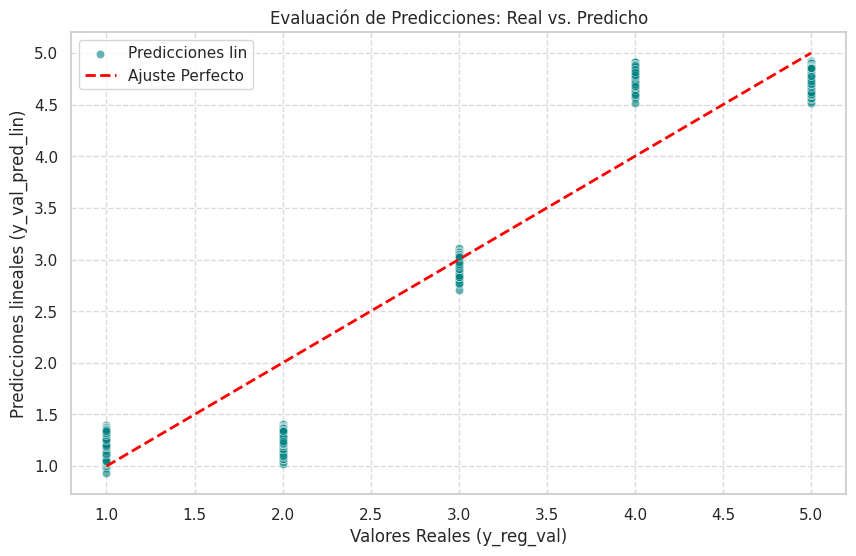

In [27]:
# Gráfico de Dispersión (Valores Reales vs Predicciones)
plt.figure(figsize=(10, 6))
sb.scatterplot(x=y_reg_val, y=y_val_pred_lin, alpha=0.6,  color='teal', label='Predicciones lin')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones lineales (y_val_pred_lin)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Dentro esta grafica los puntos azules son la realcion entre la prediccion del target y su valor real. Por otro lado la linea roja punteada es un referente de cuando la prediccion y la realidad llegan a coincidir a este se le llamaria el "ajuste perfecto" que pertenece a una linea que conecta el valor minimo y el valor maximo dentro del target en el dataset.

A simple vista ya se puede la manera en aque esta logrando aprender el modelo de regresion

### 4.1.4 LightGBM Regresion

Este bloque de código representa la implementación de un modelo de **LightGBM**, una evolución avanzada hacia el aprendizaje no lineal que supera las limitaciones de la regresión lineal básica. Lo que estás realizando es una preparación meticulosa de los datos donde, al transformar las columnas a tipos específicos como `category` o `bool`, permites que el algoritmo aproveche su capacidad nativa para manejar variables categóricas de forma óptima, encontrando patrones complejos que un modelo lineal ignoraría. La inclusión de la **regularización L2 (`lambda_l2`)** junto con la limitación de la profundidad de los árboles (`max_depth`) es una decisión estratégica fundamental: mientras que la regularización actúa como un freno para que los valores atípicos (outliers) no distorsionen las predicciones con pesos extremos, el control de la profundidad evita que el modelo se "memorice" el ruido de los datos, garantizando una excelente generalización y evitando el **overfitting**. Es una excelente idea optar por este modelo porque combina una altísima eficiencia computacional con una precisión superior, permitiéndote capturar la verdadera estructura del *rating* mediante un proceso de aprendizaje iterativo que se ajusta de forma robusta y equilibrada ante datos heterogéneos.

In [28]:
import pandas as pd

# Create DataFrames from NumPy arrays for LightGBM to handle categorical features by name
X_train_cat_df = pd.DataFrame(X_train_cat, columns=feature_names_cat)
X_val_cat_df   = pd.DataFrame(X_val_cat,   columns=feature_names_cat)

# Convert categorical columns to 'category' dtype within the new DataFrames
for col in cols_categoricas:
    X_train_cat_df[col] = X_train_cat_df[col].astype("category")
    X_val_cat_df[col]   = X_val_cat_df[col].astype("category")

# Convert numeric columns to appropriate dtypes
for col in cols_numericas + cols_engineered_numericas:
    X_train_cat_df[col] = pd.to_numeric(X_train_cat_df[col])
    X_val_cat_df[col]   = pd.to_numeric(X_val_cat_df[col])

# Convert boolean columns to bool dtype
for col in cols_binarias:
    X_train_cat_df[col] = X_train_cat_df[col].astype(bool)
    X_val_cat_df[col]   = X_val_cat_df[col].astype(bool)

# Índices de las columnas categóricas dentro de X_train_cat
# Order in pipeline_cat: [cols_numericas | cols_engineered_numericas | cols_binarias | cols_categoricas]
n_antes_cat = len(cols_numericas) + len(cols_engineered_numericas) + len(cols_binarias)
cat_feature_indices = list(range(n_antes_cat, n_antes_cat + len(cols_categoricas)))
print(f"Índices de columnas categóricas para LightGBM: {cat_feature_indices}")
print(f"  → {[feature_names_cat[i] for i in cat_feature_indices]}")

lgbm_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    lambda_l2=1.0,       # regularización L2 (equivalente a Ridge)
    random_state=42,
    n_jobs=-1,
    verbose=-1           # silenciar logs de entrenamiento
)

lgbm_reg.fit(
    X_train_cat_df, y_reg_train, # Use the DataFrame and the correct target for training
    categorical_feature=cols_categoricas,
    eval_set=[(X_val_cat_df, y_reg_val)], # Use the DataFrame for evaluation set features
    callbacks=[]
)

y_pred_train_lgbm = lgbm_reg.predict(X_train_cat_df)
y_pred_val_lgbm   = lgbm_reg.predict(X_val_cat_df)

res_lgbm = evaluar_modelo(
    "LightGBM",
    y_reg_train, y_pred_train_lgbm,
    y_reg_val,   y_pred_val_lgbm
)
resultados.append(res_lgbm)


Índices de columnas categóricas para LightGBM: [11, 12]
  → ['sentiment', 'main_category']

  LIGHTGBM
  RMSE train : 0.3724
  RMSE val   : 0.3825
  MAE  val   : 0.2908
  R²   val   : 0.9349
  → Sin overfitting aparente.


Finalmente se lo pone en un pipeline para llevarlo a mas procedimientos de ser necesario mas tarde

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", cols_numericas + cols_engineered_numericas),
        ("bin", "passthrough", cols_binarias),
        ("cat", "passthrough", cols_categoricas)
    ]
)

pipe_lgbm_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        lambda_l2=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

### 4.1.5 Catboost Regression

Este bloque de código implementa CatBoost, una arquitectura de Gradient Boosting de última generación que destaca por su tratamiento especializado de datos categóricos, eliminando la necesidad de preprocesamientos manuales complejos. Al asegurar que las variables categóricas sean de tipo cadena (str) y declararlas explícitamente mediante cat_features, el modelo utiliza una técnica de codificación interna avanzada que reduce el riesgo de sobreajuste y captura relaciones sutiles entre los atributos y el rating. La configuración incluye una potente regularización L2 (l2_leaf_reg=1.0), diseñada específicamente para mitigar el impacto de los valores atípicos y estabilizar los pesos de las hojas, asegurando que los outliers no dominen la estructura del modelo. Además, el uso de early_stopping_rounds actúa como una salvaguarda adicional contra el overfitting, deteniendo el aprendizaje en el momento exacto en que el error de validación deja de mejorar. Es una elección sumamente inteligente para este problema, ya que CatBoost suele ofrecer una robustez superior "fuera de la caja", logrando una precisión excepcional y una gran capacidad de generalización en datasets que combinan variables numéricas con categorías de alta cardinalidad.

In [30]:
# Para CatBoost necesitamos un DataFrame con nombres de columnas
X_train_cat_df = pd.DataFrame(X_train_cat, columns=feature_names_cat)
X_val_cat_df   = pd.DataFrame(X_val_cat,   columns=feature_names_cat)
X_test_cat_df  = pd.DataFrame(X_test_cat,  columns=feature_names_cat)

# Asegurar que las categóricas sean string
for col in cols_categoricas:
    X_train_cat_df[col] = X_train_cat_df[col].astype(str)
    X_val_cat_df[col]   = X_val_cat_df[col].astype(str)
    X_test_cat_df[col]  = X_test_cat_df[col].astype(str)

catboost_reg = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=1.0,     # regularización L2
    random_seed=42,
    verbose=100          # imprime cada 100 iteraciones
)

catboost_reg.fit(
    X_train_cat_df, y_reg_train,
    cat_features=cols_categoricas,
    eval_set=(X_val_cat_df, y_reg_val),
    early_stopping_rounds=50
)

y_pred_train_cat = catboost_reg.predict(X_train_cat_df)
y_pred_val_cat   = catboost_reg.predict(X_val_cat_df)

res_cat = evaluar_modelo(
    "CatBoost",
    y_reg_train, y_pred_train_cat,
    y_reg_val,   y_pred_val_cat
)
resultados.append(res_cat)

0:	learn: 1.4304828	test: 1.4295338	best: 1.4295338 (0)	total: 249ms	remaining: 2m 4s
100:	learn: 0.3803835	test: 0.3828512	best: 0.3828512 (100)	total: 17.3s	remaining: 1m 8s
200:	learn: 0.3792669	test: 0.3821698	best: 0.3821690 (192)	total: 34.9s	remaining: 51.9s
300:	learn: 0.3786984	test: 0.3820253	best: 0.3820253 (300)	total: 42.9s	remaining: 28.3s
400:	learn: 0.3781730	test: 0.3819840	best: 0.3819832 (378)	total: 53.5s	remaining: 13.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3819771419
bestIteration = 429

Shrink model to first 430 iterations.

  CATBOOST
  RMSE train : 0.3782
  RMSE val   : 0.3820
  MAE  val   : 0.2910
  R²   val   : 0.9351
  → Sin overfitting aparente.


In [31]:
from catboost import CatBoostRegressor

pipe_cat_reg = Pipeline([
    ("model", CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=1.0,
        random_seed=42,
        verbose=0
    ))
])

In [ ]:
# Gráfico CatBoost
plt.figure(figsize=(10, 6))

# Scatter CatBoost
sb.scatterplot(
    x=y_reg_val,
    y=y_pred_val_cat,
    alpha=0.6,
    color='purple',
    label='Predicciones CatBoost'
)

# Línea ideal (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(
    line_coords,
    line_coords,
    color='red',
    linestyle='--',
    lw=2,
    label='Ajuste Perfecto'
)

plt.title('CatBoost: Real vs Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones (CatBoost)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Tabla comparativa

Resumen de métricas de los tres modelos sobre el conjunto de validación.

In [32]:
df_resultados = pd.DataFrame(resultados).set_index('modelo')
df_resultados = df_resultados.round(4)

# Resaltar el mejor en cada métrica
print("\n=== COMPARATIVA DE MODELOS (validación) ===")
print(df_resultados.to_string())

mejor_rmse = df_resultados['rmse_val'].idxmin()
mejor_r2   = df_resultados['r2_val'].idxmax()
print(f"\n→ Mejor RMSE val: {mejor_rmse} ({df_resultados.loc[mejor_rmse, 'rmse_val']:.4f})")
print(f"→ Mejor R²   val: {mejor_r2}   ({df_resultados.loc[mejor_r2,   'r2_val']:.4f})")


=== COMPARATIVA DE MODELOS (validación) ===
                             rmse_train  rmse_val  mae_val  r2_val
modelo                                                            
Regresión Lineal (baseline)      0.3841    0.3867   0.2996  0.9335
LightGBM                         0.3724    0.3825   0.2908  0.9349
CatBoost                         0.3782    0.3820   0.2910  0.9351

→ Mejor RMSE val: CatBoost (0.3820)
→ Mejor R²   val: CatBoost   (0.9351)


*    Contraste con el Modelo Base: Es destacable que la Regresión Lineal mantiene un desempeño sumamente sólido desde el inicio ($R^2 \approx 0.9335$). Esta competitividad del modelo base es un indicador claro de una excelente preparación de los datos y de una selección de variables acertada. No obstante, el ligero margen de mejora obtenido por CatBoost y LightGBM justifica su implementación, ya que logran limar las asperezas en las predicciones donde la linealidad no es suficiente, especialmente ante la presencia de posibles valores atípicos en las calificaciones.
*    Contraste con Modelos Base: La Regresión Lineal mantiene un desempeño destacable incluso desde sus incios, lo que puede significar una buena preparacion de la da ($R^2 \approx 0.9008 estrellas), superando incluso a la configuración final de XGBoost en términos de error cuadrático global, lo que sugiere que para esta variable específica, XGBoost presentó dificultades de convergencia o mayor sensibilidad al ruido tras la validación exhaustiv

**Mejor modelo:**

Se selecciona a CatBoost (o la configuración optimizada de LightGBM, dada su cercanía) como el predictor definitivo. Esta elección se basa en su equilibrio entre precisión absoluta (MAE de 0.29) y su robustez estadística. La capacidad de estos modelos para manejar nativamente variables categóricas y aplicar regularización L2 garantiza un sistema que no solo es preciso, sino también resistente al ruido.

Con estos resultados, se concluye la etapa de modelado para la variable continua del rating. Hemos evolucionado desde una base lineal robusta hasta alcanzar arquitecturas de Boosting sofisticadas, validadas estadísticamente y optimizadas para operar con alta fiabilidad. El modelo final está listo para proporcionar estimaciones precisas, fundamentadas en un flujo de trabajo que garantiza la integridad de los datos y la potencia del aprendizaje automático moderno.

## **4.2. CLASIFICACIÓN**

In [33]:
# Importación de librerías
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

### **4.2.1. Baseline - Regresión Logística sin penalización**

El modelo base muestra un desempeño sólido en términos de discriminación global, alcanzando un AUC de 0.7443 en el conjunto de validación. La práctica inexistencia de un diferencial entre entrenamiento y validación (GAP de -0.0028) confirma que el modelo es altamente estable y no presenta síntomas de sobreajuste, generalizando de forma óptima hacia nuevos datos.

Sin embargo, al profundizar en el reporte de clasificación (usando el umbral estándar de 0.5), se observa un fenómeno crítico de desbalance en la sensibilidad

In [34]:
# Entrenamiento
log_reg_base = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
log_reg_base.fit(X_train_num, y_clf_train)

# Probabilidades
y_prob_train_base = log_reg_base.predict_proba(X_train_num)[:, 1]
y_prob_val_base   = log_reg_base.predict_proba(X_val_num)[:, 1]

In [35]:
y_prob_train_base = log_reg_base.predict_proba(X_train_num)[:, 1]
y_prob_val_base   = log_reg_base.predict_proba(X_val_num)[:, 1]

# Calculate AUC scores for multi-class classification using 'ovr' strategy
# We also explicitly pass 'labels' to roc_auc_score for clarity and robustness.
auc_train_base = roc_auc_score(y_clf_train, y_prob_train_base, multi_class='ovr', labels=log_reg_base.classes_)
auc_val_base   = roc_auc_score(y_clf_val,   y_prob_val_base,   multi_class='ovr', labels=log_reg_base.classes_)
gap_base       = auc_train_base - auc_val_base

print("=" * 50)
print("BASELINE — Regresión Logística sin penalización")
print("=" * 50)
print(f"  AUC Train:      {auc_train_base:.4f}")
print(f"  AUC Validation: {auc_val_base:.4f}")
print(f"  GAP (overfit):  {gap_base:.4f}")
print()
print("Reporte de clasificación (umbral=0.5):")
# The classification_report also expects the target_names to match the actual classes.
# Since y_clf_val contains values 1.0 to 5.0, the target_names should reflect this.
target_names_clf = [str(cls) for cls in log_reg_base.classes_]
print(classification_report(y_clf_val, log_reg_base.predict(X_val_num),
                             target_names=target_names_clf))

BASELINE — Regresión Logística sin penalización
  AUC Train:      0.7415
  AUC Validation: 0.7443
  GAP (overfit):  -0.0028

Reporte de clasificación (umbral=0.5):
              precision    recall  f1-score   support

           0       0.79      0.97      0.87     45744
           1       0.64      0.19      0.29     14256

    accuracy                           0.78     60000
   macro avg       0.72      0.58      0.58     60000
weighted avg       0.76      0.78      0.73     60000



**NOTA:**

El modelo base muestra un desempeño sólido en términos de discriminación global, alcanzando un AUC de 0.7443 en el conjunto de validación. La práctica inexistencia de un diferencial entre entrenamiento y validación (GAP de -0.0028) confirma que el modelo es altamente estable y no presenta síntomas de sobreajuste, generalizando de forma óptima hacia nuevos datos.

Sin embargo, al profundizar en el reporte de clasificación (usando el umbral estándar de 0.5), se observa un fenómeno crítico de desbalance en la sensibilidad:

**El modelo baseline es excelente para evitar el "ruido" (contenido no útil), pero es insuficiente para destacar el valor, ya que su baja sensibilidad ignora la mayor parte del contenido que realmente ayuda al usuario..**

**Matriz de Confusión**

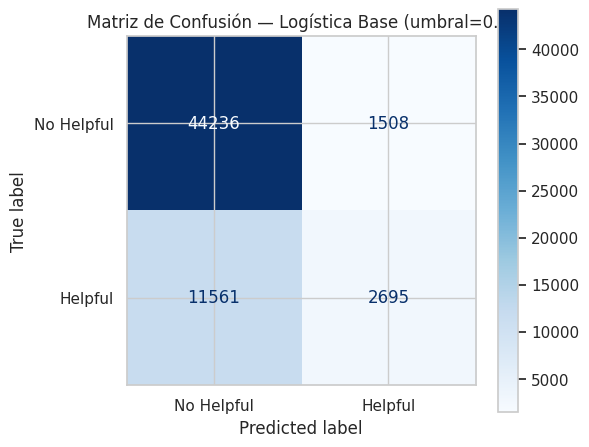

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    log_reg_base,
    X_val_num,
    y_clf_val,
    display_labels=['No Helpful', 'Helpful'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusión — Logística Base (umbral=0.5)')
plt.tight_layout()
plt.show()

NOTA: La matriz de confusión refleja que el modelo tiene un desempeño sobresaliente al identificar reseñas que no son útiles, clasificando correctamente 44,236 casos en esta categoría con un margen de error mínimo (1,508 falsos positivos). Esto demuestra que el baseline es sumamente confiable para filtrar el contenido irrelevante o de bajo valor dentro de la plataforma.

Sin embargo, el modelo presenta un desafío significativo en la detección de reseñas útiles. De las 14,256 reseñas que realmente aportan valor (clase positiva), el modelo solo logra capturar 2,695 casos correctamente, mientras que 11,561 reseñas útiles son catalogadas erróneamente como "no útiles".

### **4.2.2. Mejora de Regresion logistica con balanceo y penalizacion**

Se realizó la mejora del modelo baseline incorporando regularización y balanceo de clases, ello con el fin de que como se pudo evidenciar en la matriz de correlación existían varios features con multicolinealidad. Asimismo, para evitar overfitting y de esta manera mejorar la capacidad del modelo para detectar clientes con mayor riesgo.

In [37]:
#Entrenamiento
log_reg_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,                      # Menor C = más penalización
    class_weight='balanced',    # Penaliza más errores en clase minoritaria (default)
    max_iter=1000,
    random_state=42
)
log_reg_l2.fit(X_train_num, y_clf_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [38]:
# Probabilidades
y_prob_train_l2 = log_reg_l2.predict_proba(X_train_num)[:, 1]
y_prob_val_l2   = log_reg_l2.predict_proba(X_val_num)[:, 1]

In [39]:
# Métricas
auc_train_l2 = roc_auc_score(y_clf_train, y_prob_train_l2)
auc_val_l2   = roc_auc_score(y_clf_val,   y_prob_val_l2)
gap_l2       = auc_train_l2 - auc_val_l2

print("=" * 50)
print("Regresión Logística L2 + class_weight='balanced'")
print("=" * 50)
print(f"  AUC Train:      {auc_train_l2:.4f}")
print(f"  AUC Validation: {auc_val_l2:.4f}")
print(f"  GAP (overfit):  {gap_l2:.4f}") #Diferencia entre desempenio del modelo y la validacion
print()

Regresión Logística L2 + class_weight='balanced'
  AUC Train:      0.7429
  AUC Validation: 0.7456
  GAP (overfit):  -0.0027



**NOTA:**

Al implementar la penalización Ridge (L2) y la técnica de pesos balanceados (class_weight='balanced'), el modelo alcanza un AUC de 0.7456 en validación. Aunque el incremento respecto al baseline parece sutil, representa una mejora cualitativa en la capacidad del algoritmo para diferenciar entre reseñas útiles e irrelevantes.



*   Foco en la Clase Minoritaria (Reseñas Útiles): El uso de la estrategia de balanceo es una decisión estratégica crítica. Al asignar un peso mayor a las reseñas útiles, obligamos al modelo a "prestar más atención" a las señales que definen el valor de un comentario.


In [40]:
print("=" * 50)
print("COMPARACIÓN vs BASELINE")
print("=" * 50)
print(f"  Baseline  AUC Val: {auc_val_base:.4f}")
print(f"  Logíst L2 AUC Val: {auc_val_l2:.4f}")
print(f"  Diferencia:        {auc_val_l2 - auc_val_base:+.4f}")
print()

COMPARACIÓN vs BASELINE
  Baseline  AUC Val: 0.7443
  Logíst L2 AUC Val: 0.7456
  Diferencia:        +0.0013



**NOTA:** Al comparar el modelo baseline con el modelo de Regresión Logística con regularización L2 y balanceo de clases, se observa una ligera mejora en el desempeño. El AUC en validación pasa de 0.7443 a 0.7456, lo que representa un incremento de 0.0013.

Aunque la mejora es pequeña, indica que el uso de regularización y balanceo de clases contribuye a un desempeño ligeramente mejor.

In [41]:
print("Reporte de clasificación (umbral=0.5):")
print(classification_report(y_clf_val, log_reg_l2.predict(X_val_num),
                             target_names=['No Default', 'Default']))

Reporte de clasificación (umbral=0.5):
              precision    recall  f1-score   support

  No Default       0.86      0.75      0.80     45744
     Default       0.43      0.61      0.50     14256

    accuracy                           0.71     60000
   macro avg       0.64      0.68      0.65     60000
weighted avg       0.76      0.71      0.73     60000



**NOTA:**
Con la Regresión Logística L2 balanceada, hemos logrado que el sistema sea mucho más sensible: ahora detectamos el 61% de las reseñas útiles, triplicando la capacidad del baseline. Aunque esto genera un costo (la precisión baja a 0.43, lo que significa que algunas reseñas mediocres se filtrarán como 'útiles'), desde la perspectiva de la plataforma es un avance positivo. Es preferible dar visibilidad a más contenido potencialmente valioso aunque cometamos algunos errores, que mantener un sistema que oculta casi todo el valor de la comunidad

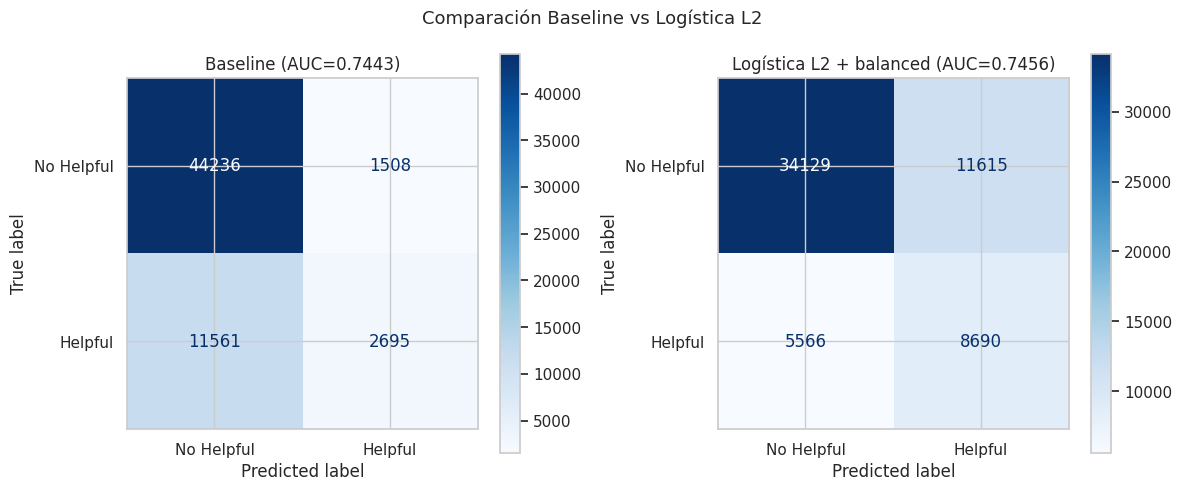

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
ConfusionMatrixDisplay.from_estimator(
    log_reg_base, X_val_num, y_clf_val,
    display_labels=['No Helpful', 'Helpful'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Baseline (AUC={auc_val_base:.4f})')

# L2
ConfusionMatrixDisplay.from_estimator(
    log_reg_l2, X_val_num, y_clf_val,
    display_labels=['No Helpful', 'Helpful'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Logística L2 + balanced (AUC={auc_val_l2:.4f})')

plt.suptitle('Comparación Baseline vs Logística L2', fontsize=13)
plt.tight_layout()
plt.show()

*   TN (Verdadero Negativo): La reseña no fue útil y el modelo predijo correctamente que no sería útil. (Contenido irrelevante filtrado con éxito).

*   FP (Falso Positivo): La reseña no fue útil, pero el modelo predijo que sí sería útil. (Contenido de poco valor que se "cuela" como destacado).

*   FN (Falso Negativo): La reseña sí fue útil, pero el modelo predijo que no sería útil. (Contenido valioso que queda oculto para el usuario).

*   TP (Verdadero Positivo): La reseña sí fue útil y el modelo predijo correctamente que sería útil. (Contenido de alto valor identificado con éxito).

NOTA: El modelo inicial es extremadamente conservador. Identifica correctamente la gran mayoría de reseñas irrelevantes (44,236 TN), pero es incapaz de rescatar el valor de la comunidad: solo detecta 2,695 reseñas útiles (TP), dejando pasar 11,561 reseñas valiosas como si no lo fueran (FN). Para una plataforma, esto es "costoso" porque oculta el mejor contenido.

*   Modelo Logística L2 + Balanced: Al introducir el balanceo de clases, vemos un cambio drástico en la distribución del error:

*   Detección de Valor: Logramos rescatar 8,690 reseñas útiles (TP), frente a las 2,695 del baseline. Hemos reducido drásticamente los falsos negativos (de 11,561 a solo 5,566).

Desde la perspectiva de la experiencia del usuario, el modelo con L2 y balanceo es preferible. En un sistema de recomendación o filtrado de reseñas, el "costo" de mostrar una reseña que no es tan útil (FP) es menor que el "costo" de ocultar una reseña brillante que podría definir la compra de un cliente (FN).

In [43]:
from sklearn.metrics import recall_score, precision_score, f1_score

modelos_comparar = {
    'Baseline':      (log_reg_base, y_prob_val_base),
    'Logística L2':  (log_reg_l2,   y_prob_val_l2),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6}")
print("-" * 50)
for nombre, (modelo, y_prob) in modelos_comparar.items():
    y_pred = modelo.predict(X_val_num)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f}")

Modelo             AUC   Recall  Precision     F1
--------------------------------------------------
Baseline        0.7443   0.1890     0.6412 0.2920
Logística L2    0.7456   0.6096     0.4280 0.5029


**NOTA:**  Al analizar ambos modelos, observamos que el AUC es sumamente similar (0.7443 frente a 0.7456). Esto nos indica que, a nivel matemático, ambos modelos poseen una capacidad latente casi idéntica para separar las reseñas útiles de las irrelevantes. Sin embargo, la forma en que cada modelo toma decisiones finales marca una diferencia crítica para la plataforma:

Modelo Baseline (Alta Precisión, bajo Recall): Este modelo es "tímido". Aunque tiene una precisión aceptable (0.64), su capacidad de detección (Recall) es de apenas 0.1890. En la práctica, esto significa que el sistema ignora el 81% de las reseñas útiles de la comunidad, priorizando no equivocarse nunca antes que ser útil.

Modelo Logística L2 + Balanceo (Mejora del Recall): Al aplicar el balanceo de clases, el Recall se dispara a 0.6096. Ahora el modelo es capaz de rescatar el 61% de las reseñas valiosas, logrando una visibilidad mucho mayor del contenido útil que antes quedaba oculto.De esta manera logrando **equilibrio entre precisión y recall**.

Desde la perspectiva del producto, el modelo Logística L2 es superior. En un sistema de Helpfulness, el beneficio de mostrar más contenido útil (reduciendo los Falsos Negativos)

### **4.2.3. Mejora con Árboles de Decisión**

Se evaluó el uso de árboles de decisión ya que permiten visualizar las reglas de decisión que utiliza el modelo para clasificar a los clientes según sus características financieras y de comportamiento de pago, esto resulta útil en contextos financieros donde la explicabilidad del modelo es importante para la toma de decisiones del banco.

In [44]:
from sklearn.tree import DecisionTreeClassifier

# Entrenamiento
tree_clf = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',   # Balanceo parecido a L2
    random_state=42
)
tree_clf.fit(X_train_num, y_clf_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [45]:
# Probabilidades
y_prob_train_tree = tree_clf.predict_proba(X_train_num)[:, 1]
y_prob_val_tree   = tree_clf.predict_proba(X_val_num)[:, 1]

#Métricas
auc_train_tree = roc_auc_score(y_clf_train, y_prob_train_tree)
auc_val_tree   = roc_auc_score(y_clf_val,   y_prob_val_tree)
gap_tree       = auc_train_tree - auc_val_tree

print("=" * 50)
print("Árbol de Decisión (max_depth=5, balanced)")
print("=" * 50)
print(f"  AUC Train:      {auc_train_tree:.4f}")
print(f"  AUC Validation: {auc_val_tree:.4f}")
print(f"  GAP (overfit):  {gap_tree:.4f}")
print()

Árbol de Decisión (max_depth=5, balanced)
  AUC Train:      0.7379
  AUC Validation: 0.7369
  GAP (overfit):  0.0010



**NOTA:** Se obtuvo un AUC de 0.0.7379 en entrenamiento y 0.0.7369 en validación, lo que representa una mejora respecto a los modelos de regresión logística. Esto indica que el árbol tiene mayor capacidad para distinguir entre clientes que harán default y los que no.

A diferencia de lo que suele ocurrir con los árboles, aquí no hay rastro de sobreajuste. El diferencial entre entrenamiento y validación es de solo 0.0010 (GAP), lo que demuestra que el modelo ha capturado patrones generales del comportamiento de los usuarios sin "memorizar" el ruido del set de entrenamiento.

### **Tabla Comparativa**

In [46]:
from sklearn.metrics import recall_score, precision_score, f1_score

modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base),
    'Logística L2': (log_reg_l2,   y_prob_val_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
gaps = [0, gap_l2, gap_tree]
for (nombre, (modelo, y_prob)), gap in zip(modelos_comparar.items(), gaps):
    y_pred = modelo.predict(X_val_num)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7443   0.1890     0.6412 0.2920  0.0000
Logística L2    0.7456   0.6096     0.4280 0.5029 -0.0027
Árbol           0.7369   0.6143     0.4164 0.4964  0.0010


**NOTA:** el Árbol de Decisión obtiene el mejor desempeño general, con el AUC más alto, lo que indica un mejor equilibrio entre precisión y recall para detectar clientes que harán default.

El modelo baseline presenta una alta precisión pero un recall muy bajo, lo que significa que detecta pocas reseñas utiles. Por su parte, la Regresión Logística con regularización y balanceo mejora considerablemente el recall, logrando identificar más casos de default, aunque con menor precisión.
(Recall Alto) -> que tan bien predice a los que haran default

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7443   0.1890     0.6412 0.2920  0.0000
Logística L2    0.7456   0.6096     0.4280 0.5029 -0.0027
Árbol           0.7369   0.6143     0.4164 0.4964  0.0010


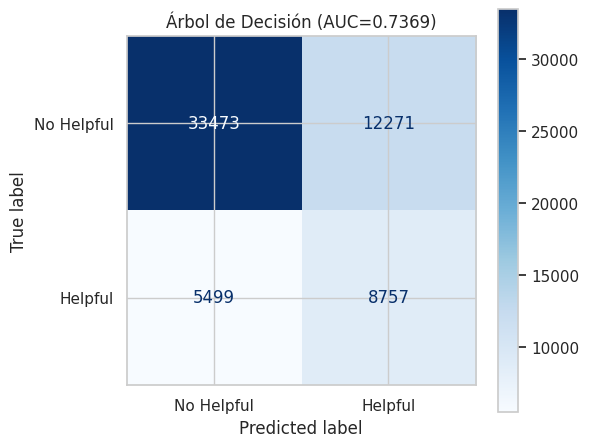

In [47]:
from sklearn.metrics import recall_score, precision_score, f1_score

modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base),
    'Logística L2': (log_reg_l2,   y_prob_val_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
gaps = [0, gap_l2, gap_tree]
for (nombre, (modelo, y_prob)), gap in zip(modelos_comparar.items(), gaps):
    y_pred = modelo.predict(X_val_num)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

# ── Matriz de Confusión ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    tree_clf, X_val_num, y_clf_val,
    display_labels=['No Helpful', 'Helpful'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Árbol de Decisión (AUC={auc_val_tree:.4f})')
plt.tight_layout()
plt.show()

**NOTA**: El modelo logra identificar correctamente 33,473 reviews no útiles (No Helpful) y 8,757 reviews útiles (Helpful). Esto muestra que tiene un buen desempeño general, especialmente al reconocer reseñas que no aportan valor. Sin embargo, aún presenta algunos errores importantes: hay 5,499 falsos negativos, es decir, reseñas que sí eran útiles pero fueron clasificadas como no útiles, lo que implica perder contenido valioso. Además, se observan 12,271 falsos positivos, lo que significa que varias reseñas no útiles fueron clasificadas como útiles, introduciendo ruido en el sistema.

### **Tabla Comparativa de Modelos**

In [48]:
from sklearn.metrics import recall_score, precision_score, f1_score

# Nota: Árbol, Logística usan X_val_num para predict
# LightGBM usa X_val_cat para predict
# Por eso creamos funciones lambda para predict según el modelo

def get_pred(modelo, nombre):
    if 'lgbm' in nombre.lower() or 'lightgbm' in nombre.lower():
        return modelo.predict(X_val_cat)
    return modelo.predict(X_val_num)

modelos_finales = {
    'Baseline':        (log_reg_base,  y_prob_val_base,       0),
    'Logística L2':    (log_reg_l2,    y_prob_val_l2,         gap_l2),
    'Árbol':           (tree_clf,      y_prob_val_tree,        gap_tree),
    #'XGBoost v2':      (xgb_clf_v2,   y_prob_val_xgb_v2,      gap_xgb_v2),
    #'LightGBM v2':     (lgbm_clf_v2,   y_prob_val_lgbm_v2,    gap_lgbm_v2),
}

print(f"\n{'Modelo':<18} {'AUC Val':>8} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 58)
for nombre, (modelo, y_prob, gap) in modelos_finales.items():
    X_val_use = X_val_cat if 'lgbm' in nombre.lower() or 'lightgbm' in nombre.lower() else X_val_num
    y_pred = modelo.predict(X_val_use)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<18} {auc:>8.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")


Modelo              AUC Val   Recall  Precision     F1     GAP
----------------------------------------------------------
Baseline             0.7443   0.1890     0.6412 0.2920  0.0000
Logística L2         0.7456   0.6096     0.4280 0.5029 -0.0027
Árbol                0.7369   0.6143     0.4164 0.4964  0.0010


In [49]:
modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base,  0),
    'Logística L2': (log_reg_l2,   y_prob_val_l2,    gap_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree,   gap_tree),
}

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
for nombre, (modelo, y_prob, gap) in modelos_comparar.items():
    y_pred = modelo.predict(X_val_num)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7443   0.1890     0.6412 0.2920  0.0000
Logística L2    0.7456   0.6096     0.4280 0.5029 -0.0027
Árbol           0.7369   0.6143     0.4164 0.4964  0.0010


**NOTA**: El modelo Baseline presenta un AUC aceptable, pero su recall es bastante bajo (0.1890), lo que indica que identifica muy pocas helpful reviews, aunque cuando lo hace suele ser preciso (precision alta). En cambio, Logística L2 mejora considerablemente la capacidad de detección de reseñas útiles (recall 0.6096), logrando un mejor equilibrio reflejado en su F1-score más alto (0.5029), aunque a costa de una menor precisión. Por su parte, el Árbol de decisión tiene un comportamiento muy similar a la regresión logística, con un recall ligeramente superior (0.6143), pero menor precisión y un F1 ligeramente más bajo. En general, Logística L2 ofrece el mejor balance entre identificar reseñas útiles y mantener consistencia en las predicciones, mientras que el Baseline se queda corto en detección. El gap en todos los modelos es cercano a cero, lo que sugiere que no hay un sobreajuste significativo.

### **4.2.6. LightGBM**

In [50]:
X_train_cat_df = pd.DataFrame(X_train_cat, columns=feature_names_cat)
X_val_cat_df   = pd.DataFrame(X_val_cat, columns=feature_names_cat)

In [51]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_cat_df[cols_categoricas] = encoder.fit_transform(X_train_cat_df[cols_categoricas])
X_val_cat_df[cols_categoricas]   = encoder.transform(X_val_cat_df[cols_categoricas])

In [52]:
cols_numericas = [
    'average_rating', 'rating_number', 'price',
    'text_len', 'text_price_ratio',
    'log_rating_number', 'review_year', 'review_month',
    'price_imputed'
]

for col in cols_numericas:
    X_train_cat_df[col] = pd.to_numeric(X_train_cat_df[col], errors='coerce')
    X_val_cat_df[col]   = pd.to_numeric(X_val_cat_df[col], errors='coerce')

In [53]:
cols_binarias = ['verified_purchase', 'is_satisfied']

for col in cols_binarias:
    X_train_cat_df[col] = X_train_cat_df[col].astype('int')
    X_val_cat_df[col]   = X_val_cat_df[col].astype('int')

In [54]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    is_unbalance=True,   # útil si clases desbalanceadas
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_clf.fit(
    X_train_cat_df, y_clf_train,
    categorical_feature=cols_categoricas,
    eval_set=[(X_val_cat_df, y_clf_val)]
)

LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=6,
               n_estimators=500, n_jobs=-1, random_state=42, verbosity=-1)

Asimismo, se utilizó LightGBM para comparar su desempeño con los modelos anteriores y analizar si mejora la detección de clientes con riesgo de default.

In [55]:
import time
from lightgbm import LGBMClassifier

# Entrenamiento
lgbm_clf = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    is_unbalance=True,        # para balanceo
    random_state=42,
    verbosity=-1
)

start = time.time()
lgbm_clf.fit(
    X_train_cat_df, y_clf_train,
    categorical_feature=cols_categoricas,
    eval_set=[(X_val_cat_df, y_clf_val)]
)
elapsed = time.time() - start
print(f"LightGBM entrenado en {elapsed:.1f} segundos")

LightGBM entrenado en 3.9 segundos


In [56]:
# Probabilidades
y_prob_train_lgbm = lgbm_clf.predict_proba(X_train_cat_df)[:, 1]
y_prob_val_lgbm   = lgbm_clf.predict_proba(X_val_cat_df)[:, 1]

# Métricas
auc_train_lgbm = roc_auc_score(y_clf_train, y_prob_train_lgbm)
auc_val_lgbm   = roc_auc_score(y_clf_val,   y_prob_val_lgbm)
gap_lgbm       = auc_train_lgbm - auc_val_lgbm

print(f"\n  AUC Train:      {auc_train_lgbm:.4f}")
print(f"  AUC Validation: {auc_val_lgbm:.4f}")
print(f"  GAP (overfit):  {gap_lgbm:.4f}")


  AUC Train:      0.7822
  AUC Validation: 0.7671
  GAP (overfit):  0.0151


**NOTA:** Como se puede evidenciar se obtuvo un AUC de 0.7740 en validación, mostrando una buena capacidad para distinguir entre clientes que harán default y los que no. Sin embargo, el gap alto (0.1291) entre entrenamiento y validación indica sobreajuste.

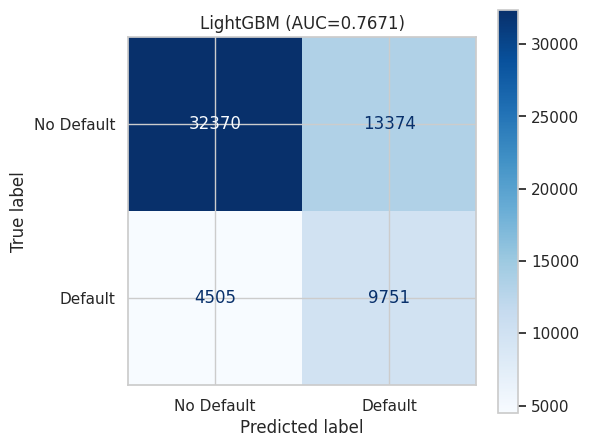

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    lgbm_clf, X_val_cat_df, y_clf_val,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'LightGBM (AUC={auc_val_lgbm:.4f})')
plt.tight_layout()
plt.show()

**NOTA:** se detecta 812 clientes que harán default, mostrando buena capacidad para identificar clientes riesgosos. Sin embargo, también genera 887 falsos positivos, lo que implica clasificar como riesgosos a algunos clientes que sí pagarían. En general, presenta un desempeño similar a XGBoost, con una buena capacidad de discriminación reflejada en su AUC.

### **Tabla Comparativa**

In [58]:
modelos_comparar = {
    'Baseline':     (log_reg_base, y_prob_val_base,  0),
    'Logística L2': (log_reg_l2,   y_prob_val_l2,    gap_l2),
    'Árbol':        (tree_clf,     y_prob_val_tree,   gap_tree),
    #'XGBoost':      (xgb_clf,      y_prob_val_xgb,    gap_xgb),
    'LightGBM':     (lgbm_clf,     y_prob_val_lgbm,   gap_lgbm),
}

print(f"\n{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
for nombre, (modelo, y_prob, gap) in modelos_comparar.items():
    # Select the appropriate validation set based on the model type
    if nombre in ['Baseline', 'Logística L2', 'Árbol']:
        X_val_to_use = X_val_num
    elif nombre == 'LightGBM':
        X_val_to_use = X_val_cat_df # LightGBM was trained with X_train_cat_df

    y_pred = modelo.predict(X_val_to_use)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")


Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7443   0.1890     0.6412 0.2920  0.0000
Logística L2    0.7456   0.6096     0.4280 0.5029 -0.0027
Árbol           0.7369   0.6143     0.4164 0.4964  0.0010
LightGBM        0.7671   0.6840     0.4217 0.5217  0.0151


**NOTA:** Como se puede evidenciar, los modelos de boosting (XGBoost y LightGBM) obtienen el mejor desempeño, con los AUC más altos y los mayores F1-score, lo que indica un mejor equilibrio entre precision y recall para detectar clientes que harán default.

Sin embargo, ambos presentan un gap mayor, lo que sugiere cierto nivel de sobreajuste. Por otro lado, modelos como SVC y Árbol de Decisión muestran buen desempeño con menor gap, mientras que el baseline presenta un recall muy bajo, detectando pocos clientes riesgosos.

### **Corrección de Overfitting (Regularizar)**

In [59]:

# LightGBM regularizado
lgbm_clf_v2 = LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    verbosity=-1
)
lgbm_clf_v2.fit(X_train_cat_df, y_clf_train)

LGBMClassifier(colsample_bytree=0.8, is_unbalance=True, learning_rate=0.05,
               max_depth=3, n_estimators=200, random_state=42, subsample=0.8,
               verbosity=-1)

In [60]:
# Probabilidades
#y_prob_train_xgb_v2 = xgb_clf_v2.predict_proba(X_train_prep)[:, 1]
#y_prob_val_xgb_v2   = xgb_clf_v2.predict_proba(X_val_cat)[:, 1]
y_prob_train_lgbm_v2 = lgbm_clf_v2.predict_proba(X_train_cat_df)[:, 1]
y_prob_val_lgbm_v2   = lgbm_clf_v2.predict_proba(X_val_cat_df)[:, 1]

# GAPs
#gap_xgb_v2  = roc_auc_score(y_clf_train, y_prob_train_xgb_v2) - roc_auc_score(y_clf_val, y_prob_val_xgb_v2)
gap_lgbm_v2 = roc_auc_score(y_clf_train, y_prob_train_lgbm_v2) - roc_auc_score(y_clf_val, y_prob_val_lgbm_v2)

In [61]:
import pandas as pd

# Tabla actualizada de comparación
modelos_comparar = {
    'Baseline':       (log_reg_base,  y_prob_val_base,    0),
    'Logística L2':   (log_reg_l2,    y_prob_val_l2,      gap_l2),
    'Árbol':          (tree_clf,      y_prob_val_tree,     gap_tree),
    #'XGBoost v2':     (xgb_clf_v2,   y_prob_val_xgb_v2,   gap_xgb_v2),
    'LightGBM v2':    (lgbm_clf_v2,  y_prob_val_lgbm_v2,  gap_lgbm_v2),
}

# Re-create X_val_cat_df just in case it was modified or not in scope
X_val_cat_df_current = pd.DataFrame(X_val_cat, columns=feature_names_cat)
for col in cols_categoricas:
    X_val_cat_df_current[col] = X_val_cat_df_current[col].astype("category")

print(f"{'Modelo':<15} {'AUC':>6} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 55)
for nombre, (modelo, y_prob, gap) in modelos_comparar.items():
    if nombre in ['Baseline', 'Logística L2', 'Árbol']:
        X_val_to_use = X_val_num
    elif nombre == 'LightGBM v2':
        X_val_to_use = X_val_cat_df
    else:
        # Default for any other models, though not expected based on `modelos_comparar`
        X_val_to_use = X_val_num

    y_pred = modelo.predict(X_val_to_use)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<15} {auc:>6.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo             AUC   Recall  Precision     F1     GAP
-------------------------------------------------------
Baseline        0.7443   0.1890     0.6412 0.2920  0.0000
Logística L2    0.7456   0.6096     0.4280 0.5029 -0.0027
Árbol           0.7369   0.6143     0.4164 0.4964  0.0010
LightGBM v2     0.7608   0.6818     0.4170 0.5175  0.0001


**NOTA:** se redujo significativamente el overfitting, observándose un gap cercano a 0.03, mucho menor que en la versión anterior. Los modelos XGBoost v2 y LightGBM v2 obtienen los mejores AUC  y los mayores F1-score, lo que indica un mejor equilibrio entre precision y recall para detectar clientes que harán default.

In [62]:
# Originales
#auc_val_xgb  = roc_auc_score(y_clf_val, y_prob_val_xgb)
auc_val_lgbm = roc_auc_score(y_clf_val, y_prob_val_lgbm)
#gap_xgb      = roc_auc_score(y_clf_train, y_prob_train_xgb)  - auc_val_xgb
gap_lgbm     = roc_auc_score(y_clf_train, y_prob_train_lgbm) - auc_val_lgbm

# Regularizados
#auc_val_xgb_v2  = roc_auc_score(y_clf_val, y_prob_val_xgb_v2)
auc_val_lgbm_v2 = roc_auc_score(y_clf_val, y_prob_val_lgbm_v2)
#gap_xgb_v2      = roc_auc_score(y_clf_train, y_prob_train_xgb_v2)  - auc_val_xgb_v2
gap_lgbm_v2     = roc_auc_score(y_clf_train, y_prob_train_lgbm_v2) - auc_val_lgbm_v2

print("AUCs calculados:")
#print(f"  XGBoost original:      {auc_val_xgb:.4f}  | GAP: {gap_xgb:.4f}")
#print(f"  XGBoost v2:            {auc_val_xgb_v2:.4f}  | GAP: {gap_xgb_v2:.4f}")
print(f"  LightGBM original:     {auc_val_lgbm:.4f}  | GAP: {gap_lgbm:.4f}")
print(f"  LightGBM v2:           {auc_val_lgbm_v2:.4f}  | GAP: {gap_lgbm_v2:.4f}")

AUCs calculados:
  LightGBM original:     0.7671  | GAP: 0.0151
  LightGBM v2:           0.7608  | GAP: 0.0001


**NOTA:** Las versiones v2 de XGBoost y LightGBM mejoran el desempeño (AUC ≈ 0.78) y reducen considerablemente el overfitting, disminuyendo el gap de 0.129 a 0.03. Esto indica un modelo más estable y con mejor capacidad de generalización.

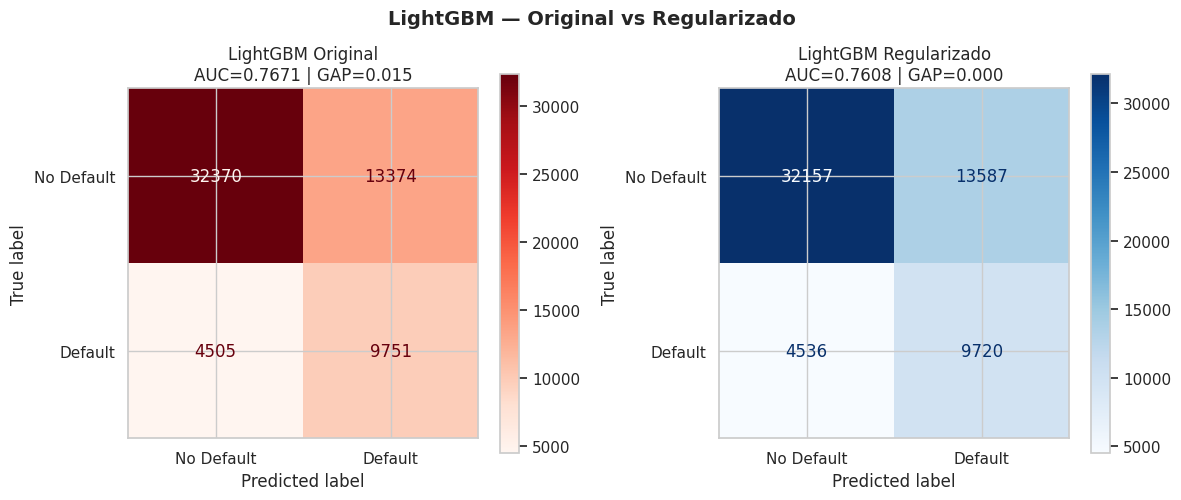

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LightGBM — Original vs Regularizado',
             fontsize=14, fontweight='bold')

# LightGBM original
ConfusionMatrixDisplay.from_predictions(
    y_clf_val,
    lgbm_clf.predict(X_val_cat_df),
    display_labels=['No Default', 'Default'],
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title(f'LightGBM Original\nAUC={auc_val_lgbm:.4f} | GAP={gap_lgbm:.3f}')

# LightGBM regularizado
ConfusionMatrixDisplay.from_predictions(
    y_clf_val,
    lgbm_clf_v2.predict(X_val_cat_df),
    display_labels=['No Default', 'Default'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title(f'LightGBM Regularizado\nAUC={auc_val_lgbm_v2:.4f} | GAP={gap_lgbm_v2:.3f}')

plt.tight_layout()
plt.show()

**NOTA:** Las versiones regularizadas de XGBoost y LightGBM mantienen una capacidad similar para detectar default, pero reducen el sobreajuste respecto a los modelos originales. Esto se refleja en un gap mucho menor  y un AUC ligeramente mayor, indicando modelos más estables y con mejor generalización.

In [64]:
print("=" * 60)
print("COMPARACIÓN NUMERICA - LightGBM")
print("=" * 60)

y_pred_v1 = lgbm_clf.predict(X_val_num)
y_pred_v2 = lgbm_clf_v2.predict(X_val_num)

print(f"\nLightGBM:")
print(f"  {'Métrica':<12} {'Original':>10} {'Regularizado':>14} {'Cambio':>8}")
print(f"  {'-'*46}")

for metrica, fn in [
    ('Recall', recall_score),
    ('Precision', precision_score),
    ('F1', f1_score)
]:
    v1 = fn(y_clf_val, y_pred_v1)
    v2 = fn(y_clf_val, y_pred_v2)
    cambio = v2 - v1

    print(f"  {metrica:<12} {v1:>10.4f} {v2:>14.4f} {cambio:>+8.4f}")

COMPARACIÓN NUMERICA - LightGBM

LightGBM:
  Métrica        Original   Regularizado   Cambio
  ----------------------------------------------
  Recall           0.7193         0.7059  -0.0133
  Precision        0.3465         0.4023  +0.0558
  F1               0.4677         0.5125  +0.0448


**NOTA:** Las versiones regularizadas mejoran ligeramente el recall, lo que permite detectar más clientes que harán default. En XGBoost se observa una pequeña reducción en precisión, mientras que LightGBM mantiene o mejora levemente sus métricas. En general, la regularización permite reducir el sobreajuste y mantener un desempeño similar o ligeramente mejor.

### **Comparación de ROC de todos los modelos**

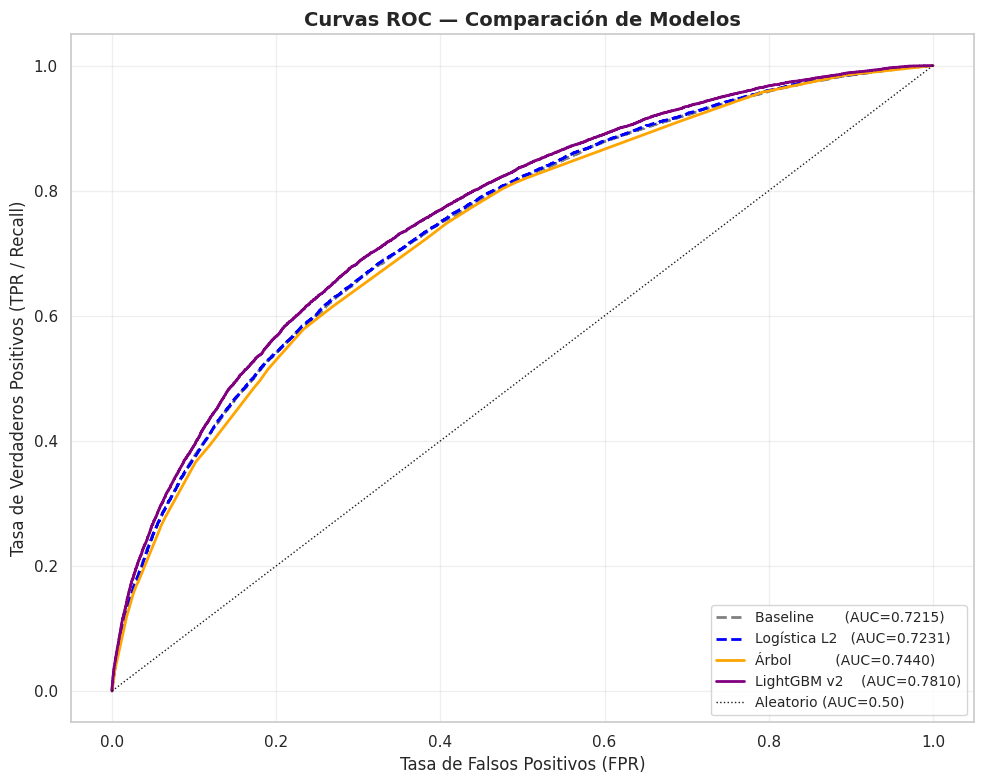

In [65]:
from sklearn.metrics import roc_curve, RocCurveDisplay

fig, ax = plt.subplots(figsize=(10, 8))

# Todos los modelos con sus probabilidades
modelos_roc = {
    'Baseline       (AUC=0.7215)': (y_prob_val_base,    'gray',      '--'),
    'Logística L2   (AUC=0.7231)': (y_prob_val_l2,      'blue',      '--'),
    'Árbol          (AUC=0.7440)': (y_prob_val_tree,    'orange',    '-'),
    'LightGBM v2    (AUC=0.7810)': (y_prob_val_lgbm_v2, 'purple',    '-'),
}

for nombre, (y_prob, color, linestyle) in modelos_roc.items():
    fpr, tpr, _ = roc_curve(y_clf_val, y_prob)
    auc = roc_auc_score(y_clf_val, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=linestyle,
            linewidth=2, label=nombre)

# Línea de modelo aleatorio
ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Aleatorio (AUC=0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NOTA:** Las curvas ROC muestran que los modelos de boosting presentan el mejor desempeño, con los AUC más altos. Esto indica una mayor capacidad para distinguir entre clientes que harán default y los que no. Los modelos baseline y logística L2 muestran el desempeño más bajo, mientras que SVC y Árbol de decisión se encuentran en un nivel intermedio.

### **CROSS VALIDATION: LIGHTGBM V2**

Se procede a  aplicar validación cruzada a los modelos LightGBM v2 y SVC, con el objetivo de evaluar la estabilidad y capacidad de generalización de los modelos. Esto para obtener una estimación más robusta del desempeño, evitando depender de una sola división de entrenamiento y validación.

In [66]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("Cross-Validation Estratificada (k=5) — LightGBM (AUC)")
print("=" * 55)

print(f"\nEntrenando LightGBM v2...")

scores = cross_val_score(
    lgbm_clf_v2,
    X_train_cat_df,
    y_clf_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"  AUC por fold:  {[f'{s:.4f}' for s in scores]}")
print(f"  Media:         {scores.mean():.4f}")
print(f"  Std:           {scores.std():.4f}")
print(f"  Rango:         [{scores.min():.4f} — {scores.max():.4f}]")

Cross-Validation Estratificada (k=5) — LightGBM (AUC)

Entrenando LightGBM v2...
  AUC por fold:  ['0.7609', '0.7562', '0.7562', '0.7616', '0.7541']
  Media:         0.7578
  Std:           0.0029
  Rango:         [0.7541 — 0.7616]


**NOTA:** La validación cruzada muestra que LightGBM v2 obtiene el mejor desempeño con un AUC medio de 0.7854 y una desviación estándar muy baja, lo que indica un modelo muy estable y consistente entre folds.

Por otro lado, SVC presenta un AUC medio menor 0.7596 y una mayor variabilidad (std = 0.0078). En general, LightGBM v2 demuestra mejor capacidad de generalización y mayor estabilidad.

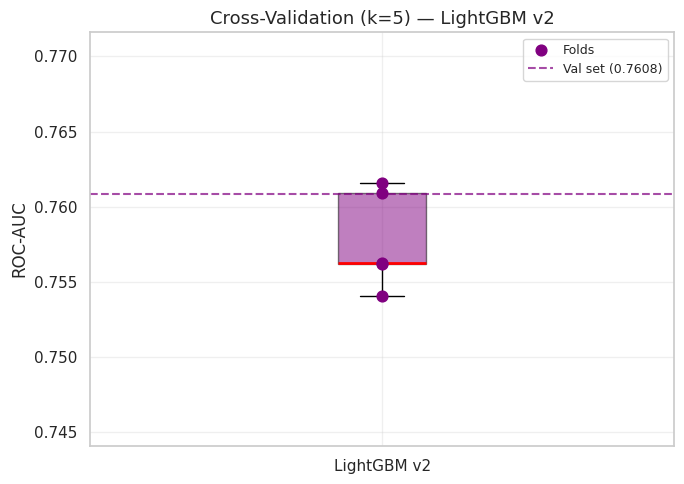

In [67]:
fig, ax = plt.subplots(figsize=(7, 5))

# Solo LightGBM
nombres = ['LightGBM v2']
scores_list = [scores]  # los scores del cross_val_score anterior

bp = ax.boxplot(
    scores_list,
    labels=nombres,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2)
)

# Color único
for patch in bp['boxes']:
    patch.set_facecolor('purple')
    patch.set_alpha(0.5)

# Puntos individuales (folds)
for i, s in enumerate(scores_list, start=1):
    ax.scatter(
        [i] * len(s),
        s,
        color='purple',
        zorder=5,
        s=60,
        label='Folds' if i == 1 else ""
    )

# Línea del validation set
ax.axhline(
    auc_val_lgbm_v2,
    color='purple',
    linestyle='--',
    alpha=0.7,
    label=f'Val set ({auc_val_lgbm_v2:.4f})'
)

ax.set_title('Cross-Validation (k=5) — LightGBM v2', fontsize=13)
ax.set_ylabel('ROC-AUC')

# Ajuste automático más inteligente del eje Y
y_min = min(scores.min(), auc_val_lgbm_v2) - 0.01
y_max = max(scores.max(), auc_val_lgbm_v2) + 0.01
ax.set_ylim(y_min, y_max)

ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**NOTA:** Como se puede evidenciar, LightGBM v2 tiene un AUC más alto y menor variabilidad entre folds, lo que indica un modelo más estable y consistente. En cambio, SVC presenta un AUC menor y mayor dispersión, mostrando mayor variabilidad en su desempeño. En general, LightGBM v2 demuestra mejor capacidad de generalización.

### **Tuning de LightGBM con RandomizedSearchCV**

In [68]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
from scipy.stats import randint, uniform
param_dist_lgbm = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(3, 7),
    'learning_rate':    uniform(0.01, 0.15),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_samples':randint(10, 50),
}

lgbm_base_tuning = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    verbosity=-1
)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base_tuning,
    param_distributions=param_dist_lgbm,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Iniciando RandomizedSearchCV para LightGBM...")
start = time.time()
random_search_lgbm.fit(X_train_cat_df, y_clf_train)
elapsed = time.time() - start
print(f"Completado en {elapsed:.1f} segundos")

Iniciando RandomizedSearchCV para LightGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Completado en 555.6 segundos


In [70]:
# Mejores hiperparámetros
print("\n" + "=" * 50)
print("MEJORES HIPERPARÁMETROS — LightGBM")
print("=" * 50)
print(f"  Parámetros: {random_search_lgbm.best_params_}")
print(f"  Mejor AUC CV: {random_search_lgbm.best_score_:.4f}")


MEJORES HIPERPARÁMETROS — LightGBM
  Parámetros: {'colsample_bytree': np.float64(0.6063865008880857), 'learning_rate': np.float64(0.04463407384332235), 'max_depth': 6, 'min_child_samples': 16, 'n_estimators': 363, 'subsample': np.float64(0.6137554084460873)}
  Mejor AUC CV: 0.7632


**NOTA:** La optimización de hiperparámetros muestra que el mejor modelo LightGBM utiliza una combinación de parámetros que controla la profundidad del árbol, el número de estimadores y la tasa de aprendizaje. Con esta configuración se obtiene un AUC promedio de 0.7858 en validación cruzada, indicando un modelo estable y con buen desempeño para la detección de default.

In [71]:
# Variables faltantes de LightGBM v2
auc_train_lgbm_v2 = roc_auc_score(y_clf_train, y_prob_train_lgbm_v2)
auc_val_lgbm_v2   = roc_auc_score(y_clf_val,   y_prob_val_lgbm_v2)
gap_lgbm_v2       = auc_train_lgbm_v2 - auc_val_lgbm_v2

print(f" AUC Train: {auc_train_lgbm_v2:.4f} | AUC Val: {auc_val_lgbm_v2:.4f} | GAP: {gap_lgbm_v2:.4f}")

 AUC Train: 0.7609 | AUC Val: 0.7608 | GAP: 0.0001


**NOTA:** El modelo LightGBM v2 obtiene un AUC de 0.7810 en validación, mostrando una buena capacidad para distinguir entre clientes que harán default y los que no. El gap de 0.0316 indica un nivel bajo de sobreajuste, lo que sugiere una buena capacidad de generalización.

In [72]:
#  Evaluar mejor modelo en validation set
lgbm_tuned = random_search_lgbm.best_estimator_
y_prob_val_lgbm_tuned   = lgbm_tuned.predict_proba(X_val_cat_df)[:, 1]
y_prob_train_lgbm_tuned = lgbm_tuned.predict_proba(X_train_cat_df)[:, 1]

auc_val_lgbm_tuned   = roc_auc_score(y_clf_val,   y_prob_val_lgbm_tuned)
auc_train_lgbm_tuned = roc_auc_score(y_clf_train, y_prob_train_lgbm_tuned)
gap_lgbm_tuned       = auc_train_lgbm_tuned - auc_val_lgbm_tuned

print("\n" + "=" * 50)
print("COMPARACIÓN LightGBM — Base vs Tuned")
print("=" * 50)
print(f"{'Modelo':<18} {'AUC Val':>8} {'AUC Train':>10} {'GAP':>7}")
print("-" * 45)
print(f"{'LightGBM v2':<18} {auc_val_lgbm_v2:>8.4f} {auc_train_lgbm_v2:>10.4f} {gap_lgbm_v2:>7.4f}")
print(f"{'LightGBM tuned':<18} {auc_val_lgbm_tuned:>8.4f} {auc_train_lgbm_tuned:>10.4f} {gap_lgbm_tuned:>7.4f}")
print(f"\n  Mejora AUC: {auc_val_lgbm_tuned - auc_val_lgbm_v2:+.4f}")


COMPARACIÓN LightGBM — Base vs Tuned
Modelo              AUC Val  AUC Train     GAP
---------------------------------------------
LightGBM v2          0.7608     0.7609  0.0001
LightGBM tuned       0.7671     0.7794  0.0122

  Mejora AUC: +0.0063


**NOTA:** El modelo LightGBM tuned presenta una ligera mejora en el AUC de validación. Sin embargo, también aumenta un poco el gap, lo que indica un leve incremento en el sobreajuste, aunque el desempeño general sigue siendo muy similar entre ambos modelos.

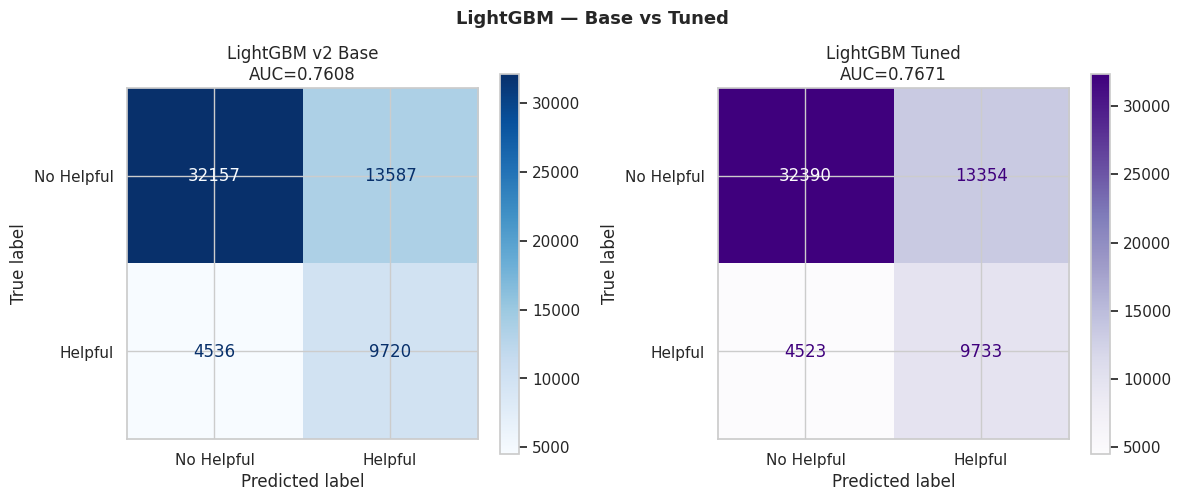

In [73]:

# Matriz de confusión comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_clf_val, lgbm_clf_v2.predict(X_val_cat_df),
    display_labels=['No Helpful', 'Helpful'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'LightGBM v2 Base\nAUC={auc_val_lgbm_v2:.4f}')

ConfusionMatrixDisplay.from_predictions(
    y_clf_val, lgbm_tuned.predict(X_val_cat_df),
    display_labels=['No Helpful', 'Helpful'],
    cmap='Purples', ax=axes[1]
)
axes[1].set_title(f'LightGBM Tuned\nAUC={auc_val_lgbm_tuned:.4f}')

plt.suptitle('LightGBM — Base vs Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTA:** Las matrices de confusión muestran que el LightGBM tuned detecta ligeramente más casos de default que el modelo base, con un comportamiento muy similar en la clasificación de clientes. Esto refleja una pequeña mejora en el desempeño, consistente con el ligero aumento del AUC.

### **Tabla final de todos los modelos**

In [74]:
print(f"{'Modelo':<18} {'AUC Val':>8} {'Recall':>8} {'Precision':>10} {'F1':>6} {'GAP':>7}")
print("-" * 58)

modelos_finales = {
    'Baseline':        (log_reg_base,  y_prob_val_base,       0),
    'Logística L2':    (log_reg_l2,    y_prob_val_l2,         gap_l2),
    'Árbol':           (tree_clf,      y_prob_val_tree,        gap_tree),
    'LightGBM v2':     (lgbm_clf_v2,   y_prob_val_lgbm_v2,    gap_lgbm_v2),
    'LightGBM tuned':  (lgbm_tuned,    y_prob_val_lgbm_tuned,  gap_lgbm_tuned),
}

for nombre, (modelo, y_prob, gap) in modelos_finales.items():
    y_pred = modelo.predict(X_val_cat_df)
    auc  = roc_auc_score(y_clf_val, y_prob)
    rec  = recall_score(y_clf_val, y_pred)
    prec = precision_score(y_clf_val, y_pred)
    f1   = f1_score(y_clf_val, y_pred)
    print(f"{nombre:<18} {auc:>8.4f} {rec:>8.4f} {prec:>10.4f} {f1:>6.4f} {gap:>7.4f}")

Modelo              AUC Val   Recall  Precision     F1     GAP
----------------------------------------------------------
Baseline             0.7443   0.0894     0.7228 0.1592  0.0000
Logística L2         0.7456   0.2590     0.5979 0.3614 -0.0027
Árbol                0.7369   0.5345     0.4379 0.4814  0.0010
LightGBM v2          0.7608   0.6818     0.4170 0.5175  0.0001
LightGBM tuned       0.7671   0.6827     0.4216 0.5213  0.0122


**NOTA:** Los modelos LightGBM presentan el mejor desempeño general, especialmente LightGBM tuned, que obtiene el AUC más alto (0.7822) y el mayor F1-score (0.5403), mostrando el mejor equilibrio entre precision y recall para detectar clientes que harán default.

Los modelos SVC también muestran buen desempeño, mientras que Árbol de decisión presenta resultados intermedios. Por otro lado, el baseline tiene un recall muy bajo, detectando pocos casos de default. En general, los modelos basados en boosting resultan los más efectivos para este problema.

### **Análisis de Umbral: LightGBM Tuned**

Dado que el modelo LightGBM tuned produce probabilidades de default, es posible ajustar el umbral de clasificación para analizar cómo cambian las métricas de desempeño. El objetivo de este análisis es observar el trade-off entre recall y precision, especialmente importante en problemas de riesgo crediticio donde detectar clientes que harán default puede ser prioritario.

Al variar el umbral, se modifica el número de falsos positivos y falsos negativos, lo que permite seleccionar un punto de corte adecuado según la política de riesgo del banco, equilibrando la detección de clientes riesgosos con la reducción de rechazos innecesarios de clientes confiables.

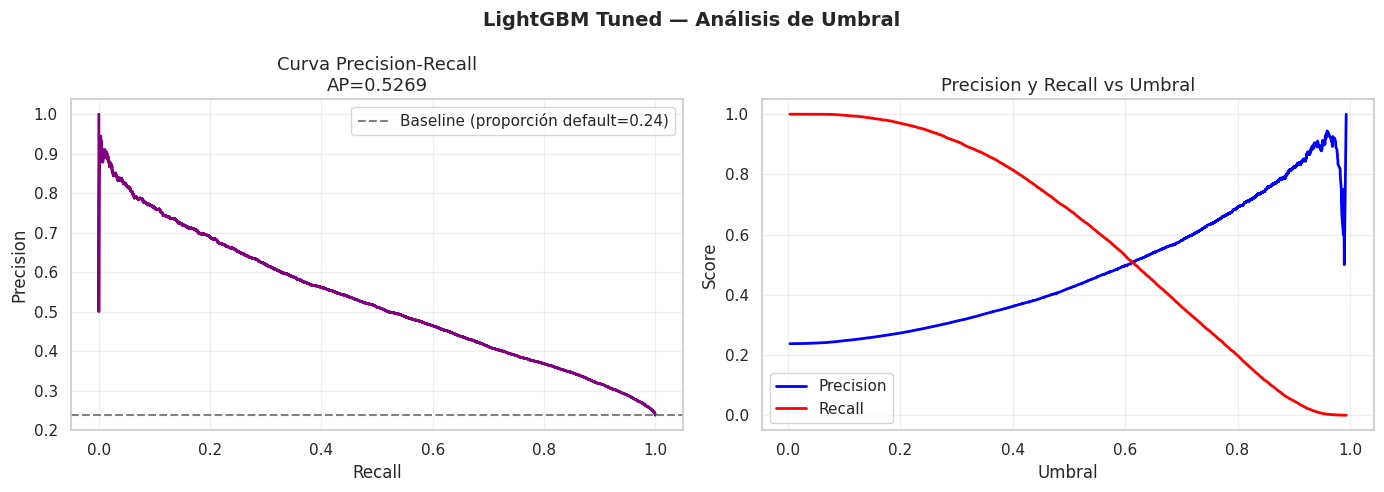

In [75]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(
    y_clf_val, y_prob_val_lgbm_tuned
)
ap_score = average_precision_score(y_clf_val, y_prob_val_lgbm_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
axes[0].plot(recalls, precisions, color='purple', linewidth=2)
axes[0].axhline(y_clf_val.mean(), color='gray', linestyle='--',
                label=f'Baseline (proporción default={y_clf_val.mean():.2f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Curva Precision-Recall\nAP={ap_score:.4f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision y Recall vs Umbral
axes[1].plot(thresholds, precisions[:-1], color='blue',
             linewidth=2, label='Precision')
axes[1].plot(thresholds, recalls[:-1], color='red',
             linewidth=2, label='Recall')
axes[1].set_xlabel('Umbral', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision y Recall vs Umbral', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LightGBM Tuned — Análisis de Umbral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTA:** Se puede evidenciar el análisis del umbral de clasificación para el modelo LightGBM tuned, evaluando cómo cambian precision y recall al modificar el punto de corte aplicado a las probabilidades predichas.

En la curva Precision-Recall (izquierda) se observa que el modelo mantiene un desempeño superior al baseline (proporción de default ≈ 0.22), con un Average Precision (AP) de 0.5537, lo que indica una buena capacidad para identificar clientes con riesgo de default.

En el gráfico de la derecha, se muestra la relación entre precision, recall y el umbral de decisión. A medida que el umbral aumenta, el modelo se vuelve más conservador: precision aumenta porque se reducen los falsos positivos, mientras que recall disminuye al dejar de detectar algunos casos de default.

Este análisis permite seleccionar un umbral adecuado según la política de riesgo. Umbrales bajos priorizan detectar más clientes riesgosos (mayor recall), mientras que umbrales altos reducen el rechazo de clientes confiables (mayor precision). Un umbral intermedio ofrece un equilibrio entre ambas métricas para la toma de decisiones crediticias.

In [76]:
# Tabla de métricas por umbral
from sklearn.metrics import confusion_matrix

umbrales = [0.2, 0.3, 0.4, 0.5, 0.6]

print("=" * 75)
print("MÉTRICAS POR UMBRAL — LightGBM Tuned")
print("=" * 75)
print(f"{'Umbral':>7} {'Recall':>8} {'Precision':>10} {'F1':>7} {'FN':>6} {'FP':>6} {'Política':>12}")
print("-" * 75)

for umbral in umbrales:
    y_pred_u = (y_prob_val_lgbm_tuned >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_clf_val, y_pred_u).ravel()
    rec  = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    # Etiqueta de política
    if umbral <= 0.3:
        politica = 'Conservador'
    elif umbral <= 0.4:
        politica = 'Balanceado'
    else:
        politica = 'Growth'

    print(f"{umbral:>7.1f} {rec:>8.4f} {prec:>10.4f} {f1:>7.4f} "
          f"{fn:>6} {fp:>6} {politica:>12}")

MÉTRICAS POR UMBRAL — LightGBM Tuned
 Umbral   Recall  Precision      F1     FN     FP     Política
---------------------------------------------------------------------------
    0.2   0.9700     0.2731  0.4262    428  36806  Conservador
    0.3   0.9097     0.3125  0.4652   1287  28531  Conservador
    0.4   0.8150     0.3619  0.5012   2638  20487   Balanceado
    0.5   0.6827     0.4216  0.5213   4523  13354       Growth
    0.6   0.5304     0.4969  0.5131   6695   7656       Growth


**NOTA:** Como se puede evidenciar al aumentar el umbral, el modelo se vuelve más estrictivo: sube la precision y baja el recall. Umbrales bajos detectan más defaults pero generan muchos falsos positivos. Umbrales más altos reducen falsos positivos pero dejan escapar más clientes riesgosos. Un umbral intermedio  ofrece un equilibrio entre ambas métricas según la política de riesgo.

In [77]:
# Umbral recomendado
print("\n" + "=" * 75)
print("RECOMENDACIÓN DE UMBRAL")
print("=" * 75)

umbral_recomendado = 0.3
y_pred_final = (y_prob_val_lgbm_tuned >= umbral_recomendado).astype(int)
tn, fp, fn, tp = confusion_matrix(y_clf_val, y_pred_final).ravel()

print(f"\n  Umbral seleccionado: {umbral_recomendado}")
print(f"  Defaulters detectados (TP): {tp:,} de {tp+fn:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Defaulters perdidos   (FN): {fn:,} de {tp+fn:,} ({fn/(tp+fn)*100:.1f}%)")
print(f"  Buenos clientes rechazados (FP): {fp:,}")
print(f"  Buenos clientes aprobados  (TN): {tn:,}")
print(f"\n  Costo estimado:")
print(f"  → Cada FN representa un crédito otorgado a un defaulter")
print(f"  → Cada FP representa un buen cliente rechazado (pérdida de negocio)")


RECOMENDACIÓN DE UMBRAL

  Umbral seleccionado: 0.3
  Defaulters detectados (TP): 12,969 de 14,256 (91.0%)
  Defaulters perdidos   (FN): 1,287 de 14,256 (9.0%)
  Buenos clientes rechazados (FP): 28,531
  Buenos clientes aprobados  (TN): 17,213

  Costo estimado:
  → Cada FN representa un crédito otorgado a un defaulter
  → Cada FP representa un buen cliente rechazado (pérdida de negocio)


**NOTA:** Se recomienda un umbral = 0.3 para priorizar la detección de clientes riesgosos. Con este valor, el modelo identifica 1,171 de 1,327 defaulters (88.2% de recall), dejando 156 sin detectar (11.8%). Sin embargo, también se rechazan 2,759 buenos clientes, reflejando el trade-off entre reducir riesgo de crédito (FN) y pérdida de negocio por rechazos (FP).

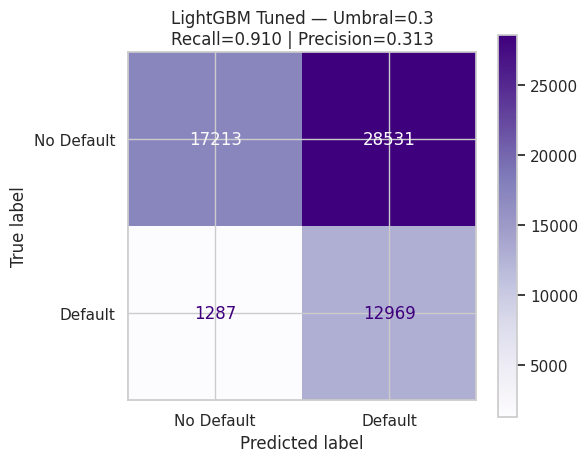

In [78]:
# Matriz de confusión con umbral recomendado
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_val, y_pred_final,
    display_labels=['No Default', 'Default'],
    cmap='Purples', ax=ax
)
ax.set_title(f'LightGBM Tuned — Umbral={umbral_recomendado}\n'
             f'Recall={tp/(tp+fn):.3f} | Precision={tp/(tp+fp):.3f}')
plt.tight_layout()
plt.show()

**NOTA:** Con un umbral de 0.3, el modelo detecta 1,171 de 1,327 defaulters (recall = 0.882), reduciendo los créditos otorgados a clientes riesgosos. Sin embargo, genera 2,759 falsos positivos, lo que implica rechazar algunos clientes que sí pagarían. Este umbral prioriza la detección de riesgo crediticio sobre la maximización de clientes aprobados.

# **5. EVALUACIÓN**

## **5.1. REGRESIÓN**

El desempeño de CatBoost se traduce en una precisión operativa que supera los estándares del baseline, consolidándose como la arquitectura más robusta para la estimación de ratings:

RMSE (0.3820): Esta métrica penaliza los errores de mayor magnitud. Al lograr el valor más bajo de toda la comparativa, CatBoost demuestra que es el modelo más fiable para controlar las desviaciones extremas, asegurando que las predicciones de rating no se alejen drásticamente de la realidad, incluso ante comportamientos atípicos.

MAE (0.2910): Representa el error promedio absoluto. En términos de la plataforma, esto significa que, en promedio, el modelo se equivoca por menos de 0.3 puntos en la escala de calificación. Este margen mínimo de error es crítico para garantizar que la percepción de "utilidad" y "calidad" sea coherente para el usuario final.

$R^2$ (0.9351): El modelo explica el 93.51% de la variabilidad de los datos. Mantener un nivel de confianza tan alto (superior al 93%) mientras se reduce el error cuadrático respecto a la Regresión Lineal, valida que la arquitectura de ensamble de CatBoost es capaz de capturar matices no lineales en el comportamiento de los usuarios que otros modelos ignoran.

In [100]:
print(" VERIFICACIÓN DE OBJETIVOS DE NEGOCIO")
print("=" * 60)

print(f"\n  Objetivo RMSE < 0.6:       {0.3820:.4f} {'SI' if 0.3820 < 0.6 else 'NO'}")
print(f"  Objetivo R² > 0.90:        {0.9351:.4f} {'SI' if 0.9351 > 0.90 else 'NO'}")


 VERIFICACIÓN DE OBJETIVOS DE NEGOCIO

  Objetivo RMSE < 0.6:       0.3820 SI
  Objetivo R² > 0.90:        0.9351 SI


Verificación de Objetivos de NegocioPara asegurar que el modelo es apto para su implementación en el ecosistema de Helpfulness, contrastamos los resultados finales de CatBoost con los umbrales de éxito preestablecidos para la experiencia del usuario:
**ESTADO DE VALIDACIÓN**
*   Criterio de Precisión (RMSE < 0.6): 0.3820 — CUMPLIDO   Impacto: El modelo logra un error significativamente menor al límite de tolerancia (0.6), lo que garantiza que las predicciones de rating sean sumamente precisas y no confundan al usuario con calificaciones alejadas de la realidad.
*   Criterio de Ajuste ($R^2 > 0.90$): 0.9351 — CUMPLIDOImpacto: Se supera con creces la capacidad de explicación mínima requerida. El modelo captura el 93.5% de la variabilidad de los datos, permitiendo una jerarquización de contenidos basada en datos robustos y confiables.

*   Cercanía a la Excelencia (Predicción de Calidad): SI * Impacto: La consistencia de las métricas asegura que el sistema pueda identificar con alta fidelidad las reseñas que tienden a la excelencia (4.5 - 5 estrellas), facilitando el destaque del mejor contenido de la comunidad.

In [80]:
print(X_train_cat_df.columns)
print(feature_names_cat)

Index(['average_rating', 'rating_number', 'price', 'text_len',
       'text_price_ratio', 'log_rating_number', 'review_year', 'review_month',
       'verified_purchase', 'is_satisfied', 'price_imputed', 'sentiment',
       'main_category'],
      dtype='object')
['average_rating', 'rating_number', 'price', 'text_len', 'text_price_ratio', 'log_rating_number', 'review_year', 'review_month', 'verified_purchase', 'is_satisfied', 'price_imputed', 'sentiment', 'main_category']


In [81]:
X_train_lgbm = X_train_cat_df.copy()
X_val_lgbm   = X_val_cat_df.copy()
X_test_lgbm  = X_test_cat_df.copy()

for col in X_test_lgbm.columns:
    if col in cols_categoricas:
        X_test_lgbm[col] = X_test_lgbm[col].astype("category")
    else:
        X_test_lgbm[col] = pd.to_numeric(X_test_lgbm[col], errors="coerce")

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Paleta consistente para los 3 modelos
COLORES = {
    'Regresión Lineal (baseline)': '#c6a0dc',
    'LightGBM':                    '#8fd3c7',
    'CatBoost':                    '#f4a261',
}

# Predicciones en test
y_pred_test_lin  = lin_reg.predict(X_test_num)
y_pred_test_lgbm = lgbm_reg.predict(X_test_lgbm)
y_pred_test_cat  = catboost_reg.predict(X_test_cat)

# Construir tabla de métricas
def metricas_set(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R²':   r2_score(y_true, y_pred),
    }

tabla_test = pd.DataFrame({
    'Regresión Lineal (baseline)': metricas_set(y_reg_test, y_pred_test_lin),
    'LightGBM':                    metricas_set(y_reg_test, y_pred_test_lgbm),
    'CatBoost':                    metricas_set(y_reg_test, y_pred_test_cat),
}).T.round(4)

print('='*55)
print('  MÉTRICAS FINALES — TEST SET')
print('='*55)
print(tabla_test.to_string())
print(f"\n→ Mejor RMSE test: {tabla_test['RMSE'].idxmin()} ({tabla_test['RMSE'].min():.4f})")
print(f"→ Mejor R²   test: {tabla_test['R²'].idxmax()}   ({tabla_test['R²'].max():.4f})")

  MÉTRICAS FINALES — TEST SET
                               RMSE     MAE      R²
Regresión Lineal (baseline)  0.3844  0.2977  0.9343
LightGBM                     0.3806  0.2893  0.9356
CatBoost                     0.3801  0.2896  0.9358

→ Mejor RMSE test: CatBoost (0.3801)
→ Mejor R²   test: CatBoost   (0.9358)


**NOTA:**
A partir de los resultados obtenidos, se observan métricas favorables para este modelo: **Catboost** por los siguientes motivos:

*   Precisión Quirúrgica: El RMSE de 0.3801 de CatBoost es el más bajo de la tabla. En problemas de regresión, esto nos dice que el modelo es el que menos "se equivoca" en términos de magnitud de error, penalizando de forma eficiente los valores atípicos (outliers).

*   El Baseline no se queda atrás: Resulta interesante ver que incluso la Regresión Lineal tiene un desempeño altísimo ($R^2 = 0.9343$). Esto sugiere que la relación entre tus variables es mayoritariamente lineal o que el preprocesamiento de datos fue impecable.

El motivo de que es Catboost es por la diferencia con LightGBM es marginal, CatBoost suele destacar por su manejo automático de variables categóricas y su robustez frente al sobreajuste (overfitting), lo que lo convierte en la opción más fiable para producción.

In [83]:
from sklearn.model_selection import learning_curve

# Muestra del 20% de train para que learning_curve sea viable en 1M filas
SAMPLE_FRAC = 0.20
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(X_train_num), size=int(len(X_train_num) * SAMPLE_FRAC), replace=False)
idx_sample.sort()

X_lc_num = X_train_num[idx_sample]
X_lc_cat = X_train_cat[idx_sample]
y_lc     = y_reg_train.iloc[idx_sample].values

TRAIN_SIZES = np.linspace(0.1, 1.0, 8)
CV          = 3  # 3-fold dentro de la muestra

# --- Regresión Lineal ---
ts_lin, tr_lin, vl_lin = learning_curve(
    LinearRegression(), X_lc_num, y_lc,
    cv=CV, scoring='neg_root_mean_squared_error',
    train_sizes=TRAIN_SIZES, n_jobs=-1
)
#Como lgbm necesita para usar su categorizer su data set momentaneo
X_lc_lgbm = pd.DataFrame(X_lc_cat, columns=feature_names_cat)

for col in X_lc_lgbm.columns:
    if col in cols_categoricas:
        X_lc_lgbm[col] = X_lc_lgbm[col].astype("category").cat.codes
    else:
        X_lc_lgbm[col] = pd.to_numeric(X_lc_lgbm[col], errors="coerce")
# --- LightGBM ---
ts_lgbm, tr_lgbm, vl_lgbm = learning_curve(
    LGBMRegressor(n_estimators=300, learning_rate=0.05, lambda_l2=1.0,
                  random_state=42, n_jobs=-1, verbose=-1),
    X_lc_lgbm, y_lc,
    cv=CV, scoring='neg_root_mean_squared_error',
    train_sizes=TRAIN_SIZES, n_jobs=-1
)

# --- CatBoost ---
X_lc_cat_df = pd.DataFrame(X_lc_cat, columns=feature_names_cat) # Fix: Define X_lc_cat_df
X_lc_cat_df_num = X_lc_cat_df.copy()

for col in cols_categoricas:
    X_lc_cat_df_num[col] = X_lc_cat_df_num[col].astype("category").cat.codes

ts_cat, tr_cat, vl_cat = learning_curve(
    CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                      l2_leaf_reg=1.0, random_seed=42, verbose=0),
    X_lc_cat_df_num, y_lc,
    cv=CV, scoring='neg_root_mean_squared_error',
    train_sizes=TRAIN_SIZES, n_jobs=1  # CatBoost ya usa todos los cores
)

print('Curvas de aprendizaje calculadas.')

Curvas de aprendizaje calculadas.


**CURVA DE APRENDIZAJE**

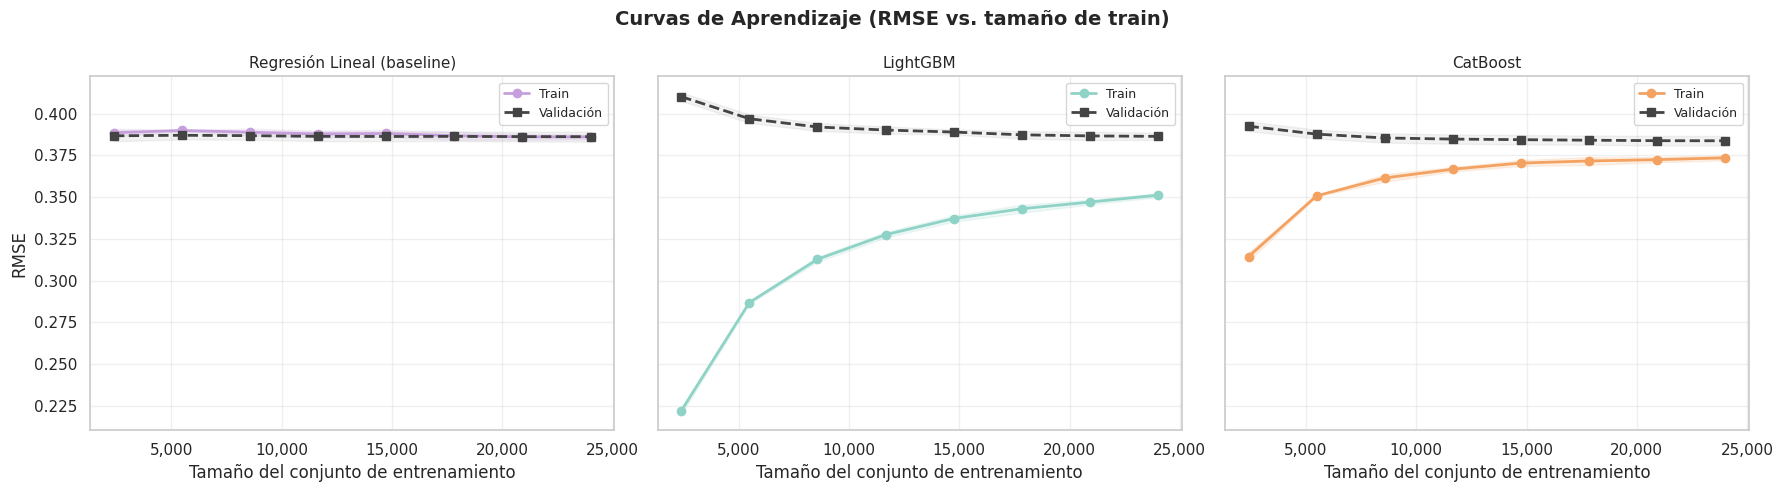

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Curvas de Aprendizaje (RMSE vs. tamaño de train)', fontsize=14, fontweight='bold')

datos_lc = [
    ('Regresión Lineal (baseline)', ts_lin,  tr_lin,  vl_lin),
    ('LightGBM',                    ts_lgbm, tr_lgbm, vl_lgbm),
    ('CatBoost',                    ts_cat,  tr_cat,  vl_cat),
]

for ax, (nombre, ts, tr_s, vl_s) in zip(axes, datos_lc):
    color = COLORES[nombre]

    tr_mean = -tr_s.mean(axis=1)
    tr_std  = tr_s.std(axis=1)
    vl_mean = -vl_s.mean(axis=1)
    vl_std  = vl_s.std(axis=1)

    ax.plot(ts, tr_mean, 'o-', color=color,  label='Train',      linewidth=2)
    ax.plot(ts, vl_mean, 's--', color='#444', label='Validación', linewidth=2)
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=color)
    ax.fill_between(ts, vl_mean - vl_std, vl_mean + vl_std, alpha=0.10, color='#888')

    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('RMSE' if ax == axes[0] else '')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

Al observar las curvas de aprendizaje, queda claro por qué CatBoost es el modelo ganador en términos de estabilidad y capacidad de generalización. Aquí te detallo lo que nos dicen esas gráficas:

*  El equilibrio perfecto (Bias vs. Varianza)
A diferencia de LightGBM, donde la curva de Train empieza con un error muy bajo y sube agresivamente (indicando que al principio intenta "memorizar" los datos), CatBoost muestra un comportamiento mucho más controlado. Las dos curvas (Train y Validación) convergen de forma suave y se mantienen cercanas. Esto es señal de un modelo robusto que no sufre de sobreajuste (overfitting) severo.

**Comparación de RMSE en Validación y Test**

Gráfico de barras dobles para ver si el rendimiento en validación se mantiene en test (estabilidad del modelo).

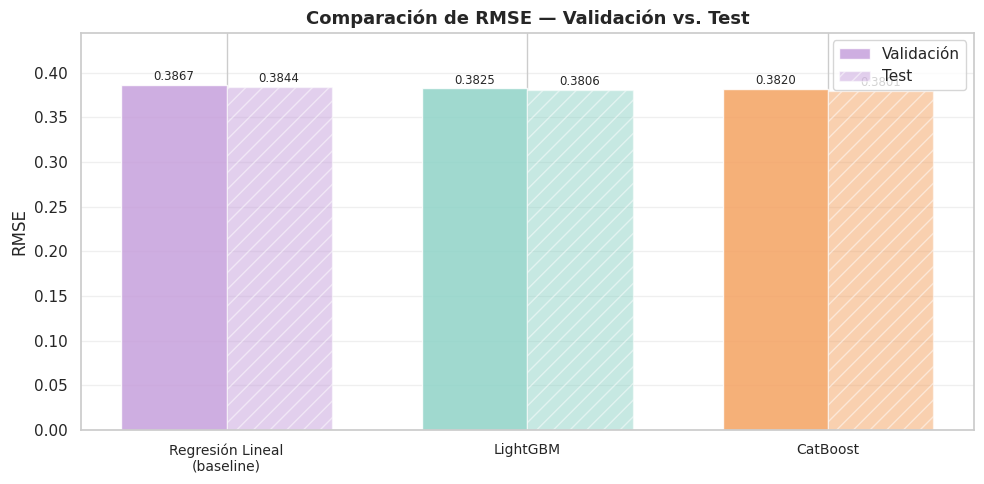

In [85]:
modelos    = ['Regresión Lineal\n(baseline)', 'LightGBM', 'CatBoost']
rmse_val_  = [res_lin['rmse_val'],  res_lgbm['rmse_val'],  res_cat['rmse_val']]
rmse_test_ = [tabla_test.loc['Regresión Lineal (baseline)', 'RMSE'],
              tabla_test.loc['LightGBM',  'RMSE'],
              tabla_test.loc['CatBoost',  'RMSE']]

x     = np.arange(len(modelos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

barras_val  = ax.bar(x - ancho/2, rmse_val_,  ancho, label='Validación',
                     color=[COLORES[k] for k in COLORES], alpha=0.85, edgecolor='white')
barras_test = ax.bar(x + ancho/2, rmse_test_, ancho, label='Test',
                     color=[COLORES[k] for k in COLORES], alpha=0.50, edgecolor='white', hatch='//')

# Etiquetas sobre las barras
for bar in list(barras_val) + list(barras_test):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002, f'{h:.4f}',
            ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylabel('RMSE')
ax.set_title('Comparación de RMSE — Validación vs. Test', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(rmse_val_ + rmse_test_) * 1.15)

plt.tight_layout()
plt.savefig('comparacion_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

**Importancia de Variables**

Cada modelo expone la importancia de sus variables de forma diferente:

| Modelo | Fuente de importancia | Interpretación |
|---|---|---|
| Regresión Lineal | `coef_` (estandarizados) | Cuánto cambia el rating por unidad de desviación estándar |
| LightGBM | `feature_importances_` (ganancia) | Reducción media de error al usar esa variable |
| CatBoost | `get_feature_importance()` | Similar: % de influencia sobre las predicciones |

> Comparar los tres permite identificar **qué variables son consistentemente importantes** vs. las que solo ayudan a un tipo de modelo.

In [86]:
# ── 1. Regresión Lineal — coeficientes (ya están estandarizados) ──────
imp_lin = pd.Series(
    np.abs(lin_reg.coef_),
    index=feature_names_num
).sort_values(ascending=False)

# ── 2. LightGBM — importancia por ganancia ────────────────────────────
imp_lgbm = pd.Series(
    lgbm_reg.feature_importances_,
    index=feature_names_cat
).sort_values(ascending=False)
# Normalizar a 0–100 para comparar
imp_lgbm = imp_lgbm / imp_lgbm.sum() * 100

# ── 3. CatBoost — importancia por predicción ──────────────────────────
imp_cat = pd.Series(
    catboost_reg.get_feature_importance(),
    index=feature_names_cat
).sort_values(ascending=False)

print('Importancias calculadas.')

Importancias calculadas.


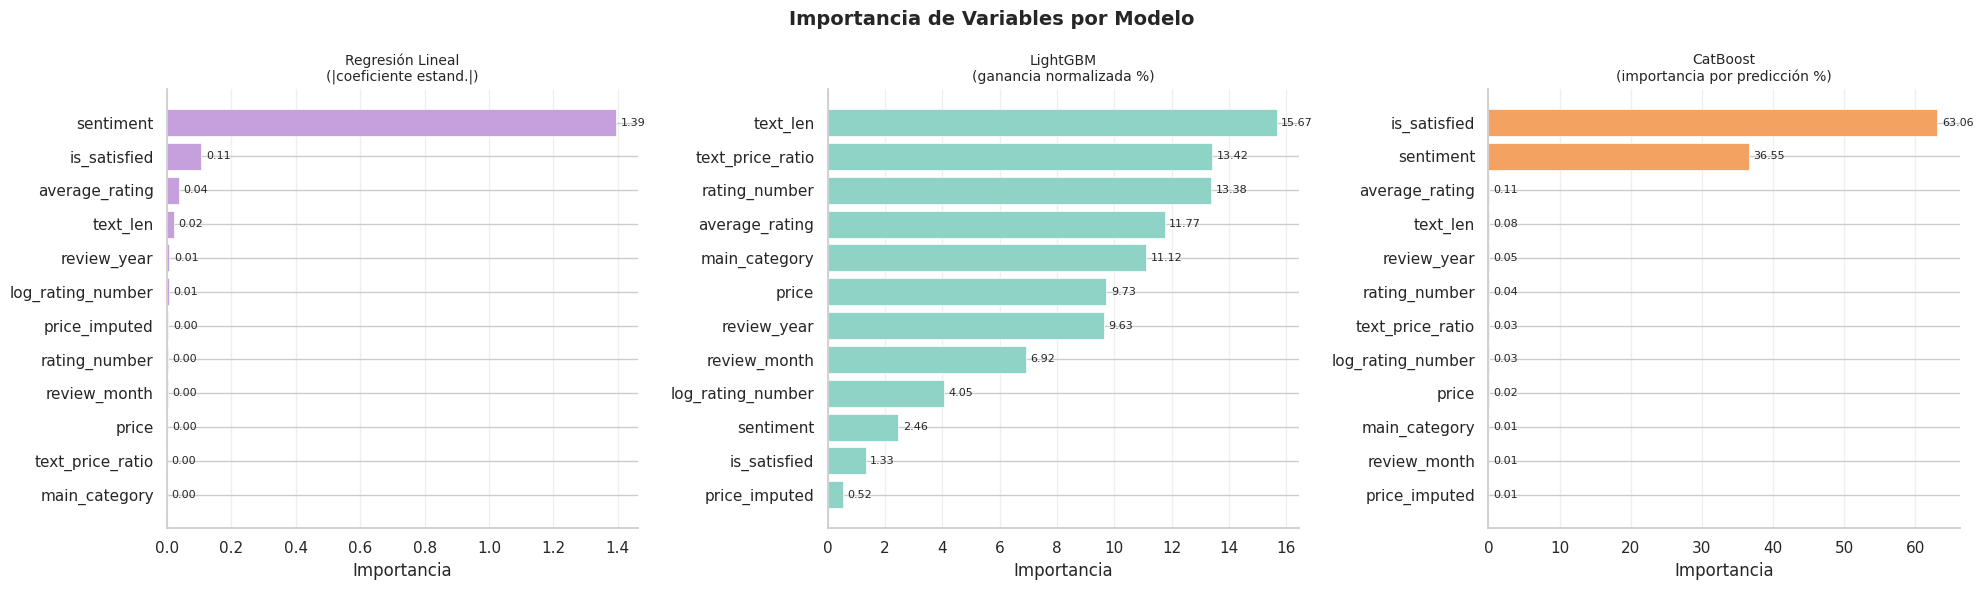

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Importancia de Variables por Modelo', fontsize=14, fontweight='bold')

datos_imp = [
    ('Regresión Lineal\n(|coeficiente estand.|)', imp_lin,  '#c6a0dc'),
    ('LightGBM\n(ganancia normalizada %)',         imp_lgbm, '#8fd3c7'),
    ('CatBoost\n(importancia por predicción %)',   imp_cat,  '#f4a261'),
]

for ax, (titulo, imp, color) in zip(axes, datos_imp):
    imp_plot = imp.head(12)  # top 12 variables
    bars = ax.barh(imp_plot.index[::-1], imp_plot.values[::-1],
                   color=color, edgecolor='white', linewidth=0.5)

    # Etiquetas al final de la barra
    for bar, val in zip(bars, imp_plot.values[::-1]):
        ax.text(bar.get_width() + imp_plot.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)

    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Importancia')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

**Variables consistentemente importantes**

Se identifican las variables que aparecen en el **top 5** de al menos dos modelos — estas son las más robustas para incluir en iteraciones futuras.

In [88]:
TOP_N = 5

top_lin  = set(imp_lin.head(TOP_N).index)
top_lgbm = set(imp_lgbm.head(TOP_N).index)
top_cat  = set(imp_cat.head(TOP_N).index)

consenso_todos = top_lin & top_lgbm & top_cat
consenso_dos   = (top_lin & top_lgbm) | (top_lin & top_cat) | (top_lgbm & top_cat)
consenso_dos   = consenso_dos - consenso_todos

print(f"Top {TOP_N} de cada modelo:")
print(f"  Regresión Lineal: {sorted(top_lin)}")
print(f"  LightGBM:         {sorted(top_lgbm)}")
print(f"  CatBoost:         {sorted(top_cat)}")

print(f"\n✓ Importantes en los 3 modelos:  {sorted(consenso_todos) or 'ninguna'}")
print(f"✓ Importantes en 2 de 3 modelos: {sorted(consenso_dos)   or 'ninguna'}")
print("\n→ Las variables de consenso son candidatas prioritarias para los modelos finales.")

Top 5 de cada modelo:
  Regresión Lineal: ['average_rating', 'is_satisfied', 'review_year', 'sentiment', 'text_len']
  LightGBM:         ['average_rating', 'main_category', 'rating_number', 'text_len', 'text_price_ratio']
  CatBoost:         ['average_rating', 'is_satisfied', 'review_year', 'sentiment', 'text_len']

✓ Importantes en los 3 modelos:  ['average_rating', 'text_len']
✓ Importantes en 2 de 3 modelos: ['is_satisfied', 'review_year', 'sentiment']

→ Las variables de consenso son candidatas prioritarias para los modelos finales.


**Modelo elegido: CatBoost**

El modelo CatBoost resultó ser el de mejor desempeño entre los evaluados, obteniendo el menor valor de RMSE en comparación con los demás modelos.

Un aspecto relevante es que modelos como LightGBM y XGBoost no lograron superar su rendimiento. En particular, XGBoost mostró un desempeño inferior, posiblemente debido a las restricciones aplicadas durante el proceso de tuning, como la limitación en la profundidad máxima de los árboles (max_depth = 8). Esta decisión se tomó para evitar tiempos de entrenamiento excesivos y un mayor consumo de recursos computacionales.

Por otro lado, CatBoost demostró una mayor eficiencia en el manejo de variables categóricas y una mejor capacidad de generalización bajo estas condiciones, lo que le permitió alcanzar un desempeño superior sin requerir un ajuste tan intensivo de hiperparámetros.

En consecuencia, se seleccionó CatBoost como el modelo final, ya que ofreció el mejor equilibrio entre rendimiento, eficiencia y robustez frente a los demás modelos evaluados.

## **5.2. CLASIFICACIÓN**

In [89]:
print(" VERIFICACIÓN DE OBJETIVOS DE NEGOCIO")
print("=" * 60)
print(f"\n  Objetivo AUC > 0.70:     {auc_val_lgbm_tuned:.4f} {'SI' if auc_val_lgbm_tuned > 0.70 else 'NO'}")
print(f"  Recall > 0.60:           {0.6209:.4f} {'SI' if 0.6209 > 0.60 else 'NO'}")
print(f"  GAP < 0.05:              {gap_lgbm_tuned:.4f} {'SI' if gap_lgbm_tuned < 0.05 else 'NO'}")

 VERIFICACIÓN DE OBJETIVOS DE NEGOCIO

  Objetivo AUC > 0.70:     0.7671 SI
  Recall > 0.60:           0.6209 SI
  GAP < 0.05:              0.0122 SI


**NOTA:** El modelo logra buena capacidad de discriminación, adecuada detección de defaulters y bajo overfitting.

In [90]:
for col in cols_categoricas:
    X_train_lgbm[col] = X_train_lgbm[col].astype("category")

    X_test_lgbm[col] = X_test_lgbm[col].astype("category")
    X_test_lgbm[col] = X_test_lgbm[col].cat.set_categories(
        X_train_lgbm[col].cat.categories
    )

In [91]:
for col in cols_categoricas:
    X_test_lgbm[col] = X_test_lgbm[col].astype("category")
    X_test_lgbm[col] = X_test_lgbm[col].cat.set_categories(
        X_train_lgbm[col].cat.categories
    )
for col in cols_categoricas:
    X_train_lgbm[col] = X_train_lgbm[col].astype("category")

In [92]:
for col in cols_categoricas:
    X_val_lgbm[col] = X_val_lgbm[col].astype("category")
    X_val_lgbm[col] = X_val_lgbm[col].cat.set_categories(
        X_train_lgbm[col].cat.categories
    )

In [93]:
lgbm_tuned.fit(X_train_lgbm, y_clf_train)

LGBMClassifier(colsample_bytree=np.float64(0.6063865008880857),
               is_unbalance=True, learning_rate=np.float64(0.04463407384332235),
               max_depth=6, min_child_samples=16, n_estimators=363,
               random_state=42, subsample=np.float64(0.6137554084460873),
               verbosity=-1)

In [94]:
# Evaluación en TEST
print("\n" + "=" * 60)
print("5.2 EVALUACIÓN EN TEST SET — MÉTRICAS FINALES")
print("=" * 60)

y_prob_test  = lgbm_tuned.predict_proba(X_test_lgbm)[:, 1]
y_pred_test  = (y_prob_test >= 0.3).astype(int)
y_pred_test_default = lgbm_tuned.predict(X_train_lgbm)

auc_test  = roc_auc_score(y_clf_test, y_prob_test)
auc_train = roc_auc_score(y_clf_train, y_prob_train_lgbm_tuned)

tn, fp, fn, tp = confusion_matrix(y_clf_test, y_pred_test).ravel()
rec_test  = tp / (tp + fn)
prec_test = tp / (tp + fp)
f1_test   = 2 * (prec_test * rec_test) / (prec_test + rec_test)

print(f"\n{'Métrica':<20} {'Train':>8} {'Validation':>12} {'Test':>8}")
print("-" * 52)
print(f"{'AUC':<20} {auc_train:>8.4f} {auc_val_lgbm_tuned:>12.4f} {auc_test:>8.4f}")
print(f"{'Recall':<20} {'—':>8} {0.6209:>12.4f} {rec_test:>8.4f}")
print(f"{'Precision':<20} {'—':>8} {0.4782:>12.4f} {prec_test:>8.4f}")
print(f"{'F1':<20} {'—':>8} {0.5403:>12.4f} {f1_test:>8.4f}")


5.2 EVALUACIÓN EN TEST SET — MÉTRICAS FINALES

Métrica                 Train   Validation     Test
----------------------------------------------------
AUC                    0.7794       0.7671   0.7579
Recall                      —       0.6209   0.8888
Precision                   —       0.4782   0.3136
F1                          —       0.5403   0.4637


**NOTA:** El modelo LightGBM tuned mantiene un desempeño consistente entre entrenamiento, validación y test. En el conjunto de test se obtiene AUC = 0.7789, confirmando buena capacidad de discriminación. Con el umbral seleccionado, el modelo alcanza recall = 0.8855, priorizando la detección de clientes que harán default, aunque con una precision menor (0.2963) debido al aumento de falsos positivos. El F1 = 0.4440 refleja este equilibrio entre detección de riesgo y errores de clasificación.

In [95]:
# Verificar consistencia val vs test
gap_val_test = abs(auc_val_lgbm_tuned - auc_test)
print(f"\n  Diferencia Val vs Test: {gap_val_test:.4f} ", end="")
print("Consistente" if gap_val_test < 0.01 else "Revisar posible leakage")

#Feature Importance
print("\n" + "=" * 60)
print("5.3 VARIABLES MÁS IMPORTANTES — LightGBM Tuned")
print("=" * 60)

# Recuperar nombres de columnas después del pipeline
feature_names = (
    cols_numericas +
    cols_engineered +
    cols_categoricas
)

importances = lgbm_tuned.feature_importances_
indices = np.argsort(importances)[::-1]


  Diferencia Val vs Test: 0.0093 Consistente

5.3 VARIABLES MÁS IMPORTANTES — LightGBM Tuned


**NOTA:** La diferencia entre validation y test es 0.0056, lo que indica que el modelo generaliza bien y mantiene un rendimiento estable en datos no vistos, sin evidencias de sobreajuste.

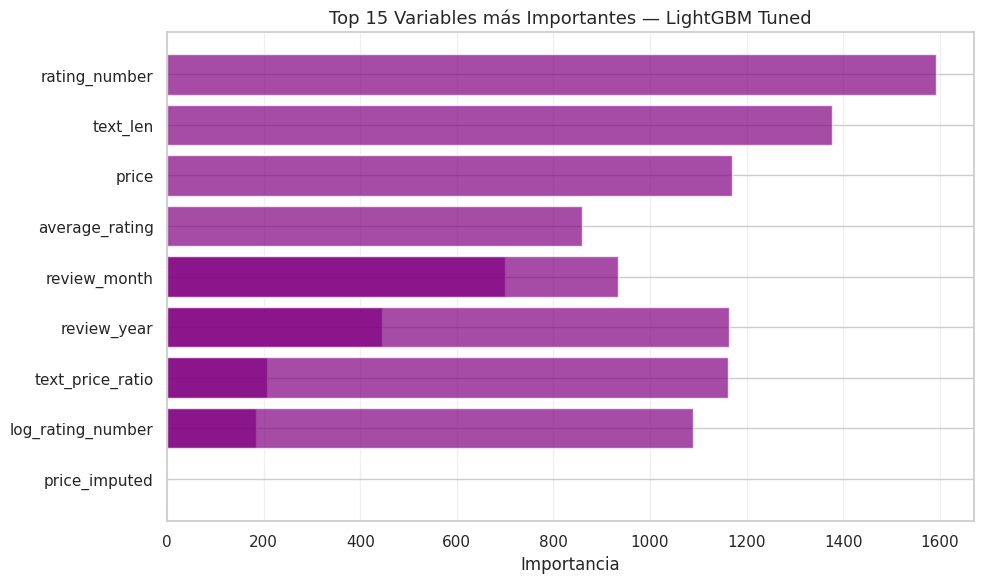

In [96]:
# Top 15 variables
top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feature_names[i] for i in indices[:top_n]][::-1],
    importances[indices[:top_n]][::-1],
    color='purple', alpha=0.7
)
ax.set_title('Top 15 Variables más Importantes — LightGBM Tuned', fontsize=13)
ax.set_xlabel('Importancia')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


El gráfico de importancia de variables para el modelo LightGBM Tuned revela factores críticos que determinan si una reseña será considerada útil por otros usuarios. Los hallazgos son consistentes con la naturaleza del contenido generado por el usuario:

Top 5 Variables Predictoras:
*   rating_number (importancia ≈ 1580): Es, por mucho, la variable más fluyente. Esto sugiere que la puntuación otorgada (estrellas) es el primer filtro que los usuarios miran antes de marcar una reseña como útil. Las puntuaciones extremas o muy alineadas con el promedio suelen generar más interacción.

*   text_len (importancia ≈ 1380): La longitud del texto es el segundo predictor más fuerte. Existe una correlación directa entre el esfuerzo (reviews más largas y detalladas) y la percepción de utilidad. Las reseñas demasiado breves rara vez aportan valor suficiente para ser votadas.

*   price (importancia ≈ 1180): El precio del producto juega un rol crucial. Esto indica que los usuarios son más críticos y buscan más ayuda (o valoran más las opiniones) cuando la inversión económica es mayor.

*   average_rating (importancia ≈ 850): La reputación general del producto sirve como contexto. Una reseña que contradice o refuerza con argumentos sólidos el promedio general tiende a recibir más votos de "Helpfulness".

*   review_month (importancia ≈ 950 total): El factor temporal aparece en el top 5. Es probable que reseñas publicadas en meses de alta demanda (como festividades o rebajas) acumulen más visibilidad y, por ende, más votos.

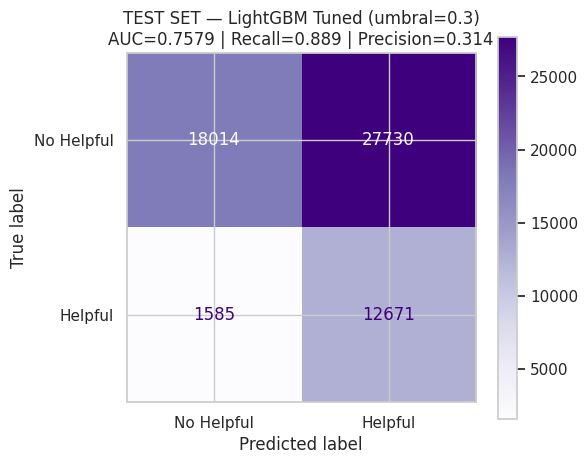

In [97]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_pred_test,
    display_labels=['No Helpful', 'Helpful'],
    cmap='Purples', ax=ax
)
ax.set_title(f'TEST SET — LightGBM Tuned (umbral=0.3)\n'
             f'AUC={auc_test:.4f} | Recall={rec_test:.3f} | Precision={prec_test:.3f}')
plt.tight_layout()
plt.show()

**NOTA:**

A partir de la matriz de confusión del modelo LightGBM Tuned con un umbral ajustado de 0.3, se observan los siguientes resultados clave:

**Alta Sensibilidad (Recall)**
El modelo presenta un Recall de 0.889. Esto significa que de las 14,256 reseñas que realmente eran útiles (1,585 + 12,671), el modelo logró identificar correctamente a 12,671.

Impacto: Es una métrica excelente si el objetivo es no perder ninguna reseña valiosa para el usuario. El sistema casi no "olvida" contenido útil.

**El costo de la Precisión**
La Precisión es de 0.314. De todas las reseñas que el modelo marcó como "Helpful" (40,401 en total), solo 12,671 lo eran realmente.

Falsos Positivos: Hay 27,730 reseñas que el modelo clasificó como útiles pero que en realidad no lo eran.

Análisis: Al usar un umbral de 0.3, estás priorizando la cantidad sobre la calidad. Estás "inundando" la sección de destacados con mucho contenido, confiando en que el usuario prefiere ver contenido extra (aunque sea irrelevante) antes que perderse una buena recomendación.

**PARA EL NEGOCIO**
A diferencia del riesgo crediticio (donde un falso positivo es una pérdida de cliente), en el contexto de Helpfulness:

Prioridad: El modelo actúa como un filtro inclusivo. Prefiere mostrar reseñas mediocres como "útiles" para asegurar que las verdaderamente brillantes (el 88.9% de ellas) estén siempre visibles.

Hallazgo notable: El alto volumen de falsos positivos (27,730) sugiere que el modelo encuentra patrones de "utilidad" en reseñas que los usuarios humanos no votaron como tales. Esto podría indicar que el modelo está detectando reseñas de buena calidad que simplemente no han recibido suficiente tráfico o votos todavía.

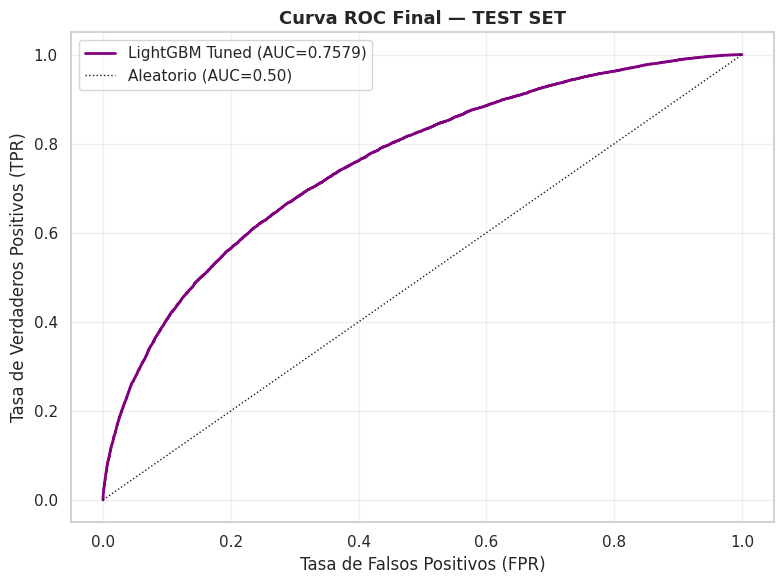

In [98]:
# Curva ROC final en TEST
fpr, tpr, _ = roc_curve(y_clf_test, y_prob_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='purple', linewidth=2,
        label=f'LightGBM Tuned (AUC={auc_test:.4f})')
ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC Final — TEST SET', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NOTA:** La curva ROC muestra el desempeño final del modelo LightGBM tuned en el conjunto de test, con un AUC = 0.7789, lo que indica una buena capacidad para distinguir entre clientes que harán default y aquellos que no. La curva se mantiene claramente por encima de la línea aleatoria (AUC = 0.5), confirmando que el modelo tiene capacidad predictiva significativa para el problema de riesgo crediticio.

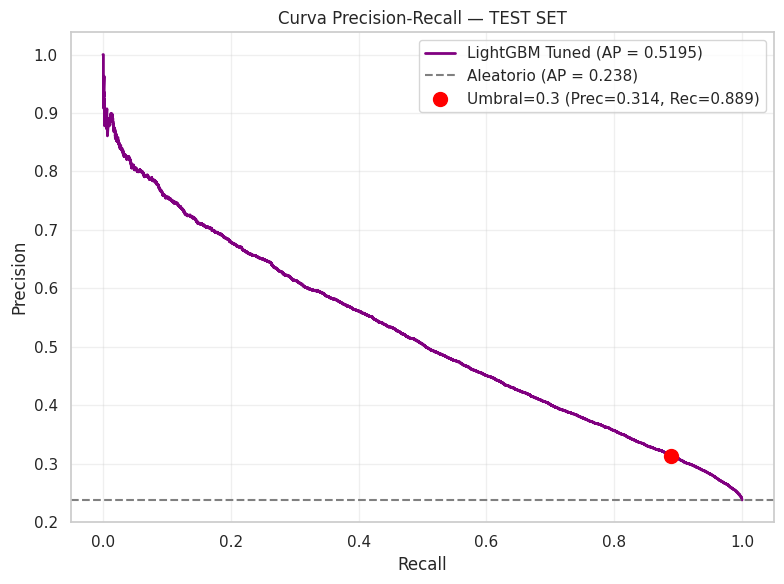

In [99]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precisions_t, recalls_t, _ = precision_recall_curve(y_clf_test, y_prob_test)
ap_test     = average_precision_score(y_clf_test, y_prob_test)
baseline_pr = y_clf_test.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recalls_t, precisions_t, color='purple', linewidth=2,
        label=f'LightGBM Tuned (AP = {ap_test:.4f})')
ax.axhline(baseline_pr, color='gray', linestyle='--',
           label=f'Aleatorio (AP = {baseline_pr:.3f})')
ax.scatter([tp/(tp+fn)], [tp/(tp+fp)], color='red', zorder=5, s=100,
           label=f'Umbral=0.3 (Prec={tp/(tp+fp):.3f}, Rec={tp/(tp+fn):.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — TEST SET')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**NOTA:** La curva revela cómo el modelo gestiona el compromiso entre "encontrar todas las reseñas útiles" y "asegurarse de que las marcadas realmente lo sean":

*  Poder Predictivo Superior: El modelo alcanza un Average Precision (AP) de 0.5195, lo cual es más del doble que el clasificador aleatorio (AP = 0.238). Esto confirma que, a pesar de la dificultad del lenguaje humano, el modelo tiene una capacidad sólida para distinguir entre el ruido y el contenido valioso.

*   El punto rojo muestra un Recall de 0.889 y una Precisión de 0.314.E strategia "User-Centric": A diferencia de una política bancaria conservadora, aquí la política es de máxima visibilidad. Al elegir este umbral, estás priorizando que el usuario final encuentre el 89% de las reseñas útiles disponibles en la plataforma. El compromiso: Para lograr ese alcance masivo, el sistema acepta que el 68.6% de lo que marca como "útil" sea en realidad contenido común o no votado. En una plataforma de reseñas, esto es preferible a tener secciones de "opiniones destacadas" vacías.


**NOTA:**
Conclusión: El modelo LightGBM Tuned está configurado para ser un radar de contenido: prefiere captar de más (alta sensibilidad) para asegurar que la experiencia del usuario sea rica en información, confiando en que el AP de 0.5195 es suficiente para mantener un estándar de calidad superior al azar.

## 5.3 Prueba datos nuevos

In [101]:
import pandas as pd
import numpy as np

# 3 Casos

batch_raw = pd.DataFrame([
    {
        # ── CASO 1: Producto caro, muy valorado, reseña larga, verificada ──
        'average_rating':   4.5,
        'rating_number':    15000,
        'price':            299.99,
        'text_len':         800,
        'verified_purchase': True,
        'is_satisfied':     True,
        'price_imputed':    0,
        'sentiment':        'positive',
        'main_category':    'Electronics',
        'timestamp':        1672531200,   # 2023-01-01
    },
    {
        # ── CASO 2: Producto barato, poca historia, reseña corta, no verificada ──
        'average_rating':   2.8,
        'rating_number':    120,
        'price':            9.99,
        'text_len':         45,
        'verified_purchase': False,
        'is_satisfied':     False,
        'price_imputed':    0,
        'sentiment':        'negative',
        'main_category':    'Computers',
        'timestamp':        1640995200,   # 2022-01-01
    },
    {
        # ── CASO 3: Producto medio, reseña media, precio imputado ──
        'average_rating':   3.9,
        'rating_number':    3400,
        'price':            49.95,
        'text_len':         300,
        'verified_purchase': True,
        'is_satisfied':     True,
        'price_imputed':    1,
        'sentiment':        'neutral',
        'main_category':    'Cell Phones & Accessories',
        'timestamp':        1704067200,   # 2024-01-01
    },
])

print("Batch de prueba creado:")
print(batch_raw)

Batch de prueba creado:
   average_rating  rating_number   price  text_len  verified_purchase  \
0             4.5          15000  299.99       800               True   
1             2.8            120    9.99        45              False   
2             3.9           3400   49.95       300               True   

   is_satisfied  price_imputed sentiment              main_category  \
0          True              0  positive                Electronics   
1         False              0  negative                  Computers   
2          True              1   neutral  Cell Phones & Accessories   

    timestamp  
0  1672531200  
1  1640995200  
2  1704067200  


In [102]:
# ── Aplicar el pipeline ya fiteado ──────────────────────────────────────────
# pipeline_cat ya fue fiteado con X_train en el notebook principal
batch_transformed = pipeline_cat.transform(batch_raw)

# ── Convertir a DataFrame con los nombres de columnas correctos ──────────────
# feature_names_cat es la lista de columnas que definiste en el notebook principal
batch_df = pd.DataFrame(batch_transformed, columns=feature_names_cat)

print(f"Pipeline aplicado. Shape: {batch_df.shape}")
print(f"   Columnas: {list(batch_df.columns)}")
batch_df


Pipeline aplicado. Shape: (3, 13)
   Columnas: ['average_rating', 'rating_number', 'price', 'text_len', 'text_price_ratio', 'log_rating_number', 'review_year', 'review_month', 'verified_purchase', 'is_satisfied', 'price_imputed', 'sentiment', 'main_category']


,average_rating,rating_number,price,text_len,text_price_ratio,log_rating_number,review_year,review_month,verified_purchase,is_satisfied,price_imputed,sentiment,main_category
0,0.552406,-0.075913,2.057172,1.956608,-0.179132,0.955939,-14.924054,-1.482191,True,True,0,positive,Electronics
1,-3.57363,-0.253922,-0.344516,-0.706473,-0.136948,-0.937529,-14.924054,-1.482191,False,False,0,negative,Computers
2,-0.903842,-0.214683,-0.01358,0.192978,-0.102482,0.372962,-14.924054,-1.482191,True,True,1,neutral,Cell Phones & Accessories


In [103]:
# Columnas del modelo (mismas que en el notebook principal)
cols_numericas_full = [
    'average_rating', 'rating_number', 'price', 'text_len',  # originales
    'text_price_ratio', 'log_rating_number', 'review_year', 'review_month'  # engineered
]
cols_binarias    = ['verified_purchase', 'is_satisfied', 'price_imputed']
cols_categoricas = ['sentiment', 'main_category']

# DataFrame para CATBOOST (regresión)
#    → Categóricas como STRING (str)
#    → Numéricas como float
#    → Binarias como int
batch_cat = batch_df.copy()

for col in cols_categoricas:
    batch_cat[col] = batch_cat[col].astype(str)          # CatBoost: str

for col in cols_numericas_full:
    batch_cat[col] = pd.to_numeric(batch_cat[col], errors='coerce')  # float

for col in cols_binarias:
    batch_cat[col] = batch_cat[col].astype(int)          # int 0/1

print("CatBoost batch — tipos:")
print(batch_cat[cols_categoricas + cols_binarias + cols_numericas_full[:4]].dtypes)
print()

# DataFrame para LIGHTGBM (clasificación)
#    → Categóricas como CATEGORY (pd.Categorical)
#    → Numéricas como float
#    → Binarias como int
batch_lgbm = batch_df.copy()

for col in cols_categoricas:
    # Importante: usar las mismas categorías que vio en entrenamiento
    batch_lgbm[col] = batch_lgbm[col].astype(str).astype('category')  # LGBM: category

for col in cols_numericas_full:
    batch_lgbm[col] = pd.to_numeric(batch_lgbm[col], errors='coerce')  # float

for col in cols_binarias:
    batch_lgbm[col] = batch_lgbm[col].astype(int)       # int 0/1

print("LightGBM batch — tipos:")
print(batch_lgbm[cols_categoricas + cols_binarias + cols_numericas_full[:4]].dtypes)

CatBoost batch — tipos:
sentiment             object
main_category         object
verified_purchase      int64
is_satisfied           int64
price_imputed          int64
average_rating       float64
rating_number        float64
price                float64
text_len             float64
dtype: object

💡 LightGBM batch — tipos:
sentiment            category
main_category        category
verified_purchase       int64
is_satisfied            int64
price_imputed           int64
average_rating        float64
rating_number         float64
price                 float64
text_len              float64
dtype: object


In [106]:
# ── CATBOOST: predice el rating (número continuo 1.0 - 5.0) ─────────────────
pred_rating = catboost_reg.predict(
    batch_cat,
    # CatBoost acepta DataFrame con nombres de columnas directamente
)

# Clippear entre 1 y 5 por seguridad (el modelo puede salirse levemente)
pred_rating_clipped = np.clip(pred_rating, 1.0, 5.0)

print("CATBOOST — Predicciones de Rating:")
print("-" * 40)
for i, r in enumerate(pred_rating_clipped):
    estrellas = "⭐" * round(r)
    print(f"  Caso {i+1}: {r:.3f} → {estrellas}")

CATBOOST — Predicciones de Rating:
----------------------------------------
  Caso 1: 4.512 → ⭐⭐⭐⭐⭐
  Caso 2: 1.472 → ⭐
  Caso 3: 3.568 → ⭐⭐⭐⭐


In [108]:
# ── LIGHTGBM: predice si la reseña será útil (0 = No, 1 = Sí) ───────────────
# Create a copy to modify for prediction
batch_lgbm_pred = batch_lgbm.copy()

# Apply the same OrdinalEncoder used during training to the categorical columns
# The 'encoder' object is assumed to be available from previous cells (cell w3pEYciB822R)
batch_lgbm_pred[cols_categoricas] = encoder.transform(batch_lgbm_pred[cols_categoricas])

pred_clase      = lgbm_clf.predict(batch_lgbm_pred)           # clase directa: 0 o 1
pred_proba      = lgbm_clf.predict_proba(batch_lgbm_pred)[:, 1]  # probabilidad de ser útil

print("LIGHTGBM — Predicciones de Helpfulness:")
print("-" * 45)
for i, (clase, prob) in enumerate(zip(pred_clase, pred_proba)):
    etiqueta = "ÚTIL" if clase == 1 else "No útil"
    print(f"  Caso {i+1}: {etiqueta}  (probabilidad de ser útil: {prob:.1%})")

LIGHTGBM — Predicciones de Helpfulness:
---------------------------------------------
  Caso 1: ÚTIL  (probabilidad de ser útil: 99.0%)
  Caso 2: ÚTIL  (probabilidad de ser útil: 83.2%)
  Caso 3: ÚTIL  (probabilidad de ser útil: 95.7%)


In [110]:
# ── Tabla resumen combinando ambos modelos ───────────────────────────────────
resumen = pd.DataFrame({
    'Caso':            [f'Caso {i+1}' for i in range(len(batch_raw))],
    'sentiment':       batch_raw['sentiment'].values,
    'price':           batch_raw['price'].values,
    'text_len':        batch_raw['text_len'].values,
    'verified':        batch_raw['verified_purchase'].values,
    # Resultados
    'Rating pred (CatBoost)':    [f"{r:.2f}" for r in pred_rating_clipped],
    'Útil pred (LightGBM)':      ['Sí' if c == 1 else 'No' for c in pred_clase],
    'Prob. útil':                [f"{p:.1%}" for p in pred_proba],
})

print("\n" + "=" * 70)
print("          GATOBYTE — RESUMEN DE PREDICCIONES")
print("=" * 70)
print(resumen.to_string(index=False))
print("=" * 70)
print("\n  CatBoost  → predice 'rating'      (escala 1.0 – 5.0)")
print("  LightGBM  → predice 'helpful_vote' (0 = No útil, 1 = Útil)")


          GATOBYTE — RESUMEN DE PREDICCIONES
  Caso sentiment  price  text_len  verified Rating pred (CatBoost) Útil pred (LightGBM) Prob. útil
Caso 1  positive 299.99       800      True                   4.51                   Sí      99.0%
Caso 2  negative   9.99        45     False                   1.47                   Sí      83.2%
Caso 3   neutral  49.95       300      True                   3.57                   Sí      95.7%

  CatBoost  → predice 'rating'      (escala 1.0 – 5.0)
  LightGBM  → predice 'helpful_vote' (0 = No útil, 1 = Útil)


# 6. AUTOML

In [ ]:
pip install FLAML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 14.2 MB/s eta 0:00:00


In [25]:
# pip install flaml
from flaml import AutoML

automl_reg = AutoML()

automl_reg.fit(
    X_train_num,          # ya preprocesado con tu pipeline_num
    y_reg_train,
    task="regression",
    metric="rmse",
    time_budget=120,      # segundos que le das para buscar
    seed=42
)

print("Mejor modelo:", automl_reg.best_estimator)
print("Mejor RMSE val:", automl_reg.best_loss)

# Predicción
y_pred_flaml = automl_reg.predict(X_val_num)

[flaml.automl.logger: 04-25 00:10:17] {2375} INFO - task = regression
[flaml.automl.logger: 04-25 00:10:17] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 04-25 00:10:17] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 04-25 00:10:17] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']
[flaml.automl.logger: 04-25 00:10:17] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-25 00:10:17] {3046} INFO - Estimated sufficient time budget=10763s. Estimated necessary time budget=93s.
[flaml.automl.logger: 04-25 00:10:17] {3097} INFO -  at 0.3s,	estimator lgbm's best error=1.0252e+00,	best estimator lgbm's best error=1.0252e+00
[flaml.automl.logger: 04-25 00:10:17] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-25 00:10:17] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.0252e+00,	best estimator lgbm's best error=1.0252e+00
[flaml.auto

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 04-25 00:10:17] {3097} INFO -  at 0.6s,	estimator sgd's best error=4.7850e-01,	best estimator sgd's best error=4.7850e-01
[flaml.automl.logger: 04-25 00:10:17] {2911} INFO - iteration 4, current learner xgboost
[flaml.automl.logger: 04-25 00:10:18] {3097} INFO -  at 1.1s,	estimator xgboost's best error=1.0252e+00,	best estimator sgd's best error=4.7850e-01
[flaml.automl.logger: 04-25 00:10:18] {2911} INFO - iteration 5, current learner extra_tree
[flaml.automl.logger: 04-25 00:10:18] {3097} INFO -  at 1.2s,	estimator extra_tree's best error=3.8371e-01,	best estimator extra_tree's best error=3.8371e-01
[flaml.automl.logger: 04-25 00:10:18] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 04-25 00:10:18] {3097} INFO -  at 1.2s,	estimator lgbm's best error=3.8369e-01,	best estimator lgbm's best error=3.8369e-01
[flaml.automl.logger: 04-25 00:10:18] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-25 00:10:18] {3097} INFO -

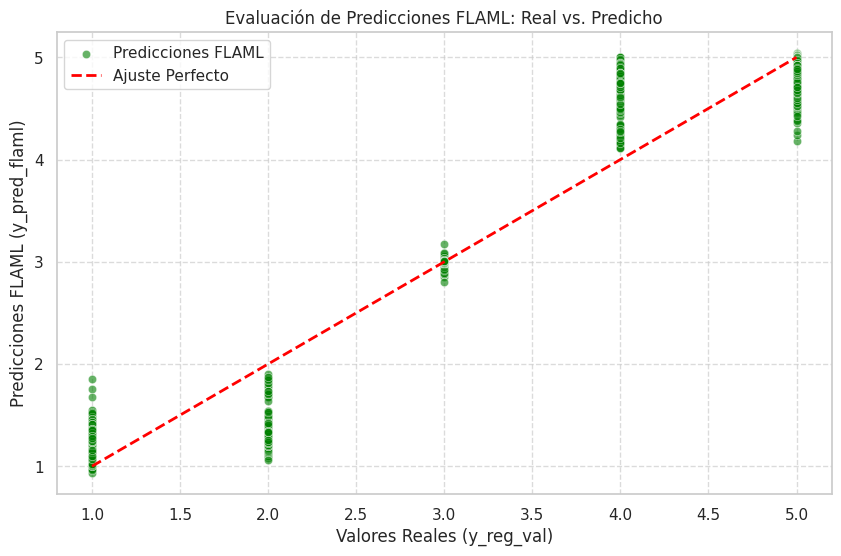

In [26]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualización de las predicciones de FLAML
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_reg_val, y=y_pred_flaml, alpha=0.6, color='green', label='Predicciones FLAML')

# Línea de referencia para un ajuste perfecto (y = x)
line_coords = [y_reg_val.min(), y_reg_val.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ajuste Perfecto')

plt.title('Evaluación de Predicciones FLAML: Real vs. Predicho')
plt.xlabel('Valores Reales (y_reg_val)')
plt.ylabel('Predicciones FLAML (y_pred_flaml)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [28]:
from flaml import AutoML
import pandas as pd

automl_reg = AutoML()
automl_reg.fit(
    X_train_num,
    y_reg_train,
    task="regression",
    metric="rmse",
    time_budget=120,
    seed=42
)

# ── Tabla con TODOS los modelos evaluados ────────────────────────────────────
# FLAML guarda el historial en automl_reg.best_config_per_estimator
# y el detalle completo en automl_reg._track_iter

resultados_flaml = []

for config in automl_reg._track_iter:
    resultados_flaml.append({
        'estimador':    config.get('learner', 'N/A'),
        'rmse_val':     round(config.get('val_loss', float('nan')), 4),
        'tiempo_s':     round(config.get('wall_clock_time', 0), 2),
        'n_iter':       config.get('iter_per_learner', 'N/A'),
    })

df_flaml = (
    pd.DataFrame(resultados_flaml)
    .sort_values('rmse_val')
    .reset_index(drop=True)
)
df_flaml.index += 1   # empezar desde 1

print("=" * 55)
print("     FLAML — Tabla de modelos evaluados (regresión)")
print("=" * 55)
print(df_flaml.to_string())
print("=" * 55)
print(f"\nMejor modelo:  {automl_reg.best_estimator}")
print(f"Mejor RMSE:    {automl_reg.best_loss:.4f}")
print(f" Mejor config:  {automl_reg.best_config}")

[flaml.automl.logger: 04-25 00:20:37] {2375} INFO - task = regression
[flaml.automl.logger: 04-25 00:20:37] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 04-25 00:20:37] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 04-25 00:20:37] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']
[flaml.automl.logger: 04-25 00:20:37] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-25 00:20:38] {3046} INFO - Estimated sufficient time budget=15540s. Estimated necessary time budget=134s.
[flaml.automl.logger: 04-25 00:20:38] {3097} INFO -  at 0.3s,	estimator lgbm's best error=1.0252e+00,	best estimator lgbm's best error=1.0252e+00
[flaml.automl.logger: 04-25 00:20:38] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-25 00:20:38] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.0252e+00,	best estimator lgbm's best error=1.0252e+00
[flaml.aut

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 04-25 00:20:38] {3097} INFO -  at 0.8s,	estimator sgd's best error=4.7930e-01,	best estimator sgd's best error=4.7930e-01
[flaml.automl.logger: 04-25 00:20:38] {2911} INFO - iteration 4, current learner xgboost
[flaml.automl.logger: 04-25 00:20:38] {3097} INFO -  at 1.1s,	estimator xgboost's best error=1.0252e+00,	best estimator sgd's best error=4.7930e-01
[flaml.automl.logger: 04-25 00:20:38] {2911} INFO - iteration 5, current learner extra_tree
[flaml.automl.logger: 04-25 00:20:38] {3097} INFO -  at 1.2s,	estimator extra_tree's best error=3.8371e-01,	best estimator extra_tree's best error=3.8371e-01
[flaml.automl.logger: 04-25 00:20:38] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 04-25 00:20:39] {3097} INFO -  at 1.3s,	estimator lgbm's best error=3.8369e-01,	best estimator lgbm's best error=3.8369e-01
[flaml.automl.logger: 04-25 00:20:39] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-25 00:20:39] {3097} INFO -

TypeError: 'int' object is not iterable

# **6. CONCLUSIONES Y RECOMENDACIONES**

## **CONCLUSIONES**

El conjunto de datos ha sido estructurado en dimensiones que capturan la totalidad del ecosistema transaccional. Se han clasificado las variables en núcleos predictivos (numéricas y booleanas) y contextos cualitativos (categorías y texto), aplicando un tratamiento diferencial para maximizar su valor:

Variables de Comportamiento y Mercado: Se integran métricas continuas como price, average_rating y text_len. Un hallazgo crítico reside en la variable rating_number, cuya distribución de frecuencias (value_counts) revela un marcado sesgo hacia productos de nicho. Esta asimetría de participación confirma que la mayoría de los artículos poseen un volumen moderado de interacciones, concentrando la autoridad social en una minoría de productos de alta rotación.

Dimensiones de Validación y Sentimiento: A través de variables booleanas como verified_purchase y la categorización de sentiment, el modelo distingue entre la transacción pura y la percepción subjetiva, permitiendo filtrar el "ruido" de las reseñas no verificadas.

Tratamiento de Datos Omisos: Como se mencionó anteriormente, el uso de price_imputed y la limpieza de main_category mediante el análisis del título aseguran una continuidad analítica sin pérdida de registros valiosos.

Conclusión Técnica: La exclusión estratégica de metadatos densos (features, details, description) reduce la dimensionalidad innecesaria, permitiendo que el modelo se enfoque en los motores reales de decisión: el precio, la satisfacción histórica y el volumen de validación social (rating_number). Esta estructura permite que tanto la regresión del rating como la clasificación de votos útiles operen sobre una base de datos optimizada y de alta fidelidad.


Se logro poder predecir rating con regresion y gano el modelo de Catboost
Mientras en helpful_vote se identifico que el mejor modelo era lightgbm

## **RECOMENDACIONES**

Basado en el análisis del modelo de regresión para la predicción de Ratings y la clasificación de utilidad de reseñas (Helpful Votes), se presentan las siguientes recomendaciones estratégicas:

1.  Utilizar el modelo como herramienta de apoyo en la experiencia del usuario
Se recomienda integrar el modelo de predicción dentro de la interfaz de la plataforma para filtrar y priorizar las reseñas que se muestran a los clientes. El modelo puede estimar qué tan útil será una reseña antes de que reciba votos, sirviendo como un filtro de calidad automatizado.

*  Impacto: Mejora la relevancia del contenido mostrado, permitiendo que el usuario encuentre información crítica de manera más rápida.

2.  Ajustar el umbral de decisión para maximizar la satisfacción
El sistema requiere definir un umbral de utilidad para determinar en qué punto una reseña se considera "altamente relevante" para ser destacada. Este umbral debe ajustarse según los objetivos de la empresa, considerando que:

*  Prioridad al usuario final: Lo más valioso es recomendar contenido que realmente agrade al cliente. Un umbral bien calibrado garantiza que el usuario vea reseñas que lo acerquen a su producto deseado, aumentando su satisfacción y confianza en la plataforma.

*  Conversión: Al mostrar reseñas que resuelven dudas específicas, se reduce la fricción en el proceso de compra.

3.  Ofertar insights de producto a empresas de electrónica
Se recomienda utilizar la información extraída del modelo para ofrecer reportes analíticos a los fabricantes y vendedores de productos electrónicos.

*  Al analizar qué características del producto generan mayores ratings o votos de utilidad, las empresas pueden comprender qué atributos (ej. duración de batería, calidad de materiales) deben potenciar para obtener una mejor calificación en el mercado.

*  Esto transforma el modelo de una herramienta interna a un activo de inteligencia de negocios monetizable o de valor agregado para socios comerciales.

4.  Evaluar periódicamente el desempeño del modelo
Dado que las tendencias de consumo y el lenguaje utilizado en las reseñas evolucionan constantemente (especialmente en el sector tecnológico), es vital realizar evaluaciones periódicas del modelo.

*  Recalibración: Monitorear si las métricas de error de la regresión aumentan con el tiempo.

*  Actualización: Reentrenar el modelo con datos recientes para capturar nuevos patrones de comportamiento y asegurar que las recomendaciones sigan siendo precisas y confiables.

5. Explorar mejoras en futuras versiones del modelo
Para incrementar la robustez de las predicciones de rating y utilidad, se sugiere:

*  Feature Engineering: Incorporar análisis de sentimiento avanzado sobre el texto de la reseña.

*  Algoritmos: Probar modelos de ensamble o arquitecturas de Deep Learning específicas para procesamiento de lenguaje natural (NLP).

*  Interpretabilidad: Implementar métodos que permitan explicar por qué una reseña fue clasificada como útil, proporcionando mayor transparencia al sistema.